In [43]:
import pandas as pd
import plotly.graph_objects as go
import glob
import numpy as np
from pathlib import Path
from pandas.tseries.offsets import BDay

def main():
    # 1. Find the latest predictions CSV
    results_dir = Path("./results")
    csv_files = sorted(glob.glob(str(results_dir / "model_predictions_*.csv")))
    
    if not csv_files:
        print("No prediction CSV files found in ./results/")
        return
        
    latest_csv = csv_files[-1]
    print(f"Loading data from: {Path(latest_csv).name}")
    
    df = pd.read_csv(latest_csv)
    df['Prediction_Date'] = pd.to_datetime(df['Prediction_Date'])
    
    # 2. Map the "Target Date" and the "Actual Outcome"
    # Target Date is the literal NEXT trading day.
    df['Target_Date'] = df['Prediction_Date'].shift(-1)
    
    # For the final row (today's live prediction for tomorrow), we extrapolate the next business day
    df.loc[df.index[-1], 'Target_Date'] = df.loc[df.index[-1], 'Prediction_Date'] + BDay(1)
    
    # The actual outcome for a prediction is where the market closed on the Target Date 
    # (which is the Base_Price of the next row)
    df['Actual_Outcome'] = df['Base_Price'].shift(-1)
    
    # 3. Dynamic column detection (Extracts config bounds automatically)
    cols = df.columns.tolist()
    upper_cols = [c for c in cols if c.startswith("Upper_") and c.endswith("_CI_Price")]
    lower_cols = [c for c in cols if c.startswith("Lower_") and c.endswith("_CI_Price")]
    
    def extract_ci(col_name): return int(col_name.split('_')[1])
    upper_cols.sort(key=extract_ci, reverse=True)
    lower_cols.sort(key=extract_ci, reverse=True)
    
    outer_upper, inner_upper = upper_cols[0], upper_cols[1]
    outer_lower, inner_lower = lower_cols[0], lower_cols[1]
    
    outer_ci_val = outer_upper.split('_')[1]
    inner_ci_val = inner_upper.split('_')[1]

    # 4. Calculate Hit Rates & Directional Accuracy (Only on resolved days)
    valid_df = df.dropna(subset=['Actual_Outcome'])
    
    outer_hits = ((valid_df['Actual_Outcome'] >= valid_df[outer_lower]) & 
                  (valid_df['Actual_Outcome'] <= valid_df[outer_upper])).mean() * 100
                  
    inner_hits = ((valid_df['Actual_Outcome'] >= valid_df[inner_lower]) & 
                  (valid_df['Actual_Outcome'] <= valid_df[inner_upper])).mean() * 100

    # Directional Accuracy Calculation
    pred_dir = np.sign(valid_df['Mean_Predicted_Price'] - valid_df['Base_Price'])
    actual_dir = np.sign(valid_df['Actual_Outcome'] - valid_df['Base_Price'])
    dir_accuracy = (pred_dir == actual_dir).mean() * 100

    print(f"--- HIT RATE CALIBRATION ---")
    print(f"{outer_ci_val}% Band Hit Rate : {outer_hits:.2f}%")
    print(f"{inner_ci_val}% Band Hit Rate  : {inner_hits:.2f}%")
    print(f"Directional Accuracy : {dir_accuracy:.2f}%")

    # 5. Calculate Range for Annotations 
    df['Outer_Range'] = df[outer_upper] - df[outer_lower]
    
    idx_max_range = df['Outer_Range'].idxmax()
    idx_min_range = df['Outer_Range'].idxmin()

    # 6. Create the Plotly Figure
    fig = go.Figure()

    # --- OUTER CI BAND ---
    fig.add_trace(go.Scatter(
        x=df['Target_Date'], y=df[outer_lower],
        line=dict(color='rgba(70, 130, 180, 0.8)', width=1.5), 
        name=f"Lower {outer_ci_val}% CI"
    ))
    fig.add_trace(go.Scatter(
        x=df['Target_Date'], y=df[outer_upper],
        fill='tonexty', 
        fillcolor='rgba(173, 216, 230, 0.3)', 
        line=dict(color='rgba(70, 130, 180, 0.8)', width=1.5), 
        name=f"Upper {outer_ci_val}% CI"
    ))

    # --- INNER CI BAND ---
    fig.add_trace(go.Scatter(
        x=df['Target_Date'], y=df[inner_lower],
        line=dict(color='rgba(46, 139, 87, 0.8)', width=1.5), 
        name=f"Lower {inner_ci_val}% CI"
    ))
    fig.add_trace(go.Scatter(
        x=df['Target_Date'], y=df[inner_upper],
        fill='tonexty', 
        fillcolor='rgba(144, 238, 144, 0.4)', 
        line=dict(color='rgba(46, 139, 87, 0.8)', width=1.5),
        name=f"Upper {inner_ci_val}% CI"
    ))

    # --- MEAN PREDICTED PRICE ---
    fig.add_trace(go.Scatter(
        x=df['Target_Date'], y=df['Mean_Predicted_Price'],
        mode='lines',
        line=dict(color='blue', width=2),
        name="Mean Predicted Close"
    ))

    # --- ACTUAL OUTCOME (The resolved close for the target date) ---
    fig.add_trace(go.Scatter(
        x=df['Target_Date'], y=df['Actual_Outcome'],
        mode='lines+markers',
        line=dict(color='black', width=2),
        marker=dict(size=4, color='black'),
        name="Actual Achieved Close"
    ))

    # 7. Add Annotations for Min/Max Volatility Ranges
    fig.add_annotation(
        x=df.loc[idx_max_range, 'Target_Date'], 
        y=df.loc[idx_max_range, outer_upper],
        text=f"Largest Range: {df.loc[idx_max_range, 'Outer_Range']:.1f} pts",
        showarrow=True, arrowhead=2, arrowsize=1, arrowwidth=2,
        ax=0, ay=-40, font=dict(color="red", size=12)
    )

    fig.add_annotation(
        x=df.loc[idx_min_range, 'Target_Date'], 
        y=df.loc[idx_min_range, outer_upper],
        text=f"Smallest Range: {df.loc[idx_min_range, 'Outer_Range']:.1f} pts",
        showarrow=True, arrowhead=2, arrowsize=1, arrowwidth=2,
        ax=0, ay=-40, font=dict(color="green", size=12)
    )

    # 8. Formatting & Layout
    fig.update_layout(
        title=f"NIFTY Target Date Projections | {outer_ci_val}% Band: {outer_hits:.1f}% | {inner_ci_val}% Band: {inner_hits:.1f}% | Dir Acc: {dir_accuracy:.1f}%",
        xaxis_title="Target Date (Realization Day)",
        yaxis_title="Index Price",
        template="plotly_white",
        hovermode="x unified", 
        legend=dict(
            orientation="h",
            yanchor="bottom", y=1.02,
            xanchor="right", x=1
        )
    )

    # Clean the X-axis mapping to disable sub-daily timestamps
    fig.update_xaxes(
        tickformat="%Y-%m-%d",
        hoverformat="%Y-%m-%d",
        type="date"
    )

    fig.show()

if __name__ == "__main__":
    main()

Loading data from: model_predictions_20260310_to_20260723.csv
--- HIT RATE CALIBRATION ---
85% Band Hit Rate : 86.67%
20% Band Hit Rate  : 15.56%
Directional Accuracy : 80.00%


In [44]:
import pandas as pd
import polars as pl
import glob
import numpy as np
from pathlib import Path
import re

# ==========================================
# CONFIGURATION
# ==========================================
STRIKE_GAP    = 50
LOT_SIZE      = 65
ASYMM_SL_MULT = 1.5   # SL for uncapped short strangles

PREDICTIONS_DIR = Path("./results")
SPREADS_DIR     = Path("./data/NIFTY_spreads")

# ──────────────────────────────────────────────────────────────────────────────
# STRATEGIES REMOVED AND WHY
# ──────────────────────────────────────────────────────────────────────────────
#
# SHORT_STRANGLE  (-₹26,523)  — "picking up pennies in front of a steamroller"
#   65% win rate is meaningless when distribution is severely left-skewed:
#     7 SL hits  × avg loss  ~84pts = -588pts gross loss
#    17 wins     × avg gain  ~14pts = +238pts gross gain
#   The 1.5× SL doesn't protect you — it just defines where the steamroller
#   hits. Fat tails always win. Fix: defined-risk structures only.
#
# ATM_SHORT_STRADDLE  (-₹36,683)  — highest avg spread (0.82 vs ~0.25 elsewhere)
#   ATM bid-ask width immediately eats the credit before any market move.
#   No defined risk compounds the problem.
#
# ZONE_BREAKOUT_SPREAD  (-₹33,134)  — unfavorable premium-to-probability ratio
#   Inner 20% CI is ~100pts wide. Buying two debit spreads anchored at these
#   very tight levels costs a lot relative to the narrow profit corridor.
#
# IRON_CONDOR / WIDE_IRON_CONDOR  (-₹1,521 / -₹2,610)  — wastes directional edge
#   Model has ~80% directional accuracy. A symmetric neutral structure throws
#   this edge away. Replaced by skewed/asymmetric condors that exploit it.
#
# LONG_STRANGLE_INNER_CI  (-₹18,024)  — too expensive relative to payoff
#   34.6% win rate. Inner CI options carry high IV premium; the strangle
#   rarely pays enough on winning days to offset the decay on losing days.
#   Outer CI (DOUBLE_DEBIT_STRANGLE) is cheaper and performed better.
#
# DIRECTIONAL_CREDIT_SPREAD  — BUG: identical to DIRECTIONAL_RATIO
#   Both strategies resolved to the same leg strikes (sp_outer/lp_outer)
#   just in different list order → identical PnL. Replaced by
#   INNER_CI_CREDIT_SPREAD which uses genuinely different strikes.
# ──────────────────────────────────────────────────────────────────────────────


# ==========================================
# HELPERS
# ==========================================

def round_to_nearest_strike(price, base=50):
    return base * round(price / base)


def detect_ci_columns(df):
    """Auto-detect outer (larger %) and inner (smaller %) CI price columns."""
    pattern = re.compile(r'^(Lower|Upper)_(\d+)_CI_Price$')
    found = {}
    for col in df.columns:
        m = pattern.match(col)
        if m:
            side, pct = m.group(1), int(m.group(2))
            found.setdefault(pct, {})[side] = col

    complete = {pct: d for pct, d in found.items() if "Lower" in d and "Upper" in d}
    if len(complete) < 2:
        raise ValueError(
            f"Expected ≥2 complete CI levels. "
            f"Found: {list(complete.keys())} — columns: {list(df.columns)}"
        )

    sorted_pcts = sorted(complete.keys())
    inner_pct   = sorted_pcts[0]
    outer_pct   = sorted_pcts[-1]
    col_map = {
        "lower_outer": complete[outer_pct]["Lower"],
        "upper_outer": complete[outer_pct]["Upper"],
        "lower_inner": complete[inner_pct]["Lower"],
        "upper_inner": complete[inner_pct]["Upper"],
    }
    print(f"[CI] Outer {outer_pct}% → {col_map['lower_outer']} / {col_map['upper_outer']}")
    print(f"[CI] Inner {inner_pct}% → {col_map['lower_inner']} / {col_map['upper_inner']}")
    return outer_pct, inner_pct, col_map


def extract_leg_data(df_day, target_date_str, option_type, strike):
    """
    Return entry (09:15), exit (15:30 or last bar), volume check (09:20),
    and post-entry SL scan bars for one leg. Returns None on any miss.
    """
    leg_df = df_day.filter(
        (pl.col("type").is_in([option_type, option_type[0]])) &
        (pl.col("strike") == strike)
    )
    if leg_df.height == 0:
        return None

    e_row = leg_df.filter(pl.col("datetime") == f"{target_date_str} 09:15:00")
    v_row = leg_df.filter(pl.col("datetime") == f"{target_date_str} 09:20:00")
    if e_row.height == 0 or v_row.height == 0:
        return None

    # Volume gate — require actual trading at open
    if v_row.select("cumulative_volume").item() <= e_row.select("cumulative_volume").item():
        return None

    all_day = leg_df.sort("datetime")
    x_row   = leg_df.filter(pl.col("datetime") == f"{target_date_str} 15:30:00")
    if x_row.height == 0:
        x_row = all_day.tail(1)

    # SL scan starts at 09:20 — avoids the entry bar's own spread triggering SL
    sl_day = leg_df.filter(
        pl.col("datetime") >= f"{target_date_str} 09:20:00"
    ).sort("datetime")

    return {
        "entry_bid":    e_row.select("bid").item(),
        "entry_ask":    e_row.select("ask").item(),
        "exit_bid":     x_row.select("bid").item(),
        "exit_ask":     x_row.select("ask").item(),
        "all_day_asks": all_day.select("ask").to_series().to_list(),
        "all_day_bids": all_day.select("bid").to_series().to_list(),
        "sl_day_asks":  sl_day.select("ask").to_series().to_list(),
        "sl_day_bids":  sl_day.select("bid").to_series().to_list(),
        "strike":       strike,
    }


def apply_sl_check(day_legs, sell_indices, sl_mult):
    """
    Intraday stop-loss scan for short legs (post-entry bars only).
    Stops when combined buyback cost exceeds entry_credit × sl_mult.

    Returns (True, stop_pnl) if triggered, else (False, None).
    """
    entry_credit = sum(day_legs[i]["entry_bid"] for i in sell_indices)
    if entry_credit <= 0:
        return False, None

    min_len = min(len(day_legs[i]["sl_day_asks"]) for i in sell_indices)
    for t in range(min_len):
        buyback = sum(day_legs[i]["sl_day_asks"][t] for i in sell_indices)
        if buyback > entry_credit * sl_mult:
            return True, entry_credit - buyback

    return False, None


# ==========================================
# STRATEGY CATALOGUE
# ==========================================
#
# Strike hierarchy (guaranteed order):
#   sp_outer < sp_inner < atm / mean_atm < sc_inner < sc_outer
#
# All spreads that involve inner CI short strikes use a fixed STRIKE_GAP-wide
# wing so the max-loss per side is always capped at exactly STRIKE_GAP pts
# minus the credit received. This prevents the variable-width wing problem
# that made the old WIDE_IRON_CONDOR's risk profile inconsistent.
#
# Name                   | Type   | Dir | SL  | Description
# ──────────────────────────────────────────────────────────────────────────
# ASYMMETRIC_STRANGLE    | Credit | Yes | Yes | Best prev; tighten strike on confident side
# SKEWED_IRON_CONDOR     | Credit | Yes | No  | Defined-risk asymmetric; fixes SL fat-tail
# DIRECTIONAL_RATIO      | Credit | Yes | No  | Single credit spread at outer CI (OTM, safe)
# INNER_CI_CREDIT_SPREAD | Credit | Yes | No  | Credit spread with short at inner CI (more ₹)
# DIRECTIONAL_CI_SPREAD  | Debit  | Yes | No  | Buy inner→outer CI debit spread for breakout
# DIRECTIONAL_DEBIT_BASKET| Debit | Yes | No  | ATM call/put debit spread, 1 strike OTM
# DOUBLE_DEBIT_STRANGLE  | Debit  | No  | No  | Long vol; buy cheap outer CI strangle
# MEAN_ANCHORED_CONDOR   | Credit | Yes | No  | Condor centered at model's mean prediction
# ──────────────────────────────────────────────────────────────────────────


# ==========================================
# BACKTEST ENGINE
# ==========================================

def run_backtest(strategy_name, df_preds, lf_spreads, col_map, outer_pct, inner_pct):
    """Run one strategy end-to-end; return a summary metrics dict."""
    W = 105
    print(f"\n{'='*W}\n{f'🚀  STRATEGY: {strategy_name}':^{W}}\n{'='*W}")

    total_pnl    = 0.0
    total_spread = 0.0
    wins = losses = max_hits = sl_count = skipped = 0
    trade_pnls   = []

    COL_LO = col_map["lower_outer"]
    COL_HO = col_map["upper_outer"]
    COL_LI = col_map["lower_inner"]
    COL_HI = col_map["upper_inner"]

    for _, row in df_preds.iterrows():
        t_date_str   = str(row["Target_Date"].date())
        actual_close = row["Actual_Outcome"]
        predicted    = row["Mean_Predicted_Price"]
        base_price   = row["Base_Price"]

        # ── Strike levels ─────────────────────────────────────────────────────
        # Outer (wide) CI
        sp_outer = round_to_nearest_strike(row[COL_LO])
        sc_outer = round_to_nearest_strike(row[COL_HO])
        lp_outer = sp_outer - STRIKE_GAP          # OTM wing below outer put
        lc_outer = sc_outer + STRIKE_GAP          # OTM wing above outer call

        # Inner (tight) CI
        sp_inner = round_to_nearest_strike(row[COL_LI])
        sc_inner = round_to_nearest_strike(row[COL_HI])

        # ATM / mean prediction
        atm      = round_to_nearest_strike(base_price)
        mean_atm = round_to_nearest_strike(predicted)
        bullish  = predicted > base_price

        # ── Load day's option data ────────────────────────────────────────────
        df_day = lf_spreads.filter(
            pl.col("datetime").str.starts_with(t_date_str)
        ).collect()
        if df_day.height == 0:
            skipped += 1
            continue

        valid_exp = sorted([
            e for e in df_day.select("expiry").unique().to_series().to_list()
            if str(e)[:10] >= t_date_str
        ])
        if not valid_exp:
            skipped += 1
            continue
        df_day = df_day.filter(pl.col("expiry") == valid_exp[0])

        # ────────────────────────────────────────────────────────────────────
        # STRATEGY DEFINITIONS
        # ────────────────────────────────────────────────────────────────────
        legs_config = []
        sl_config   = None

        # ── 1. ASYMMETRIC_STRANGLE ────────────────────────────────────────────
        # Best prev performer (+₹22,496). Sell strangle but tighten the short
        # strike on the side the model is CONFIDENT won't be breached:
        #   Bullish → put side is "safe" → sell put at sp_inner (close to ATM,
        #             more premium); keep call at sc_outer (standard caution).
        #   Bearish → call side is "safe" → sell call at sc_inner; put at sp_outer.
        # Still uncapped — SL limits worst-case loss.
        if strategy_name == "ASYMMETRIC_STRANGLE":
            if bullish:
                legs_config = [
                    ("PE", sp_inner, "sell"),   # tightened — more premium
                    ("CE", sc_outer, "sell"),   # standard
                ]
            else:
                legs_config = [
                    ("PE", sp_outer, "sell"),   # standard
                    ("CE", sc_inner, "sell"),   # tightened — more premium
                ]
            sl_config = ("asymm", ASYMM_SL_MULT)

        # ── 2. SKEWED_IRON_CONDOR ─────────────────────────────────────────────
        # Defined-risk version of ASYMMETRIC_STRANGLE.
        # Adds a FIXED STRIKE_GAP-wide wing on each side so max loss per
        # spread is always exactly STRIKE_GAP - credit_received (no fat tails).
        # Tightened short strike matches ASYMMETRIC_STRANGLE's edge;
        # the wing caps the catastrophic losses that the SL couldn't.
        #
        #  Bullish: buy PE@(sp_inner-gap), sell PE@sp_inner,
        #           sell CE@sc_outer,       buy CE@(sc_outer+gap)
        #  Bearish: buy PE@(sp_outer-gap), sell PE@sp_outer,
        #           sell CE@sc_inner,       buy CE@(sc_inner+gap)
        elif strategy_name == "SKEWED_IRON_CONDOR":
            if bullish:
                legs_config = [
                    ("PE", sp_inner - STRIKE_GAP, "buy"),    # tight wing
                    ("PE", sp_inner,              "sell"),   # tight short put (inner CI)
                    ("CE", sc_outer,              "sell"),   # standard short call
                    ("CE", sc_outer + STRIKE_GAP, "buy"),   # standard wing
                ]
            else:
                legs_config = [
                    ("PE", sp_outer - STRIKE_GAP, "buy"),   # standard wing
                    ("PE", sp_outer,              "sell"),   # standard short put
                    ("CE", sc_inner,              "sell"),   # tight short call (inner CI)
                    ("CE", sc_inner + STRIKE_GAP, "buy"),   # tight wing
                ]

        # ── 3. DIRECTIONAL_RATIO ──────────────────────────────────────────────
        # Single-sided credit spread at outer CI in predicted direction.
        # Bullish: bull put spread (sell put at sp_outer, buy wing at lp_outer).
        # Bearish: bear call spread (sell call at sc_outer, buy wing at lc_outer).
        # Very OTM → lower premium but high win rate; defined risk.
        elif strategy_name == "DIRECTIONAL_RATIO":
            if bullish:
                legs_config = [
                    ("PE", sp_outer, "sell"),
                    ("PE", lp_outer, "buy"),
                ]
            else:
                legs_config = [
                    ("CE", sc_outer, "sell"),
                    ("CE", lc_outer, "buy"),
                ]

        # ── 4. INNER_CI_CREDIT_SPREAD ─────────────────────────────────────────
        # Like DIRECTIONAL_RATIO but the short strike is at the inner CI boundary
        # (closer to ATM) — collects materially more premium at the cost of a
        # higher probability of assignment. Wing stays at outer CI for protection.
        # Fixed STRIKE_GAP-wide wing; max loss = STRIKE_GAP - credit_received.
        #
        #  Bullish: sell PE@sp_inner, buy PE@(sp_inner - STRIKE_GAP)
        #  Bearish: sell CE@sc_inner, buy CE@(sc_inner + STRIKE_GAP)
        #
        # NOTE — this is NOT the same as DIRECTIONAL_RATIO:
        #   DIRECTIONAL_RATIO short = sp_outer (outer CI, far OTM, small premium)
        #   INNER_CI_CREDIT_SPREAD short = sp_inner (inner CI, close to ATM, big premium)
        elif strategy_name == "INNER_CI_CREDIT_SPREAD":
            if bullish:
                legs_config = [
                    ("PE", sp_inner,              "sell"),
                    ("PE", sp_inner - STRIKE_GAP, "buy"),
                ]
            else:
                legs_config = [
                    ("CE", sc_inner,              "sell"),
                    ("CE", sc_inner + STRIKE_GAP, "buy"),
                ]

        # ── 5. DIRECTIONAL_CI_SPREAD ──────────────────────────────────────────
        # Debit spread that explicitly bets the inner CI will be BROKEN in the
        # predicted direction. Since ~85% of closes break the inner CI,
        # and the model has ~80% directional accuracy, these should frequently
        # coincide when buying the right side.
        #
        #  Bullish: buy CE@sc_inner (profitable when close > sc_inner),
        #           sell CE@sc_outer (caps max gain at sc_outer)
        #  Bearish: buy PE@sp_inner (profitable when close < sp_inner),
        #           sell PE@sp_outer (caps max gain at sp_outer)
        elif strategy_name == "DIRECTIONAL_CI_SPREAD":
            if bullish:
                legs_config = [
                    ("CE", sc_inner, "buy"),
                    ("CE", sc_outer, "sell"),
                ]
            else:
                legs_config = [
                    ("PE", sp_inner, "buy"),
                    ("PE", sp_outer, "sell"),
                ]

        # ── 6. DIRECTIONAL_DEBIT_BASKET ──────────────────────────────────────
        # ATM-anchored debit spread 1 strike OTM in predicted direction.
        # Pure directional play with tight defined risk.
        elif strategy_name == "DIRECTIONAL_DEBIT_BASKET":
            if bullish:
                legs_config = [
                    ("CE", atm,              "buy"),
                    ("CE", atm + STRIKE_GAP, "sell"),
                ]
            else:
                legs_config = [
                    ("PE", atm,              "buy"),
                    ("PE", atm - STRIKE_GAP, "sell"),
                ]

        # ── 7. DOUBLE_DEBIT_STRANGLE ──────────────────────────────────────────
        # Buy OTM strangle at outer CI strikes — the cheapest available options.
        # Profits only when close moves BEYOND sp_outer or sc_outer (outer CI break).
        # Long-vol lottery ticket; benefits from fat-tail events.
        # Fixed range display uses actual option strikes (sp_outer / sc_outer).
        elif strategy_name == "DOUBLE_DEBIT_STRANGLE":
            legs_config = [
                ("PE", sp_outer, "buy"),
                ("CE", sc_outer, "buy"),
            ]

        # ── 8. MEAN_ANCHORED_CONDOR ───────────────────────────────────────────
        # Condor centered at model's mean predicted price (mean_atm) instead
        # of current ATM. If the model's POINT prediction is accurate,
        # close lands near mean_atm and both short strikes expire OTM.
        # Short strikes: ±STRIKE_GAP from mean_atm.
        # Wings: ±2×STRIKE_GAP from mean_atm.
        elif strategy_name == "MEAN_ANCHORED_CONDOR":
            legs_config = [
                ("PE", mean_atm - 2 * STRIKE_GAP, "buy"),
                ("PE", mean_atm -     STRIKE_GAP, "sell"),
                ("CE", mean_atm +     STRIKE_GAP, "sell"),
                ("CE", mean_atm + 2 * STRIKE_GAP, "buy"),
            ]

        else:
            print(f"  [WARNING] Unknown strategy '{strategy_name}' — skipping row.")
            continue

        # ── Fetch leg market data ─────────────────────────────────────────────
        day_legs = []
        for o_type, strike, side in legs_config:
            data = extract_leg_data(df_day, t_date_str, o_type, strike)
            if data is not None:
                data["side"] = side
            day_legs.append(data)

        if any(x is None for x in day_legs):
            skipped += 1
            continue

        # ── PnL ───────────────────────────────────────────────────────────────
        day_pnl     = 0.0
        was_stopped = False

        if sl_config is not None:
            _, sl_mult   = sl_config
            sell_idx     = [i for i, l in enumerate(day_legs) if l["side"] == "sell"]
            was_stopped, stop_pnl = apply_sl_check(day_legs, sell_idx, sl_mult)
            if was_stopped:
                day_pnl   = stop_pnl
                sl_count += 1

        if not was_stopped:
            spreads = []
            for leg in day_legs:
                spreads.append(leg["entry_ask"] - leg["entry_bid"])
                if leg["side"] == "sell":
                    day_pnl += leg["entry_bid"] - leg["exit_ask"]
                else:
                    day_pnl += leg["exit_bid"] - leg["entry_ask"]
            avg_spread = float(np.mean(spreads))
        else:
            avg_spread = float(np.mean([l["entry_ask"] - l["entry_bid"] for l in day_legs]))

        total_pnl    += day_pnl
        total_spread += avg_spread
        trade_pnls.append(day_pnl)

        if day_pnl > 0:
            wins += 1
        else:
            losses += 1

        # ── Outer CI flag (universal reference point) ─────────────────────────
        outer_in  = sp_outer <= actual_close <= sc_outer
        outer_flg = f"Outer {outer_pct}%CI: {'IN  ✓' if outer_in else 'OUT ✗'}"

        # ── Strategy-specific range & max-profit hit tracking ─────────────────
        if strategy_name == "ASYMMETRIC_STRANGLE":
            # Profit zone = the asymmetric short-strike band
            range_low  = sp_inner if bullish else sp_outer
            range_high = sc_outer if bullish else sc_inner
            in_range   = range_low <= actual_close <= range_high

        elif strategy_name == "SKEWED_IRON_CONDOR":
            # Same profit zone as ASYMMETRIC_STRANGLE (same short strikes)
            range_low  = sp_inner if bullish else sp_outer
            range_high = sc_outer if bullish else sc_inner
            in_range   = range_low <= actual_close <= range_high

        elif strategy_name == "DIRECTIONAL_RATIO":
            # Max profit when close stays on the safe side of the short strike
            range_low  = sp_outer if bullish else 0
            range_high = float("inf") if bullish else sc_outer
            # For display, show the outer CI band
            range_low  = sp_outer
            range_high = sc_outer
            in_range   = actual_close >= sp_outer if bullish else actual_close <= sc_outer

        elif strategy_name == "INNER_CI_CREDIT_SPREAD":
            # Max profit when close stays above sp_inner (bull) or below sc_inner (bear)
            range_low  = sp_inner if bullish else sp_outer
            range_high = sc_outer if bullish else sc_inner
            in_range   = actual_close >= sp_inner if bullish else actual_close <= sc_inner

        elif strategy_name == "DIRECTIONAL_CI_SPREAD":
            # Profit when close breaks inner CI in predicted direction
            if bullish:
                range_low, range_high = sc_inner, sc_outer
                in_range = actual_close > sc_inner
            else:
                range_low, range_high = sp_outer, sp_inner
                in_range = actual_close < sp_inner

        elif strategy_name == "DOUBLE_DEBIT_STRANGLE":
            # Profit when close breaks BEYOND outer CI (the actual option strikes)
            range_low, range_high = sp_outer, sc_outer
            in_range = actual_close < range_low or actual_close > range_high

        elif strategy_name == "MEAN_ANCHORED_CONDOR":
            range_low  = mean_atm - STRIKE_GAP
            range_high = mean_atm + STRIKE_GAP
            in_range   = range_low <= actual_close <= range_high

        else:  # DIRECTIONAL_DEBIT_BASKET
            range_low, range_high = sp_outer, sc_outer
            in_range = range_low <= actual_close <= range_high

        if in_range:
            max_hits += 1

        sl_tag = " [SL]" if was_stopped else ""
        print(
            f"[{t_date_str}] {'🟢' if day_pnl > 0 else '🔴'} "
            f"| PnL: {day_pnl:>8.2f}{sl_tag:<5} "
            f"| Close: {actual_close:>9.2f} "
            f"| Range: {int(range_low)}-{int(range_high)} "
            f"| {outer_flg} "
            f"| Spread: {avg_spread:.2f}"
        )

    # ── Per-strategy print summary ────────────────────────────────────────────
    td = wins + losses
    win_pct  = wins     / td * 100 if td else 0.0
    hit_pct  = max_hits / td * 100 if td else 0.0
    avg_sp   = total_spread / td   if td else 0.0

    wins_list  = [p for p in trade_pnls if p > 0]
    loss_list  = [p for p in trade_pnls if p <= 0]
    avg_win    = float(np.mean(wins_list)) if wins_list  else 0.0
    avg_loss   = float(np.mean(loss_list)) if loss_list  else 0.0
    max_dd     = float(min(trade_pnls))    if trade_pnls else 0.0
    gross_win  = sum(wins_list)
    gross_loss = abs(sum(loss_list))
    pf         = gross_win / gross_loss if gross_loss > 0 else float("inf")

    breakout_strats = ("DOUBLE_DEBIT_STRANGLE", "DIRECTIONAL_CI_SPREAD")
    hit_label = "Breakout Hit%" if strategy_name in breakout_strats else "MaxProfit Hit%"

    print(f"\n{'📊 SUMMARY: ' + strategy_name:^{W}}\n" + "-" * W)
    print(
        f"Trades: {td}  Wins: {wins}  Losses: {losses}  "
        f"Win%: {win_pct:.1f}%  "
        f"{hit_label}: {hit_pct:.1f}%  "
        f"SL Hits: {sl_count}  "
        f"Avg Spread: {avg_sp:.2f}  "
        f"Skipped: {skipped}"
    )
    print(
        f"Avg Win: {avg_win:+.2f}  "
        f"Avg Loss: {avg_loss:+.2f}  "
        f"Max Single Loss: {max_dd:+.2f}  "
        f"Profit Factor: {pf:.2f}x"
    )
    print(
        f"Total PnL (Pts): {total_pnl:+.2f}  "
        f"| Total PnL (INR): ₹{total_pnl * LOT_SIZE:+,.2f}"
    )

    return {
        "Strategy":    strategy_name,
        "Trades":      td,
        "Wins":        wins,
        "Losses":      losses,
        "Win%":        round(win_pct, 2),
        "HitRate%":    round(hit_pct, 2),
        "SL Hits":     sl_count,
        "Avg Win":     round(avg_win,  2),
        "Avg Loss":    round(avg_loss, 2),
        "Max Loss":    round(max_dd,   2),
        "Prof Factor": round(pf,       2),
        "Avg Spread":  round(avg_sp,   2),
        "Total Pts":   round(total_pnl, 2),
        "Total INR":   round(total_pnl * LOT_SIZE, 2),
        "Skipped":     skipped,
    }


# ==========================================
# SUMMARY TABLE
# ==========================================

def print_summary_table(results: list[dict]) -> None:
    """Ranked comparison table — sorted by Total PnL descending."""
    if not results:
        return

    W = 140
    print(f"\n\n{'='*W}")
    print(f"{'📋  FINAL STRATEGY COMPARISON  (ranked by Total PnL)':^{W}}")
    print(f"{'='*W}")

    headers = [
        "Strategy", "Trades", "W", "L", "Win%",
        "HitRate%", "SL", "AvgWin", "AvgLoss", "MaxLoss",
        "ProfFactor", "AvgSprd", "TotalPts", "TotalINR",
    ]

    def fmt_row(r):
        return [
            r["Strategy"],
            str(r["Trades"]),
            str(r["Wins"]),
            str(r["Losses"]),
            f"{r['Win%']:.1f}%",
            f"{r['HitRate%']:.1f}%",
            str(r["SL Hits"]),
            f"{r['Avg Win']:+.1f}",
            f"{r['Avg Loss']:+.1f}",
            f"{r['Max Loss']:+.1f}",
            f"{r['Prof Factor']:.2f}x",
            f"{r['Avg Spread']:.2f}",
            f"{r['Total Pts']:+.2f}",
            f"₹{r['Total INR']:+,.0f}",
        ]

    rows = [fmt_row(r) for r in results]

    # Sort descending by Total INR (strip formatting)
    def parse_inr(row):
        return float(row[-1].replace("₹", "").replace(",", "").replace("+", ""))

    rows.sort(key=parse_inr, reverse=True)

    col_w = [
        max(len(h), max(len(row[i]) for row in rows))
        for i, h in enumerate(headers)
    ]
    sep   = "-+-".join("-" * w for w in col_w)
    hdr   = " | ".join(h.ljust(col_w[i]) for i, h in enumerate(headers))

    print(hdr)
    print(sep)
    for idx, row in enumerate(rows):
        medal = "🥇" if idx == 0 else "🥈" if idx == 1 else "🥉" if idx == 2 else "  "
        line  = " | ".join(str(v).ljust(col_w[i]) for i, v in enumerate(row))
        print(f"{medal} {line}")

    best = rows[0]
    print(f"\n🏆  Best: {best[0]}  |  {best[-2]} pts  |  {best[-1]}")

    # ── Key takeaways ─────────────────────────────────────────────────────────
    print(f"\n{'─'*W}")
    print("📌  KEY METRICS TO WATCH:")
    print("   Profit Factor > 1.0  = strategy earns more than it loses (gross)")
    print("   Avg Win / |Avg Loss| = reward/risk ratio per trade")
    print("   SL Hits              = any naked short strategy with SL hits is likely fat-tail prone")
    print("   Avg Spread           = high spread (>0.5) erodes edge — avoid ATM options")
    print(f"{'='*W}\n")


# ==========================================
# EXECUTION
# ==========================================

pred_file = sorted(glob.glob(str(PREDICTIONS_DIR / "model_predictions_*.csv")))[-1]
print(f"[Input] Predictions: {pred_file}")

df_p = pd.read_csv(pred_file)
df_p["Prediction_Date"] = pd.to_datetime(df_p["Prediction_Date"])
df_p["Target_Date"]     = df_p["Prediction_Date"].shift(-1)
df_p["Actual_Outcome"]  = df_p["Base_Price"].shift(-1)
df_p = df_p.dropna(subset=["Actual_Outcome"])

print(f"[Input] {len(df_p)} trading days after alignment.")
outer_pct, inner_pct, col_map = detect_ci_columns(df_p)

spread_files = glob.glob(str(SPREADS_DIR / "nifty_spreads_*.csv"))
print(f"[Input] {len(spread_files)} spread file(s) found.")
lfs = pl.scan_csv(spread_files)

STRATEGIES = [
    "ASYMMETRIC_STRANGLE",      # prev best — keep
    "SKEWED_IRON_CONDOR",       # new — defined-risk version of ASYMMETRIC_STRANGLE
    "DIRECTIONAL_RATIO",        # prev positive — keep
    "INNER_CI_CREDIT_SPREAD",   # new — replaces buggy DIRECTIONAL_CREDIT_SPREAD
    "DIRECTIONAL_CI_SPREAD",    # new — inner CI breakout debit spread
    "DIRECTIONAL_DEBIT_BASKET", # prev positive — keep
    "DOUBLE_DEBIT_STRANGLE",    # prev positive — keep (range display fixed)
    "MEAN_ANCHORED_CONDOR",     # new — condor at model's mean prediction
]

all_results = []
for strat in STRATEGIES:
    result = run_backtest(strat, df_p, lfs, col_map, outer_pct, inner_pct)
    all_results.append(result)

print_summary_table(all_results)

[Input] Predictions: results/model_predictions_20260310_to_20260723.csv
[Input] 90 trading days after alignment.
[CI] Outer 85% → Lower_85_CI_Price / Upper_85_CI_Price
[CI] Inner 20% → Lower_20_CI_Price / Upper_20_CI_Price
[Input] 19 spread file(s) found.

                                    🚀  STRATEGY: ASYMMETRIC_STRANGLE                                     
[2026-03-11] 🔴 | PnL:  -192.00 [SL] | Close:  23848.20 | Range: 24300-24650 | Outer 85%CI: OUT ✗ | Spread: 0.50
[2026-03-12] 🟢 | PnL:    67.80      | Close:  23639.35 | Range: 23350-23750 | Outer 85%CI: IN  ✓ | Spread: 0.50
[2026-03-13] 🟢 | PnL:    16.40      | Close:  23170.90 | Range: 23100-23500 | Outer 85%CI: IN  ✓ | Spread: 0.62
[2026-03-16] 🔴 | PnL:    -4.50      | Close:  23355.60 | Range: 22650-23150 | Outer 85%CI: IN  ✓ | Spread: 0.50
[2026-03-17] 🟢 | PnL:    73.20      | Close:  23558.80 | Range: 23400-23800 | Outer 85%CI: IN  ✓ | Spread: 0.15
[2026-03-18] 🟢 | PnL:    43.30      | Close:  23764.10 | Range: 23600-23900 |

In [45]:
# ==========================================
# CELL 2 — NEW STRATEGY BASKET
# ==========================================
# Redefines run_backtest to include 6 new option structures alongside all
# original strategies. Only new elif branches are added; original logic unchanged.
#
# New Strategy          | Type   | Dir | SL  | Description
# ──────────────────────────────────────────────────────────────────────────────
# JADE_LIZARD           | Credit | Yes | Yes | Naked OTM put + short OTM call spread (3-leg)
# RATIO_BACKSPREAD      | Mixed  | Yes | No  | Sell 1 inner-CI, Buy 2 outer-CI (1:2 ratio)
# BROKEN_WING_BUTTERFLY | Credit | Yes | No  | Uneven 4-leg butterfly; net credit, free side
# REVERSE_IRON_CONDOR   | Debit  | No  | No  | Long inner-CI + short outer-CI; long vol
# CHRISTMAS_TREE        | Mixed  | Yes | No  | Buy ATM + sell inner-CI + sell outer-CI (ladder)
# IRON_BUTTERFLY        | Credit | No  | No  | Short ATM straddle + ±1-gap defined-risk wings
# ──────────────────────────────────────────────────────────────────────────────
# Notes:
#  • JADE_LIZARD SL: conservative — long call/put wing recovery at the SL bar
#    is not credited (wing is deep OTM on the losing move, so the error is small).
#  • CHRISTMAS_TREE: uncapped risk beyond sc_outer (bullish) / below sp_outer
#    (bearish). No intraday SL applied; model directional edge is the risk guard.
#  • RATIO_BACKSPREAD max loss is capped at approx STRIKE_GAP - credit (at the
#    outer-CI strike); profits are unlimited beyond the outer-CI boundary.
#  • BROKEN_WING_BUTTERFLY max loss = STRIKE_GAP - credit (below the far long
#    put / above the far long call); free (keep credit) on the narrow-wing side.
# ──────────────────────────────────────────────────────────────────────────────


def run_backtest(strategy_name, df_preds, lf_spreads, col_map, outer_pct, inner_pct):
    """Run one strategy end-to-end; return a summary metrics dict."""
    W = 105
    print(f"\n{'='*W}\n{f'🚀  STRATEGY: {strategy_name}':^{W}}\n{'='*W}")

    total_pnl    = 0.0
    total_spread = 0.0
    wins = losses = max_hits = sl_count = skipped = 0
    trade_pnls   = []

    COL_LO = col_map["lower_outer"]
    COL_HO = col_map["upper_outer"]
    COL_LI = col_map["lower_inner"]
    COL_HI = col_map["upper_inner"]

    for _, row in df_preds.iterrows():
        t_date_str   = str(row["Target_Date"].date())
        actual_close = row["Actual_Outcome"]
        predicted    = row["Mean_Predicted_Price"]
        base_price   = row["Base_Price"]

        # ── Strike levels ─────────────────────────────────────────────────────
        sp_outer = round_to_nearest_strike(row[COL_LO])
        sc_outer = round_to_nearest_strike(row[COL_HO])
        lp_outer = sp_outer - STRIKE_GAP
        lc_outer = sc_outer + STRIKE_GAP
        sp_inner = round_to_nearest_strike(row[COL_LI])
        sc_inner = round_to_nearest_strike(row[COL_HI])
        atm      = round_to_nearest_strike(base_price)
        mean_atm = round_to_nearest_strike(predicted)
        bullish  = predicted > base_price

        # ── Load day's option data ────────────────────────────────────────────
        df_day = lf_spreads.filter(
            pl.col("datetime").str.starts_with(t_date_str)
        ).collect()
        if df_day.height == 0:
            skipped += 1
            continue

        valid_exp = sorted([
            e for e in df_day.select("expiry").unique().to_series().to_list()
            if str(e)[:10] >= t_date_str
        ])
        if not valid_exp:
            skipped += 1
            continue
        df_day = df_day.filter(pl.col("expiry") == valid_exp[0])

        # ── Strategy definitions ──────────────────────────────────────────────
        legs_config = []
        sl_config   = None

        # ── Original strategies (unchanged) ───────────────────────────────────

        if strategy_name == "ASYMMETRIC_STRANGLE":
            if bullish:
                legs_config = [("PE", sp_inner, "sell"), ("CE", sc_outer, "sell")]
            else:
                legs_config = [("PE", sp_outer, "sell"), ("CE", sc_inner, "sell")]
            sl_config = ("asymm", ASYMM_SL_MULT)

        elif strategy_name == "SKEWED_IRON_CONDOR":
            if bullish:
                legs_config = [
                    ("PE", sp_inner - STRIKE_GAP, "buy"),
                    ("PE", sp_inner,              "sell"),
                    ("CE", sc_outer,              "sell"),
                    ("CE", sc_outer + STRIKE_GAP, "buy"),
                ]
            else:
                legs_config = [
                    ("PE", sp_outer - STRIKE_GAP, "buy"),
                    ("PE", sp_outer,              "sell"),
                    ("CE", sc_inner,              "sell"),
                    ("CE", sc_inner + STRIKE_GAP, "buy"),
                ]

        elif strategy_name == "DIRECTIONAL_RATIO":
            if bullish:
                legs_config = [("PE", sp_outer, "sell"), ("PE", lp_outer, "buy")]
            else:
                legs_config = [("CE", sc_outer, "sell"), ("CE", lc_outer, "buy")]

        elif strategy_name == "INNER_CI_CREDIT_SPREAD":
            if bullish:
                legs_config = [("PE", sp_inner, "sell"), ("PE", sp_inner - STRIKE_GAP, "buy")]
            else:
                legs_config = [("CE", sc_inner, "sell"), ("CE", sc_inner + STRIKE_GAP, "buy")]

        elif strategy_name == "DIRECTIONAL_CI_SPREAD":
            if bullish:
                legs_config = [("CE", sc_inner, "buy"), ("CE", sc_outer, "sell")]
            else:
                legs_config = [("PE", sp_inner, "buy"), ("PE", sp_outer, "sell")]

        elif strategy_name == "DIRECTIONAL_DEBIT_BASKET":
            if bullish:
                legs_config = [("CE", atm, "buy"), ("CE", atm + STRIKE_GAP, "sell")]
            else:
                legs_config = [("PE", atm, "buy"), ("PE", atm - STRIKE_GAP, "sell")]

        elif strategy_name == "DOUBLE_DEBIT_STRANGLE":
            legs_config = [("PE", sp_outer, "buy"), ("CE", sc_outer, "buy")]

        elif strategy_name == "MEAN_ANCHORED_CONDOR":
            legs_config = [
                ("PE", mean_atm - 2 * STRIKE_GAP, "buy"),
                ("PE", mean_atm -     STRIKE_GAP, "sell"),
                ("CE", mean_atm +     STRIKE_GAP, "sell"),
                ("CE", mean_atm + 2 * STRIKE_GAP, "buy"),
            ]

        # ── New strategies ────────────────────────────────────────────────────

        # ── 9. JADE_LIZARD ────────────────────────────────────────────────────
        # 3-leg structure: naked OTM short put + bear call spread (bullish),
        # or naked OTM short call + bull put spread (bearish).
        # When total credit > STRIKE_GAP (spread width), the spread side has zero risk.
        # The naked leg is uncapped → SL applied on both short legs.
        #
        #  Bullish: sell PE@sp_outer, sell CE@sc_inner, buy CE@(sc_inner+gap)
        #    Profit zone: sp_outer → sc_inner (both shorts expire worthless)
        #    Upside capped at STRIKE_GAP loss when call spread hits max loss.
        #    Downside uncapped below sp_outer → SL guard.
        #
        #  Bearish (Reverse Jade Lizard): sell CE@sc_outer, sell PE@sp_inner,
        #    buy PE@(sp_inner-gap)
        #    Profit zone: sp_inner → sc_outer
        #    Downside capped; upside uncapped → SL guard.
        elif strategy_name == "JADE_LIZARD":
            if bullish:
                legs_config = [
                    ("PE", sp_outer,              "sell"),   # naked short put (safe side)
                    ("CE", sc_inner,              "sell"),   # short call leg of spread
                    ("CE", sc_inner + STRIKE_GAP, "buy"),   # long call wing (caps upside)
                ]
            else:
                legs_config = [
                    ("CE", sc_outer,              "sell"),   # naked short call (safe side)
                    ("PE", sp_inner,              "sell"),   # short put leg of spread
                    ("PE", sp_inner - STRIKE_GAP, "buy"),   # long put wing (caps downside)
                ]
            sl_config = ("asymm", ASYMM_SL_MULT)

        # ── 10. RATIO_BACKSPREAD ──────────────────────────────────────────────
        # Sell 1 inner-CI option, buy 2 outer-CI options of the same type (1:2 ratio).
        # The duplicate "buy" leg is intentional — it correctly represents 2 contracts.
        # Net: small debit or credit depending on vol skew.
        # Max loss: approximately STRIKE_GAP - credit, at the outer-CI strike.
        # Profit: unlimited beyond the outer-CI strike; also keeps credit below inner-CI.
        #
        #  Bullish: sell 1 CE@sc_inner, buy 2 CE@sc_outer
        #    Loss zone: sc_inner → sc_outer (short gains, longs not yet profitable)
        #    Profit: above sc_outer (2 longs outrun the 1 short)
        #
        #  Bearish: sell 1 PE@sp_inner, buy 2 PE@sp_outer
        #    Loss zone: sp_outer → sp_inner
        #    Profit: below sp_outer
        elif strategy_name == "RATIO_BACKSPREAD":
            if bullish:
                legs_config = [
                    ("CE", sc_inner, "sell"),   # 1× short inner-CI call
                    ("CE", sc_outer, "buy"),    # 2× long outer-CI call — leg 1 of 2
                    ("CE", sc_outer, "buy"),    # 2× long outer-CI call — leg 2 of 2
                ]
            else:
                legs_config = [
                    ("PE", sp_inner, "sell"),   # 1× short inner-CI put
                    ("PE", sp_outer, "buy"),    # 2× long outer-CI put — leg 1 of 2
                    ("PE", sp_outer, "buy"),    # 2× long outer-CI put — leg 2 of 2
                ]

        # ── 11. BROKEN_WING_BUTTERFLY ─────────────────────────────────────────
        # Asymmetric 4-leg butterfly. The narrow wing (1×STRIKE_GAP) is cheaper
        # than the wide wing (2×STRIKE_GAP), so the structure typically collects
        # a net credit. Max profit at the middle short strike; one full side is "free"
        # (close the narrow wing and keep the net credit). Defined risk on the wide side.
        # Duplicate sell legs are intentional (1:2:1 ratio).
        #
        #  Bullish (put BWB — free above atm-STRIKE_GAP):
        #    Buy PE@(atm-4g), Sell 2×PE@(atm-2g), Buy PE@(atm-g)
        #    Free side: above (atm-g) → keep net credit, no loss.
        #    Max profit: at (atm-2g) → credit + STRIKE_GAP.
        #    Risk side: below (atm-4g) → fixed loss of STRIKE_GAP - credit.
        #
        #  Bearish (call BWB — free below atm+STRIKE_GAP):
        #    Buy CE@(atm+g), Sell 2×CE@(atm+2g), Buy CE@(atm+4g)
        #    Free side: below (atm+g).
        #    Max profit: at (atm+2g).
        #    Risk side: above (atm+4g).
        elif strategy_name == "BROKEN_WING_BUTTERFLY":
            if bullish:
                legs_config = [
                    ("PE", atm - 4 * STRIKE_GAP, "buy"),    # far long (wide lower wing)
                    ("PE", atm - 2 * STRIKE_GAP, "sell"),   # middle short ×2 — leg 1
                    ("PE", atm - 2 * STRIKE_GAP, "sell"),   # middle short ×2 — leg 2
                    ("PE", atm -     STRIKE_GAP, "buy"),    # near long (narrow upper wing)
                ]
            else:
                legs_config = [
                    ("CE", atm +     STRIKE_GAP, "buy"),    # near long (narrow lower wing)
                    ("CE", atm + 2 * STRIKE_GAP, "sell"),   # middle short ×2 — leg 1
                    ("CE", atm + 2 * STRIKE_GAP, "sell"),   # middle short ×2 — leg 2
                    ("CE", atm + 4 * STRIKE_GAP, "buy"),    # far long (wide upper wing)
                ]

        # ── 12. REVERSE_IRON_CONDOR ───────────────────────────────────────────
        # The structural inverse of a standard iron condor.
        # Buy the inner-CI options (long near straddle), sell the outer-CI options
        # (short far strangle). Net debit; profits when close moves outside the
        # inner-CI range in either direction. Max profit when outer-CI is breached.
        # Fully defined risk = net premium paid.
        # Symmetric — no directional bias; bets on large absolute moves.
        elif strategy_name == "REVERSE_IRON_CONDOR":
            legs_config = [
                ("PE", sp_outer, "sell"),   # short OTM put (caps downside gain)
                ("PE", sp_inner, "buy"),    # long near put (profits from big down move)
                ("CE", sc_inner, "buy"),    # long near call (profits from big up move)
                ("CE", sc_outer, "sell"),   # short OTM call (caps upside gain)
            ]

        # ── 13. CHRISTMAS_TREE ────────────────────────────────────────────────
        # Also called a ratio call/put ladder. Buy 1 ATM option; sell 1 at the
        # inner-CI strike; sell 1 at the outer-CI strike. Small net debit or credit.
        # Max profit = sc_inner - atm (bullish) / atm - sp_inner (bearish),
        # held as a flat plateau between the two short strikes.
        # ⚠ Uncapped risk beyond sc_outer (bullish) / below sp_outer (bearish).
        # No intraday SL — the model's directional edge is the primary risk guard.
        #
        #  Bullish (call ladder):  Buy CE@atm, Sell CE@sc_inner, Sell CE@sc_outer
        #  Bearish (put ladder):   Buy PE@atm, Sell PE@sp_inner, Sell PE@sp_outer
        elif strategy_name == "CHRISTMAS_TREE":
            if bullish:
                legs_config = [
                    ("CE", atm,      "buy"),    # long ATM call (directional anchor)
                    ("CE", sc_inner, "sell"),   # short inner-CI call (first income leg)
                    ("CE", sc_outer, "sell"),   # short outer-CI call (second income leg)
                ]
            else:
                legs_config = [
                    ("PE", atm,      "buy"),    # long ATM put (directional anchor)
                    ("PE", sp_inner, "sell"),   # short inner-CI put (first income leg)
                    ("PE", sp_outer, "sell"),   # short outer-CI put (second income leg)
                ]

        # ── 14. IRON_BUTTERFLY ────────────────────────────────────────────────
        # Short ATM straddle (sell PE@atm + CE@atm) with protective wings ±1 gap.
        # Collects maximum premium (both shorts are at ATM); profit zone is tight.
        # Defined risk via wings: max loss = credit - STRIKE_GAP on either side.
        # Symmetric — no directional bias; benefits when market pins at today's ATM.
        # Contrasts with MEAN_ANCHORED_CONDOR (centered at model's mean, not ATM,
        # and uses wider ±1-gap short strikes rather than ATM shorts).
        elif strategy_name == "IRON_BUTTERFLY":
            legs_config = [
                ("PE", atm - STRIKE_GAP, "buy"),    # OTM put wing
                ("PE", atm,              "sell"),   # ATM short put
                ("CE", atm,              "sell"),   # ATM short call
                ("CE", atm + STRIKE_GAP, "buy"),    # OTM call wing
            ]

        else:
            print(f"  [WARNING] Unknown strategy '{strategy_name}' — skipping row.")
            continue

        # ── Fetch leg market data ─────────────────────────────────────────────
        day_legs = []
        for o_type, strike, side in legs_config:
            data = extract_leg_data(df_day, t_date_str, o_type, strike)
            if data is not None:
                data["side"] = side
            day_legs.append(data)

        if any(x is None for x in day_legs):
            skipped += 1
            continue

        # ── PnL ───────────────────────────────────────────────────────────────
        day_pnl     = 0.0
        was_stopped = False

        if sl_config is not None:
            _, sl_mult   = sl_config
            sell_idx     = [i for i, l in enumerate(day_legs) if l["side"] == "sell"]
            was_stopped, stop_pnl = apply_sl_check(day_legs, sell_idx, sl_mult)
            if was_stopped:
                day_pnl   = stop_pnl
                sl_count += 1

        if not was_stopped:
            spreads = []
            for leg in day_legs:
                spreads.append(leg["entry_ask"] - leg["entry_bid"])
                if leg["side"] == "sell":
                    day_pnl += leg["entry_bid"] - leg["exit_ask"]
                else:
                    day_pnl += leg["exit_bid"] - leg["entry_ask"]
            avg_spread = float(np.mean(spreads))
        else:
            avg_spread = float(np.mean([l["entry_ask"] - l["entry_bid"] for l in day_legs]))

        total_pnl    += day_pnl
        total_spread += avg_spread
        trade_pnls.append(day_pnl)

        if day_pnl > 0:
            wins += 1
        else:
            losses += 1

        # ── Outer CI flag (universal reference point) ─────────────────────────
        outer_in  = sp_outer <= actual_close <= sc_outer
        outer_flg = f"Outer {outer_pct}%CI: {'IN  ✓' if outer_in else 'OUT ✗'}"

        # ── Strategy-specific range & max-profit hit tracking ─────────────────

        if strategy_name == "ASYMMETRIC_STRANGLE":
            range_low  = sp_inner if bullish else sp_outer
            range_high = sc_outer if bullish else sc_inner
            in_range   = range_low <= actual_close <= range_high

        elif strategy_name == "SKEWED_IRON_CONDOR":
            range_low  = sp_inner if bullish else sp_outer
            range_high = sc_outer if bullish else sc_inner
            in_range   = range_low <= actual_close <= range_high

        elif strategy_name == "DIRECTIONAL_RATIO":
            range_low  = sp_outer
            range_high = sc_outer
            in_range   = actual_close >= sp_outer if bullish else actual_close <= sc_outer

        elif strategy_name == "INNER_CI_CREDIT_SPREAD":
            range_low  = sp_inner if bullish else sp_outer
            range_high = sc_outer if bullish else sc_inner
            in_range   = actual_close >= sp_inner if bullish else actual_close <= sc_inner

        elif strategy_name == "DIRECTIONAL_CI_SPREAD":
            if bullish:
                range_low, range_high = sc_inner, sc_outer
                in_range = actual_close > sc_inner
            else:
                range_low, range_high = sp_outer, sp_inner
                in_range = actual_close < sp_inner

        elif strategy_name == "DOUBLE_DEBIT_STRANGLE":
            range_low, range_high = sp_outer, sc_outer
            in_range = actual_close < range_low or actual_close > range_high

        elif strategy_name == "MEAN_ANCHORED_CONDOR":
            range_low  = mean_atm - STRIKE_GAP
            range_high = mean_atm + STRIKE_GAP
            in_range   = range_low <= actual_close <= range_high

        # ── New strategy range tracking ───────────────────────────────────────

        elif strategy_name == "JADE_LIZARD":
            # Max profit: price stays between the naked short strike and the call/put spread short.
            # Bullish: both shorts expire worthless between sp_outer and sc_inner.
            # Bearish: both shorts expire worthless between sp_inner and sc_outer.
            if bullish:
                range_low, range_high = sp_outer, sc_inner
                in_range = sp_outer <= actual_close <= sc_inner
            else:
                range_low, range_high = sp_inner, sc_outer
                in_range = sp_inner <= actual_close <= sc_outer

        elif strategy_name == "RATIO_BACKSPREAD":
            # Profits when close moves FAR beyond the outer-CI strike.
            # "Hit" = close has entered the unlimited-profit zone beyond the outer CI.
            # Display: loss zone (the "dead zone" between the two strikes).
            if bullish:
                range_low, range_high = sc_inner, sc_outer
                in_range = actual_close > sc_outer
            else:
                range_low, range_high = sp_outer, sp_inner
                in_range = actual_close < sp_outer

        elif strategy_name == "BROKEN_WING_BUTTERFLY":
            # Max profit at the middle short strike (atm-2g / atm+2g).
            # Approximate profit zone: one gap either side of the short strike.
            # Bullish: (atm-3g) to (atm-g). Bearish: (atm+g) to (atm+3g).
            if bullish:
                range_low  = atm - 3 * STRIKE_GAP
                range_high = atm -     STRIKE_GAP
            else:
                range_low  = atm +     STRIKE_GAP
                range_high = atm + 3 * STRIKE_GAP
            in_range = range_low <= actual_close <= range_high

        elif strategy_name == "REVERSE_IRON_CONDOR":
            # Profits when close moves OUTSIDE the inner-CI range (symmetric).
            # Display: the loss zone (sp_inner to sc_inner — the "dead zone").
            range_low, range_high = sp_inner, sc_inner
            in_range = actual_close < sp_inner or actual_close > sc_inner

        elif strategy_name == "CHRISTMAS_TREE":
            # Profit zone: ATM to the outer-CI short strike.
            # Bullish: atm → sc_outer. Bearish: sp_outer → atm.
            if bullish:
                range_low, range_high = atm, sc_outer
                in_range = atm <= actual_close <= sc_outer
            else:
                range_low, range_high = sp_outer, atm
                in_range = sp_outer <= actual_close <= atm

        elif strategy_name == "IRON_BUTTERFLY":
            # Max profit at ATM. Profit zone: within ±STRIKE_GAP of ATM.
            range_low  = atm - STRIKE_GAP
            range_high = atm + STRIKE_GAP
            in_range   = range_low <= actual_close <= range_high

        else:  # DIRECTIONAL_DEBIT_BASKET
            range_low, range_high = sp_outer, sc_outer
            in_range = range_low <= actual_close <= range_high

        if in_range:
            max_hits += 1

        sl_tag = " [SL]" if was_stopped else ""
        print(
            f"[{t_date_str}] {'🟢' if day_pnl > 0 else '🔴'} "
            f"| PnL: {day_pnl:>8.2f}{sl_tag:<5} "
            f"| Close: {actual_close:>9.2f} "
            f"| Range: {int(range_low)}-{int(range_high)} "
            f"| {outer_flg} "
            f"| Spread: {avg_spread:.2f}"
        )

    # ── Per-strategy print summary ────────────────────────────────────────────
    td = wins + losses
    win_pct  = wins     / td * 100 if td else 0.0
    hit_pct  = max_hits / td * 100 if td else 0.0
    avg_sp   = total_spread / td   if td else 0.0

    wins_list  = [p for p in trade_pnls if p > 0]
    loss_list  = [p for p in trade_pnls if p <= 0]
    avg_win    = float(np.mean(wins_list)) if wins_list  else 0.0
    avg_loss   = float(np.mean(loss_list)) if loss_list  else 0.0
    max_dd     = float(min(trade_pnls))    if trade_pnls else 0.0
    gross_win  = sum(wins_list)
    gross_loss = abs(sum(loss_list))
    pf         = gross_win / gross_loss if gross_loss > 0 else float("inf")

    breakout_strats = (
        "DOUBLE_DEBIT_STRANGLE", "DIRECTIONAL_CI_SPREAD",
        "RATIO_BACKSPREAD",      "REVERSE_IRON_CONDOR",
    )
    hit_label = "Breakout Hit%" if strategy_name in breakout_strats else "MaxProfit Hit%"

    print(f"\n{'📊 SUMMARY: ' + strategy_name:^{W}}\n" + "-" * W)
    print(
        f"Trades: {td}  Wins: {wins}  Losses: {losses}  "
        f"Win%: {win_pct:.1f}%  "
        f"{hit_label}: {hit_pct:.1f}%  "
        f"SL Hits: {sl_count}  "
        f"Avg Spread: {avg_sp:.2f}  "
        f"Skipped: {skipped}"
    )
    print(
        f"Avg Win: {avg_win:+.2f}  "
        f"Avg Loss: {avg_loss:+.2f}  "
        f"Max Single Loss: {max_dd:+.2f}  "
        f"Profit Factor: {pf:.2f}x"
    )
    print(
        f"Total PnL (Pts): {total_pnl:+.2f}  "
        f"| Total PnL (INR): ₹{total_pnl * LOT_SIZE:+,.2f}"
    )

    return {
        "Strategy":    strategy_name,
        "Trades":      td,
        "Wins":        wins,
        "Losses":      losses,
        "Win%":        round(win_pct, 2),
        "HitRate%":    round(hit_pct, 2),
        "SL Hits":     sl_count,
        "Avg Win":     round(avg_win,  2),
        "Avg Loss":    round(avg_loss, 2),
        "Max Loss":    round(max_dd,   2),
        "Prof Factor": round(pf,       2),
        "Avg Spread":  round(avg_sp,   2),
        "Total Pts":   round(total_pnl, 2),
        "Total INR":   round(total_pnl * LOT_SIZE, 2),
        "Skipped":     skipped,
    }


# ==========================================
# EXECUTION — NEW STRATEGIES ONLY
# ==========================================

NEW_STRATEGIES = [
    "JADE_LIZARD",            # 3-leg: naked OTM put/call + opposite call/put spread
    "RATIO_BACKSPREAD",       # 1:2 ratio spread — sell inner CI, buy 2× outer CI
    "BROKEN_WING_BUTTERFLY",  # uneven 4-leg butterfly — net credit, one free side
    "REVERSE_IRON_CONDOR",    # long inner-CI + short outer-CI — profits from big moves
    "CHRISTMAS_TREE",         # buy ATM + sell inner CI + sell outer CI (ladder)
    "IRON_BUTTERFLY",         # short ATM straddle with ±1-gap defined wings
]

new_results = []
for strat in NEW_STRATEGIES:
    result = run_backtest(strat, df_p, lfs, col_map, outer_pct, inner_pct)
    new_results.append(result)

print_summary_table(new_results)


                                        🚀  STRATEGY: JADE_LIZARD                                         
[2026-03-11] 🔴 | PnL:  -166.40      | Close:  23848.20 | Range: 23900-24400 | Outer 85%CI: OUT ✗ | Spread: 0.47
[2026-03-12] 🟢 | PnL:    17.00      | Close:  23639.35 | Range: 23650-24150 | Outer 85%CI: IN  ✓ | Spread: 0.68
[2026-03-13] 🔴 | PnL:  -132.75 [SL] | Close:  23170.90 | Range: 23350-24050 | Outer 85%CI: IN  ✓ | Spread: 0.48
[2026-03-16] 🟢 | PnL:    16.40      | Close:  23355.60 | Range: 23000-23600 | Outer 85%CI: IN  ✓ | Spread: 0.27
[2026-03-17] 🔴 | PnL:   -27.40 [SL] | Close:  23558.80 | Range: 23050-23550 | Outer 85%CI: IN  ✓ | Spread: 0.13
[2026-03-18] 🟢 | PnL:    22.35      | Close:  23764.10 | Range: 23200-23700 | Outer 85%CI: IN  ✓ | Spread: 0.37
[2026-03-19] 🔴 | PnL:  -194.75 [SL] | Close:  23087.85 | Range: 23550-24050 | Outer 85%CI: OUT ✗ | Spread: 1.27
[2026-03-20] 🔴 | PnL:    -8.10      | Close:  23134.65 | Range: 22650-23200 | Outer 85%CI: IN  ✓ | Spread: 0.

In [46]:
import pandas as pd
import polars as pl
import glob
import numpy as np
from pathlib import Path
import re

# ==========================================
# CONFIGURATION
# ==========================================
STRIKE_GAP    = 50
LOT_SIZE      = 65
PREDICTIONS_DIR = Path("./results")
SPREADS_DIR     = Path("./data/NIFTY_spreads")

# ==========================================
# HELPERS
# ==========================================
def round_to_nearest_strike(price, base=50):
    return base * round(price / base)

def detect_ci_columns(df):
    pattern = re.compile(r'^(Lower|Upper)_(\d+)_CI_Price$')
    found = {}
    for col in df.columns:
        m = pattern.match(col)
        if m:
            side, pct = m.group(1), int(m.group(2))
            found.setdefault(pct, {})[side] = col
    complete = {pct: d for pct, d in found.items() if "Lower" in d and "Upper" in d}
    sorted_pcts = sorted(complete.keys())
    inner_pct   = sorted_pcts[0] 
    outer_pct   = sorted_pcts[-1]
    col_map = {
        "lower_outer": complete[outer_pct]["Lower"],
        "upper_outer": complete[outer_pct]["Upper"],
        "lower_inner": complete[inner_pct]["Lower"],
        "upper_inner": complete[inner_pct]["Upper"],
    }
    return outer_pct, inner_pct, col_map

def extract_leg_data(df_day, target_date_str, option_type, strike):
    leg_df = df_day.filter(
        (pl.col("type").is_in([option_type, option_type[0]])) &
        (pl.col("strike") == strike)
    )
    if leg_df.height == 0: return None
    
    e_row = leg_df.filter(pl.col("datetime") == f"{target_date_str} 09:15:00")
    v_row = leg_df.filter(pl.col("datetime") == f"{target_date_str} 09:20:00")
    if e_row.height == 0 or v_row.height == 0: return None
    
    # Volume gate
    if v_row.select("cumulative_volume").item() <= e_row.select("cumulative_volume").item():
        return None
        
    all_day = leg_df.sort("datetime")
    x_row   = leg_df.filter(pl.col("datetime") == f"{target_date_str} 15:30:00")
    if x_row.height == 0:
        x_row = all_day.tail(1)
        
    return {
        "entry_bid":  e_row.select("bid").item(),
        "entry_ask":  e_row.select("ask").item(),
        "exit_bid":   x_row.select("bid").item(),
        "exit_ask":   x_row.select("ask").item(),
        "strike":     strike,
    }

# ==========================================
# BACKTEST ENGINE
# ==========================================
def run_backtest(strategy_name, df_preds, lf_spreads, col_map, outer_pct, inner_pct):
    W = 105
    print(f"\n{'='*W}\n{f'🚀  STRATEGY: {strategy_name}':^{W}}\n{'='*W}")

    total_pnl = 0.0
    total_spread = 0.0
    wins = losses = max_hits = skipped = 0
    trade_pnls = []

    COL_LO = col_map["lower_outer"]
    COL_HO = col_map["upper_outer"]
    COL_LI = col_map["lower_inner"]
    COL_HI = col_map["upper_inner"]

    for _, row in df_preds.iterrows():
        t_date_str   = str(row["Target_Date"].date())
        actual_close = row["Actual_Outcome"]
        predicted    = row["Mean_Predicted_Price"]
        base_price   = row["Base_Price"]

        sp_outer = round_to_nearest_strike(row[COL_LO])
        sc_outer = round_to_nearest_strike(row[COL_HO])
        sp_inner = round_to_nearest_strike(row[COL_LI])
        sc_inner = round_to_nearest_strike(row[COL_HI])
        bullish  = predicted > base_price

        df_day = lf_spreads.filter(pl.col("datetime").str.starts_with(t_date_str)).collect()
        if df_day.height == 0:
            skipped += 1; continue
            
        valid_exp = sorted([e for e in df_day.select("expiry").unique().to_series().to_list() if str(e)[:10] >= t_date_str])
        if not valid_exp:
            skipped += 1; continue
        df_day = df_day.filter(pl.col("expiry") == valid_exp[0])

        legs_config = []

        # ──────────────────────────────────────────────────────────────────────
        # PROBABILITY_SKEW_SPREAD
        # ──────────────────────────────────────────────────────────────────────
        if strategy_name == "PROBABILITY_SKEW_SPREAD":
            if bullish:
                # Target the statistical sweet spot: midpoint of inner and outer CI
                short_strike = round_to_nearest_strike((sp_inner + sp_outer) / 2.0)
                legs_config = [
                    ("PE", short_strike, "sell"),
                    ("PE", short_strike - (2 * STRIKE_GAP), "buy"), # Fixed 100-pt wide wing
                ]
            else:
                short_strike = round_to_nearest_strike((sc_inner + sc_outer) / 2.0)
                legs_config = [
                    ("CE", short_strike, "sell"),
                    ("CE", short_strike + (2 * STRIKE_GAP), "buy"), # Fixed 100-pt wide wing
                ]
        else:
            continue

        day_legs = []
        for o_type, strike, side in legs_config:
            data = extract_leg_data(df_day, t_date_str, o_type, strike)
            if data is not None:
                data["side"] = side
            day_legs.append(data)

        if any(x is None for x in day_legs) or len(day_legs) != 2:
            skipped += 1; continue

        day_pnl = 0.0
        spreads = []
        for leg in day_legs:
            spreads.append(leg["entry_ask"] - leg["entry_bid"])
            if leg["side"] == "sell":
                day_pnl += leg["entry_bid"] - leg["exit_ask"]
            else:
                day_pnl += leg["exit_bid"] - leg["entry_ask"]
                
        avg_spread = float(np.mean(spreads))
        
        total_pnl += day_pnl
        total_spread += avg_spread
        trade_pnls.append(day_pnl)

        if day_pnl > 0: wins += 1
        else: losses += 1

        outer_in  = sp_outer <= actual_close <= sc_outer
        outer_flg = f"Outer 85%CI: {'IN  ✓' if outer_in else 'OUT ✗'}"

        # Profit zone specific tracking
        if bullish:
            range_low, range_high = short_strike, sc_outer
            in_range = actual_close >= short_strike
        else:
            range_low, range_high = sp_outer, short_strike
            in_range = actual_close <= short_strike
            
        if in_range:
            max_hits += 1

        print(
            f"[{t_date_str}] {'🟢' if day_pnl > 0 else '🔴'} "
            f"| PnL: {day_pnl:>8.2f} "
            f"| Close: {actual_close:>9.2f} "
            f"| Range: {int(range_low)}-{int(range_high)} "
            f"| {outer_flg} "
            f"| Spread: {avg_spread:.2f}"
        )

    td = wins + losses
    win_pct = wins / td * 100 if td else 0.0
    hit_pct = max_hits / td * 100 if td else 0.0
    avg_sp  = total_spread / td if td else 0.0
    wins_list  = [p for p in trade_pnls if p > 0]
    loss_list  = [p for p in trade_pnls if p <= 0]
    avg_win    = float(np.mean(wins_list)) if wins_list else 0.0
    avg_loss   = float(np.mean(loss_list)) if loss_list else 0.0
    max_dd     = float(min(trade_pnls)) if trade_pnls else 0.0
    gross_win  = sum(wins_list)
    gross_loss = abs(sum(loss_list))
    pf         = gross_win / gross_loss if gross_loss > 0 else float("inf")

    print(f"\n{'📊 SUMMARY: ' + strategy_name:^{W}}\n" + "-" * W)
    print(f"Trades: {td}  Wins: {wins}  Losses: {losses}  Win%: {win_pct:.1f}%  MaxProfit Hit%: {hit_pct:.1f}%  Avg Spread: {avg_sp:.2f}  Skipped: {skipped}")
    print(f"Avg Win: {avg_win:+.2f}  Avg Loss: {avg_loss:+.2f}  Max Single Loss: {max_dd:+.2f}  Profit Factor: {pf:.2f}x")
    print(f"Total PnL (Pts): {total_pnl:+.2f}  | Total PnL (INR): ₹{total_pnl * LOT_SIZE:+,.2f}")

    return {
        "Strategy":    strategy_name,
        "Trades":      td,
        "Wins":        wins,
        "Losses":      losses,
        "Win%":        round(win_pct, 2),
        "HitRate%":    round(hit_pct, 2),
        "Avg Win":     round(avg_win,  2),
        "Avg Loss":    round(avg_loss, 2),
        "Max Loss":    round(max_dd,   2),
        "Prof Factor": round(pf,       2),
        "Avg Spread":  round(avg_sp,   2),
        "Total Pts":   round(total_pnl, 2),
        "Total INR":   round(total_pnl * LOT_SIZE, 2),
    }

def print_summary_table(results):
    if not results: return
    W = 140
    print(f"\n\n{'='*W}\n{'📋  FINAL STRATEGY COMPARISON':^{W}}\n{'='*W}")
    headers = ["Strategy", "Trades", "W", "L", "Win%", "HitRate%", "AvgWin", "AvgLoss", "MaxLoss", "ProfFactor", "AvgSprd", "TotalPts", "TotalINR"]
    
    def fmt_row(r):
        return [
            r["Strategy"], str(r["Trades"]), str(r["Wins"]), str(r["Losses"]), f"{r['Win%']:.1f}%", f"{r['HitRate%']:.1f}%",
            f"{r['Avg Win']:+.1f}", f"{r['Avg Loss']:+.1f}", f"{r['Max Loss']:+.1f}", f"{r['Prof Factor']:.2f}x",
            f"{r['Avg Spread']:.2f}", f"{r['Total Pts']:+.2f}", f"₹{r['Total INR']:+,.0f}"
        ]
    rows = [fmt_row(r) for r in results]
    col_w = [max(len(h), max(len(row[i]) for row in rows)) for i, h in enumerate(headers)]
    sep = "-+-".join("-" * w for w in col_w)
    hdr = " | ".join(h.ljust(col_w[i]) for i, h in enumerate(headers))
    
    print(hdr); print(sep)
    for row in rows:
        print(" | ".join(str(v).ljust(col_w[i]) for i, v in enumerate(row)))
    print(f"\n{'='*W}\n")

# ==========================================
# EXECUTION
# ==========================================
pred_file = sorted(glob.glob(str(PREDICTIONS_DIR / "model_predictions_*.csv")))[-1]
df_p = pd.read_csv(pred_file)
df_p["Prediction_Date"] = pd.to_datetime(df_p["Prediction_Date"])
df_p["Target_Date"]     = df_p["Prediction_Date"].shift(-1)
df_p["Actual_Outcome"]  = df_p["Base_Price"].shift(-1)
df_p = df_p.dropna(subset=["Actual_Outcome"])

outer_pct, inner_pct, col_map = detect_ci_columns(df_p)
spread_files = glob.glob(str(SPREADS_DIR / "nifty_spreads_*.csv"))
lfs = pl.scan_csv(spread_files)

result = run_backtest("PROBABILITY_SKEW_SPREAD", df_p, lfs, col_map, outer_pct, inner_pct)
print_summary_table([result])


                                  🚀  STRATEGY: PROBABILITY_SKEW_SPREAD                                   
[2026-03-11] 🔴 | PnL:   -24.65 | Close:  23848.20 | Range: 24100-24650 | Outer 85%CI: OUT ✗ | Spread: 0.53
[2026-03-12] 🟢 | PnL:     0.95 | Close:  23639.35 | Range: 23350-23950 | Outer 85%CI: IN  ✓ | Spread: 0.68
[2026-03-13] 🟢 | PnL:    14.20 | Close:  23170.90 | Range: 23100-23800 | Outer 85%CI: IN  ✓ | Spread: 0.35
[2026-03-16] 🔴 | PnL:   -12.95 | Close:  23355.60 | Range: 22650-23400 | Outer 85%CI: IN  ✓ | Spread: 0.27
[2026-03-17] 🟢 | PnL:     8.70 | Close:  23558.80 | Range: 23200-23800 | Outer 85%CI: IN  ✓ | Spread: 0.07
[2026-03-18] 🟢 | PnL:     4.60 | Close:  23764.10 | Range: 23400-23900 | Outer 85%CI: IN  ✓ | Spread: 0.42
[2026-03-19] 🟢 | PnL:     4.55 | Close:  23087.85 | Range: 23300-23850 | Outer 85%CI: OUT ✗ | Spread: 0.65
[2026-03-20] 🔴 | PnL:    -6.30 | Close:  23134.65 | Range: 22850-23600 | Outer 85%CI: IN  ✓ | Spread: 0.50
[2026-03-23] 🟢 | PnL:     6.10 | Clos

In [47]:
import pandas as pd
import polars as pl
import glob
import numpy as np
from pathlib import Path
import re

# ==========================================
# CONFIGURATION
# ==========================================
STRIKE_GAP         = 50
LOT_SIZE           = 65
MIN_PREDICTED_MOVE = 20      # Minimum point prediction required to take a trade
PREDICTIONS_DIR    = Path("./results")
SPREADS_DIR        = Path("./data/NIFTY_spreads")

# ==========================================
# HELPERS
# ==========================================
def round_to_nearest_strike(price, base=50):
    return base * round(price / base)

def detect_ci_columns(df):
    pattern = re.compile(r'^(Lower|Upper)_(\d+)_CI_Price$')
    found = {}
    for col in df.columns:
        m = pattern.match(col)
        if m:
            side, pct = m.group(1), int(m.group(2))
            found.setdefault(pct, {})[side] = col
    complete = {pct: d for pct, d in found.items() if "Lower" in d and "Upper" in d}
    sorted_pcts = sorted(complete.keys())
    inner_pct   = sorted_pcts[0] 
    outer_pct   = sorted_pcts[-1]
    col_map = {
        "lower_outer": complete[outer_pct]["Lower"],
        "upper_outer": complete[outer_pct]["Upper"],
        "lower_inner": complete[inner_pct]["Lower"],
        "upper_inner": complete[inner_pct]["Upper"],
    }
    return outer_pct, inner_pct, col_map

def extract_leg_data(df_day, target_date_str, option_type, strike):
    leg_df = df_day.filter(
        (pl.col("type").is_in([option_type, option_type[0]])) &
        (pl.col("strike") == strike)
    )
    if leg_df.height == 0: return None
    
    e_row = leg_df.filter(pl.col("datetime") == f"{target_date_str} 09:15:00")
    v_row = leg_df.filter(pl.col("datetime") == f"{target_date_str} 09:20:00")
    if e_row.height == 0 or v_row.height == 0: return None
    
    # Volume gate
    if v_row.select("cumulative_volume").item() <= e_row.select("cumulative_volume").item():
        return None
        
    all_day = leg_df.sort("datetime")
    x_row   = leg_df.filter(pl.col("datetime") == f"{target_date_str} 15:30:00")
    if x_row.height == 0:
        x_row = all_day.tail(1)
        
    return {
        "entry_bid":  e_row.select("bid").item(),
        "entry_ask":  e_row.select("ask").item(),
        "exit_bid":   x_row.select("bid").item(),
        "exit_ask":   x_row.select("ask").item(),
        "strike":     strike,
    }

# ==========================================
# BACKTEST ENGINE
# ==========================================
def run_backtest(strategy_name, df_preds, lf_spreads, col_map, outer_pct, inner_pct):
    W = 105
    print(f"\n{'='*W}\n{f'🚀  STRATEGY: {strategy_name}':^{W}}\n{'='*W}")

    total_pnl = 0.0
    total_spread = 0.0
    wins = losses = max_hits = skipped = skipped_low_edge = 0
    trade_pnls = []

    COL_LO = col_map["lower_outer"]
    COL_HO = col_map["upper_outer"]
    COL_LI = col_map["lower_inner"]
    COL_HI = col_map["upper_inner"]

    for _, row in df_preds.iterrows():
        t_date_str   = str(row["Target_Date"].date())
        actual_close = row["Actual_Outcome"]
        predicted    = row["Mean_Predicted_Price"]
        base_price   = row["Base_Price"]

        # ── 1. Conviction Filter ──
        predicted_move = predicted - base_price
        if abs(predicted_move) < MIN_PREDICTED_MOVE:
            skipped_low_edge += 1
            skipped += 1
            continue

        sp_outer = round_to_nearest_strike(row[COL_LO])
        sc_outer = round_to_nearest_strike(row[COL_HO])
        sp_inner = round_to_nearest_strike(row[COL_LI])
        sc_inner = round_to_nearest_strike(row[COL_HI])
        bullish  = predicted > base_price

        df_day = lf_spreads.filter(pl.col("datetime").str.starts_with(t_date_str)).collect()
        if df_day.height == 0:
            skipped += 1; continue
            
        valid_exp = sorted([e for e in df_day.select("expiry").unique().to_series().to_list() if str(e)[:10] >= t_date_str])
        if not valid_exp:
            skipped += 1; continue
        df_day = df_day.filter(pl.col("expiry") == valid_exp[0])

        legs_config = []

        # ──────────────────────────────────────────────────────────────────────
        # FILTERED_PROBABILITY_SKEW
        # ──────────────────────────────────────────────────────────────────────
        if strategy_name == "FILTERED_PROBABILITY_SKEW":
            if bullish:
                # Target the statistical sweet spot
                short_strike = round_to_nearest_strike((sp_inner + sp_outer) / 2.0)
                legs_config = [
                    ("PE", short_strike, "sell"),
                    ("PE", short_strike - (2 * STRIKE_GAP), "buy"), # Fixed 100-pt wide wing
                ]
            else:
                short_strike = round_to_nearest_strike((sc_inner + sc_outer) / 2.0)
                legs_config = [
                    ("CE", short_strike, "sell"),
                    ("CE", short_strike + (2 * STRIKE_GAP), "buy"), # Fixed 100-pt wide wing
                ]
        else:
            continue

        day_legs = []
        for o_type, strike, side in legs_config:
            data = extract_leg_data(df_day, t_date_str, o_type, strike)
            if data is not None:
                data["side"] = side
            day_legs.append(data)

        if any(x is None for x in day_legs) or len(day_legs) != 2:
            skipped += 1; continue

        day_pnl = 0.0
        spreads = []
        
        # ── 2. PnL with True Bid/Ask Accounting ──
        for leg in day_legs:
            spreads.append(leg["entry_ask"] - leg["entry_bid"])
            if leg["side"] == "sell":
                # Enter Short at Bid, Exit Short at Ask
                day_pnl += leg["entry_bid"] - leg["exit_ask"]
            else:
                # Enter Long at Ask, Exit Long at Bid
                day_pnl += leg["exit_bid"] - leg["entry_ask"]
                
        avg_spread = float(np.mean(spreads))
        
        total_pnl += day_pnl
        total_spread += avg_spread
        trade_pnls.append(day_pnl)

        if day_pnl > 0: wins += 1
        else: losses += 1

        outer_in  = sp_outer <= actual_close <= sc_outer
        outer_flg = f"Outer 85%CI: {'IN  ✓' if outer_in else 'OUT ✗'}"

        # ── 3. Clean Range Tracking ──
        if bullish:
            range_low, range_high = short_strike, sc_outer
            in_range = actual_close >= short_strike
        else:
            range_low, range_high = sp_outer, short_strike
            in_range = actual_close <= short_strike
            
        if in_range:
            max_hits += 1

        print(
            f"[{t_date_str}] {'🟢' if day_pnl > 0 else '🔴'} "
            f"| PnL: {day_pnl:>8.2f} "
            f"| Close: {actual_close:>9.2f} "
            f"| Range: {int(range_low)}-{int(range_high)} "
            f"| {outer_flg} "
            f"| Spread: {avg_spread:.2f}"
        )

    td = wins + losses
    win_pct = wins / td * 100 if td else 0.0
    hit_pct = max_hits / td * 100 if td else 0.0
    avg_sp  = total_spread / td if td else 0.0
    wins_list  = [p for p in trade_pnls if p > 0]
    loss_list  = [p for p in trade_pnls if p <= 0]
    avg_win    = float(np.mean(wins_list)) if wins_list else 0.0
    avg_loss   = float(np.mean(loss_list)) if loss_list else 0.0
    max_dd     = float(min(trade_pnls)) if trade_pnls else 0.0
    gross_win  = sum(wins_list)
    gross_loss = abs(sum(loss_list))
    pf         = gross_win / gross_loss if gross_loss > 0 else float("inf")

    print(f"\n{'📊 SUMMARY: ' + strategy_name:^{W}}\n" + "-" * W)
    print(f"Trades: {td}  Wins: {wins}  Losses: {losses}  Win%: {win_pct:.1f}%  MaxProfit Hit%: {hit_pct:.1f}%")
    print(f"Avg Spread: {avg_sp:.2f}  Skipped (Total): {skipped}  Skipped (Low Conviction): {skipped_low_edge}")
    print(f"Avg Win: {avg_win:+.2f}  Avg Loss: {avg_loss:+.2f}  Max Single Loss: {max_dd:+.2f}  Profit Factor: {pf:.2f}x")
    print(f"Total PnL (Pts): {total_pnl:+.2f}  | Total PnL (INR): ₹{total_pnl * LOT_SIZE:+,.2f}")

    return {
        "Strategy":    strategy_name,
        "Trades":      td,
        "Wins":        wins,
        "Losses":      losses,
        "Win%":        round(win_pct, 2),
        "HitRate%":    round(hit_pct, 2),
        "Avg Win":     round(avg_win,  2),
        "Avg Loss":    round(avg_loss, 2),
        "Max Loss":    round(max_dd,   2),
        "Prof Factor": round(pf,       2),
        "Avg Spread":  round(avg_sp,   2),
        "Total Pts":   round(total_pnl, 2),
        "Total INR":   round(total_pnl * LOT_SIZE, 2),
    }

def print_summary_table(results):
    if not results: return
    W = 140
    print(f"\n\n{'='*W}\n{'📋  FINAL STRATEGY COMPARISON':^{W}}\n{'='*W}")
    headers = ["Strategy", "Trades", "W", "L", "Win%", "HitRate%", "AvgWin", "AvgLoss", "MaxLoss", "ProfFactor", "AvgSprd", "TotalPts", "TotalINR"]
    
    def fmt_row(r):
        return [
            r["Strategy"], str(r["Trades"]), str(r["Wins"]), str(r["Losses"]), f"{r['Win%']:.1f}%", f"{r['HitRate%']:.1f}%",
            f"{r['Avg Win']:+.1f}", f"{r['Avg Loss']:+.1f}", f"{r['Max Loss']:+.1f}", f"{r['Prof Factor']:.2f}x",
            f"{r['Avg Spread']:.2f}", f"{r['Total Pts']:+.2f}", f"₹{r['Total INR']:+,.0f}"
        ]
    rows = [fmt_row(r) for r in results]
    col_w = [max(len(h), max(len(row[i]) for row in rows)) for i, h in enumerate(headers)]
    sep = "-+-".join("-" * w for w in col_w)
    hdr = " | ".join(h.ljust(col_w[i]) for i, h in enumerate(headers))
    
    print(hdr); print(sep)
    for row in rows:
        print(" | ".join(str(v).ljust(col_w[i]) for i, v in enumerate(row)))
    print(f"\n{'='*W}\n")

# ==========================================
# EXECUTION
# ==========================================
pred_file = sorted(glob.glob(str(PREDICTIONS_DIR / "model_predictions_*.csv")))[-1]
df_p = pd.read_csv(pred_file)
df_p["Prediction_Date"] = pd.to_datetime(df_p["Prediction_Date"])
df_p["Target_Date"]     = df_p["Prediction_Date"].shift(-1)
df_p["Actual_Outcome"]  = df_p["Base_Price"].shift(-1)
df_p = df_p.dropna(subset=["Actual_Outcome"])

outer_pct, inner_pct, col_map = detect_ci_columns(df_p)
spread_files = glob.glob(str(SPREADS_DIR / "nifty_spreads_*.csv"))
lfs = pl.scan_csv(spread_files)

result = run_backtest("FILTERED_PROBABILITY_SKEW", df_p, lfs, col_map, outer_pct, inner_pct)
print_summary_table([result])


                                 🚀  STRATEGY: FILTERED_PROBABILITY_SKEW                                  
[2026-03-11] 🔴 | PnL:   -24.65 | Close:  23848.20 | Range: 24100-24650 | Outer 85%CI: OUT ✗ | Spread: 0.53
[2026-03-12] 🟢 | PnL:     0.95 | Close:  23639.35 | Range: 23350-23950 | Outer 85%CI: IN  ✓ | Spread: 0.68
[2026-03-13] 🟢 | PnL:    14.20 | Close:  23170.90 | Range: 23100-23800 | Outer 85%CI: IN  ✓ | Spread: 0.35
[2026-03-16] 🔴 | PnL:   -12.95 | Close:  23355.60 | Range: 22650-23400 | Outer 85%CI: IN  ✓ | Spread: 0.27
[2026-03-17] 🟢 | PnL:     8.70 | Close:  23558.80 | Range: 23200-23800 | Outer 85%CI: IN  ✓ | Spread: 0.07
[2026-03-18] 🟢 | PnL:     4.60 | Close:  23764.10 | Range: 23400-23900 | Outer 85%CI: IN  ✓ | Spread: 0.42
[2026-03-19] 🟢 | PnL:     4.55 | Close:  23087.85 | Range: 23300-23850 | Outer 85%CI: OUT ✗ | Spread: 0.65
[2026-03-20] 🔴 | PnL:    -6.30 | Close:  23134.65 | Range: 22850-23600 | Outer 85%CI: IN  ✓ | Spread: 0.50
[2026-03-23] 🟢 | PnL:     6.10 | Clos

In [48]:
import pandas as pd
import polars as pl
import glob
import numpy as np
from pathlib import Path
import re

# ==========================================
# CONFIGURATION
# ==========================================
STRIKE_GAP      = 50
LOT_SIZE        = 65
PREDICTIONS_DIR = Path("./results")
SPREADS_DIR     = Path("./data/NIFTY_spreads")

# ==========================================
# HELPERS
# ==========================================
def round_to_nearest_strike(price, base=50):
    return base * round(price / base)

def detect_ci_columns(df):
    pattern = re.compile(r'^(Lower|Upper)_(\d+)_CI_Price$')
    found = {}
    for col in df.columns:
        m = pattern.match(col)
        if m:
            side, pct = m.group(1), int(m.group(2))
            found.setdefault(pct, {})[side] = col
    complete = {pct: d for pct, d in found.items() if "Lower" in d and "Upper" in d}
    sorted_pcts = sorted(complete.keys())
    inner_pct   = sorted_pcts[0] 
    outer_pct   = sorted_pcts[-1]
    col_map = {
        "lower_outer": complete[outer_pct]["Lower"],
        "upper_outer": complete[outer_pct]["Upper"],
        "lower_inner": complete[inner_pct]["Lower"],
        "upper_inner": complete[inner_pct]["Upper"],
    }
    return outer_pct, inner_pct, col_map

def extract_leg_data(df_day, target_date_str, option_type, strike):
    leg_df = df_day.filter(
        (pl.col("type").is_in([option_type, option_type[0]])) &
        (pl.col("strike") == strike)
    )
    if leg_df.height == 0: return None
    
    e_row = leg_df.filter(pl.col("datetime") == f"{target_date_str} 09:15:00")
    v_row = leg_df.filter(pl.col("datetime") == f"{target_date_str} 09:20:00")
    if e_row.height == 0 or v_row.height == 0: return None
    
    # Volume gate
    if v_row.select("cumulative_volume").item() <= e_row.select("cumulative_volume").item():
        return None
        
    all_day = leg_df.sort("datetime")
    x_row   = leg_df.filter(pl.col("datetime") == f"{target_date_str} 15:30:00")
    if x_row.height == 0:
        x_row = all_day.tail(1)
        
    return {
        "entry_bid":  e_row.select("bid").item(),
        "entry_ask":  e_row.select("ask").item(),
        "exit_bid":   x_row.select("bid").item(),
        "exit_ask":   x_row.select("ask").item(),
        "strike":     strike,
    }

# ==========================================
# BACKTEST ENGINE
# ==========================================
def run_backtest(strategy_name, df_preds, lf_spreads, col_map, outer_pct, inner_pct):
    W = 105
    print(f"\n{'='*W}\n{f'🚀  STRATEGY: {strategy_name}':^{W}}\n{'='*W}")

    total_pnl = 0.0
    total_spread = 0.0
    wins = losses = max_hits = skipped = 0
    trade_pnls = []

    COL_LO = col_map["lower_outer"]
    COL_HO = col_map["upper_outer"]
    COL_LI = col_map["lower_inner"]
    COL_HI = col_map["upper_inner"]

    for _, row in df_preds.iterrows():
        t_date_str   = str(row["Target_Date"].date())
        actual_close = row["Actual_Outcome"]
        predicted    = row["Mean_Predicted_Price"]
        base_price   = row["Base_Price"]

        sp_outer = round_to_nearest_strike(row[COL_LO])
        sc_outer = round_to_nearest_strike(row[COL_HO])
        sp_inner = round_to_nearest_strike(row[COL_LI])
        sc_inner = round_to_nearest_strike(row[COL_HI])
        atm      = round_to_nearest_strike(base_price)
        bullish  = predicted > base_price

        df_day = lf_spreads.filter(pl.col("datetime").str.starts_with(t_date_str)).collect()
        if df_day.height == 0:
            skipped += 1; continue
            
        valid_exp = sorted([e for e in df_day.select("expiry").unique().to_series().to_list() if str(e)[:10] >= t_date_str])
        if not valid_exp:
            skipped += 1; continue
        df_day = df_day.filter(pl.col("expiry") == valid_exp[0])

        legs_config = []

        # ──────────────────────────────────────────────────────────────────────
        # DIRECTIONAL_PIN_BUTTERFLY
        # ──────────────────────────────────────────────────────────────────────
        if strategy_name == "DIRECTIONAL_PIN_BUTTERFLY":
            if bullish:
                center = sc_inner
                width  = max(STRIKE_GAP, center - atm)
                lower  = center - width
                upper  = center + width
                
                legs_config = [
                    ("CE", lower,  "buy"),   # Anchored near ATM to capture the trend
                    ("CE", center, "sell"),  # 2x Shorts at the Inner CI (Max Profit Peak)
                    ("CE", center, "sell"),  
                    ("CE", upper,  "buy"),   # Hard cap on upside risk
                ]
            else:
                center = sp_inner
                width  = max(STRIKE_GAP, atm - center)
                upper  = center + width
                lower  = center - width
                
                legs_config = [
                    ("PE", upper,  "buy"),   # Anchored near ATM
                    ("PE", center, "sell"),  # 2x Shorts at the Inner CI
                    ("PE", center, "sell"),
                    ("PE", lower,  "buy"),   # Hard cap on downside risk
                ]
        else:
            continue

        day_legs = []
        for o_type, strike, side in legs_config:
            data = extract_leg_data(df_day, t_date_str, o_type, strike)
            if data is not None:
                # Copy dict so identical strikes (the 2x shorts) process correctly
                leg_data = data.copy()
                leg_data["side"] = side
                day_legs.append(leg_data)

        if any(x is None for x in day_legs) or len(day_legs) != 4:
            skipped += 1; continue

        day_pnl = 0.0
        spreads = []
        
        # PnL strictly accounts for exact entry spread friction
        for leg in day_legs:
            spreads.append(leg["entry_ask"] - leg["entry_bid"])
            if leg["side"] == "sell":
                day_pnl += leg["entry_bid"] - leg["exit_ask"]
            else:
                day_pnl += leg["exit_bid"] - leg["entry_ask"]
                
        avg_spread = float(np.mean(spreads))
        
        total_pnl += day_pnl
        total_spread += avg_spread
        trade_pnls.append(day_pnl)

        if day_pnl > 0: wins += 1
        else: losses += 1

        outer_in  = sp_outer <= actual_close <= sc_outer
        outer_flg = f"Outer 85%CI: {'IN  ✓' if outer_in else 'OUT ✗'}"

        range_low, range_high = lower, upper
        if range_low <= actual_close <= range_high:
            max_hits += 1

        print(
            f"[{t_date_str}] {'🟢' if day_pnl > 0 else '🔴'} "
            f"| PnL: {day_pnl:>8.2f} "
            f"| Close: {actual_close:>9.2f} "
            f"| Tent Range: {int(range_low)}-{int(range_high)} "
            f"| {outer_flg} "
            f"| Spread: {avg_spread:.2f}"
        )

    td = wins + losses
    win_pct = wins / td * 100 if td else 0.0
    hit_pct = max_hits / td * 100 if td else 0.0
    avg_sp  = total_spread / td if td else 0.0
    wins_list  = [p for p in trade_pnls if p > 0]
    loss_list  = [p for p in trade_pnls if p <= 0]
    avg_win    = float(np.mean(wins_list)) if wins_list else 0.0
    avg_loss   = float(np.mean(loss_list)) if loss_list else 0.0
    max_dd     = float(min(trade_pnls)) if trade_pnls else 0.0
    gross_win  = sum(wins_list)
    gross_loss = abs(sum(loss_list))
    pf         = gross_win / gross_loss if gross_loss > 0 else float("inf")

    print(f"\n{'📊 SUMMARY: ' + strategy_name:^{W}}\n" + "-" * W)
    print(f"Trades: {td}  Wins: {wins}  Losses: {losses}  Win%: {win_pct:.1f}%  Profit Zone Hit%: {hit_pct:.1f}%  Avg Spread: {avg_sp:.2f}  Skipped: {skipped}")
    print(f"Avg Win: {avg_win:+.2f}  Avg Loss: {avg_loss:+.2f}  Max Single Loss: {max_dd:+.2f}  Profit Factor: {pf:.2f}x")
    print(f"Total PnL (Pts): {total_pnl:+.2f}  | Total PnL (INR): ₹{total_pnl * LOT_SIZE:+,.2f}")

    return {
        "Strategy":    strategy_name,
        "Trades":      td,
        "Wins":        wins,
        "Losses":      losses,
        "Win%":        round(win_pct, 2),
        "HitRate%":    round(hit_pct, 2),
        "Avg Win":     round(avg_win,  2),
        "Avg Loss":    round(avg_loss, 2),
        "Max Loss":    round(max_dd,   2),
        "Prof Factor": round(pf,       2),
        "Avg Spread":  round(avg_sp,   2),
        "Total Pts":   round(total_pnl, 2),
        "Total INR":   round(total_pnl * LOT_SIZE, 2),
    }

def print_summary_table(results):
    if not results: return
    W = 140
    print(f"\n\n{'='*W}\n{'📋  FINAL STRATEGY COMPARISON':^{W}}\n{'='*W}")
    headers = ["Strategy", "Trades", "W", "L", "Win%", "HitRate%", "AvgWin", "AvgLoss", "MaxLoss", "ProfFactor", "AvgSprd", "TotalPts", "TotalINR"]
    
    def fmt_row(r):
        return [
            r["Strategy"], str(r["Trades"]), str(r["Wins"]), str(r["Losses"]), f"{r['Win%']:.1f}%", f"{r['HitRate%']:.1f}%",
            f"{r['Avg Win']:+.1f}", f"{r['Avg Loss']:+.1f}", f"{r['Max Loss']:+.1f}", f"{r['Prof Factor']:.2f}x",
            f"{r['Avg Spread']:.2f}", f"{r['Total Pts']:+.2f}", f"₹{r['Total INR']:+,.0f}"
        ]
    rows = [fmt_row(r) for r in results]
    col_w = [max(len(h), max(len(row[i]) for row in rows)) for i, h in enumerate(headers)]
    sep = "-+-".join("-" * w for w in col_w)
    hdr = " | ".join(h.ljust(col_w[i]) for i, h in enumerate(headers))
    
    print(hdr); print(sep)
    for row in rows:
        print(" | ".join(str(v).ljust(col_w[i]) for i, v in enumerate(row)))
    print(f"\n{'='*W}\n")

# ==========================================
# EXECUTION
# ==========================================
pred_file = sorted(glob.glob(str(PREDICTIONS_DIR / "model_predictions_*.csv")))[-1]
df_p = pd.read_csv(pred_file)
df_p["Prediction_Date"] = pd.to_datetime(df_p["Prediction_Date"])
df_p["Target_Date"]     = df_p["Prediction_Date"].shift(-1)
df_p["Actual_Outcome"]  = df_p["Base_Price"].shift(-1)
df_p = df_p.dropna(subset=["Actual_Outcome"])

outer_pct, inner_pct, col_map = detect_ci_columns(df_p)
spread_files = glob.glob(str(SPREADS_DIR / "nifty_spreads_*.csv"))
lfs = pl.scan_csv(spread_files)

result = run_backtest("DIRECTIONAL_PIN_BUTTERFLY", df_p, lfs, col_map, outer_pct, inner_pct)
print_summary_table([result])


                                 🚀  STRATEGY: DIRECTIONAL_PIN_BUTTERFLY                                  
[2026-03-11] 🔴 | PnL:    -3.35 | Close:  23848.20 | Tent Range: 24300-24500 | Outer 85%CI: OUT ✗ | Spread: 0.42
[2026-03-12] 🔴 | PnL:    -2.30 | Close:  23639.35 | Tent Range: 23450-23850 | Outer 85%CI: IN  ✓ | Spread: 1.12
[2026-03-13] 🟢 | PnL:     3.70 | Close:  23170.90 | Tent Range: 23050-23650 | Outer 85%CI: IN  ✓ | Spread: 0.79
[2026-03-16] 🔴 | PnL:    -9.10 | Close:  23355.60 | Tent Range: 22850-23150 | Outer 85%CI: IN  ✓ | Spread: 0.31
[2026-03-17] 🟢 | PnL:   104.00 | Close:  23558.80 | Tent Range: 23350-23750 | Outer 85%CI: IN  ✓ | Spread: 0.26
[2026-03-18] 🔴 | PnL:    -2.00 | Close:  23764.10 | Tent Range: 23550-23850 | Outer 85%CI: IN  ✓ | Spread: 0.38
[2026-03-19] 🔴 | PnL:   -48.00 | Close:  23087.85 | Tent Range: 23350-23750 | Outer 85%CI: OUT ✗ | Spread: 2.27
[2026-03-20] 🔴 | PnL:    -5.10 | Close:  23134.65 | Tent Range: 23100-23300 | Outer 85%CI: IN  ✓ | Spread: 0.

In [49]:
import pandas as pd
import polars as pl
import glob
import numpy as np
from pathlib import Path
import re

# ==========================================
# CONFIGURATION
# ==========================================
STRIKE_GAP      = 50
LOT_SIZE        = 65
ASYMM_SL_MULT   = 1.5   # SL for uncapped short strangles

PREDICTIONS_DIR = Path("./results")
SPREADS_DIR     = Path("./data/NIFTY_spreads")

# ==========================================
# HELPERS
# ==========================================
def round_to_nearest_strike(price, base=50):
    return base * round(price / base)

def detect_ci_columns(df):
    pattern = re.compile(r'^(Lower|Upper)_(\d+)_CI_Price$')
    found = {}
    for col in df.columns:
        m = pattern.match(col)
        if m:
            side, pct = m.group(1), int(m.group(2))
            found.setdefault(pct, {})[side] = col
    complete = {pct: d for pct, d in found.items() if "Lower" in d and "Upper" in d}
    sorted_pcts = sorted(complete.keys())
    inner_pct = sorted_pcts[0]
    outer_pct = sorted_pcts[-1]
    col_map = {
        "lower_outer": complete[outer_pct]["Lower"],
        "upper_outer": complete[outer_pct]["Upper"],
        "lower_inner": complete[inner_pct]["Lower"],
        "upper_inner": complete[inner_pct]["Upper"],
    }
    return outer_pct, inner_pct, col_map

def extract_leg_data(df_day, target_date_str, option_type, strike):
    leg_df = df_day.filter(
        (pl.col("type").is_in([option_type, option_type[0]])) &
        (pl.col("strike") == strike)
    )
    if leg_df.height == 0: return None

    e_row = leg_df.filter(pl.col("datetime") == f"{target_date_str} 09:15:00")
    v_row = leg_df.filter(pl.col("datetime") == f"{target_date_str} 09:20:00")
    if e_row.height == 0 or v_row.height == 0: return None

    if v_row.select("cumulative_volume").item() <= e_row.select("cumulative_volume").item():
        return None

    all_day = leg_df.sort("datetime")
    x_row   = leg_df.filter(pl.col("datetime") == f"{target_date_str} 15:30:00")
    if x_row.height == 0:
        x_row = all_day.tail(1)

    # SL scan starts at 09:20 — avoids the entry bar's own spread triggering SL
    sl_day = leg_df.filter(
        pl.col("datetime") >= f"{target_date_str} 09:20:00"
    ).sort("datetime")

    return {
        "entry_bid":  e_row.select("bid").item(),
        "entry_ask":  e_row.select("ask").item(),
        "exit_bid":   x_row.select("bid").item(),
        "exit_ask":   x_row.select("ask").item(),
        "all_day_asks": all_day.select("ask").to_series().to_list(),
        "all_day_bids": all_day.select("bid").to_series().to_list(),
        "sl_day_asks":  sl_day.select("ask").to_series().to_list(),
        "sl_day_bids":  sl_day.select("bid").to_series().to_list(),
        "strike":     strike,
    }

def apply_sl_check(day_legs, sell_indices, sl_mult):
    entry_credit = sum(day_legs[i]["entry_bid"] for i in sell_indices)
    if entry_credit <= 0:
        return False, None

    min_len = min(len(day_legs[i]["sl_day_asks"]) for i in sell_indices)
    for t in range(min_len):
        buyback = sum(day_legs[i]["sl_day_asks"][t] for i in sell_indices)
        if buyback > entry_credit * sl_mult:
            return True, entry_credit - buyback

    return False, None

# ==========================================
# BACKTEST ENGINE
# ==========================================
def run_backtest(strategy_name, df_preds, lf_spreads, col_map, outer_pct, inner_pct):
    W = 120
    print(f"\n{'='*W}\n{f'🚀  STRATEGY: {strategy_name}':^{W}}\n{'='*W}")

    total_pnl    = 0.0
    total_spread = 0.0
    wins = losses = sl_count = skipped_warmup = skipped_no_spread = 0
    trade_pnls   = []

    COL_LO = col_map["lower_outer"]
    COL_HO = col_map["upper_outer"]
    COL_LI = col_map["lower_inner"]
    COL_HI = col_map["upper_inner"]

    for idx, row in df_preds.iterrows():
        t_date_str   = str(row["Target_Date"].date())
        actual_close = row["Actual_Outcome"]
        predicted    = row["Mean_Predicted_Price"]
        base_price   = row["Base_Price"]
        
        bw  = row["_bw"]
        q20 = row["_q20"]
        q80 = row["_q80"]

        if pd.isna(q20) or pd.isna(q80):
            skipped_warmup += 1
            continue

        in_q1   = bw < q20
        in_tail = bw > q80
        bullish = predicted > base_price

        sp_outer = round_to_nearest_strike(row[COL_LO])
        sc_outer = round_to_nearest_strike(row[COL_HO])
        sp_inner = round_to_nearest_strike(row[COL_LI])
        sc_inner = round_to_nearest_strike(row[COL_HI])

        df_day = lf_spreads.filter(pl.col("datetime").str.starts_with(t_date_str)).collect()
        if df_day.height == 0:
            skipped_no_spread += 1; continue

        valid_exp = sorted([
            e for e in df_day.select("expiry").unique().to_series().to_list()
            if str(e)[:10] >= t_date_str
        ])
        if not valid_exp:
            skipped_no_spread += 1; continue
        df_day = df_day.filter(pl.col("expiry") == valid_exp[0])

        legs_config = []
        sl_config   = None
        regime_name = ""
        strat_used  = ""

        # ──────────────────────────────────────────────────────────────────────
        # REGIME_OPTIMIZED_BASKET
        # ──────────────────────────────────────────────────────────────────────
        if strategy_name == "REGIME_OPTIMIZED_BASKET":
            if in_q1:
                # LOW VOLATILITY: Debit Spread
                regime_name = "Q1 (Low Vol)"
                strat_used  = "DIRECTIONAL_CI_SPREAD"
                if bullish:
                    legs_config = [("CE", sc_inner, "buy"), ("CE", sc_outer, "sell")]
                else:
                    legs_config = [("PE", sp_inner, "buy"), ("PE", sp_outer, "sell")]
                    
            elif in_tail:
                # HIGH VOLATILITY: Defined Risk Credit Spread
                regime_name = "Q5 (High Vol)"
                strat_used  = "INNER_CI_CREDIT_SPREAD"
                if bullish:
                    legs_config = [("PE", sp_inner, "sell"), ("PE", sp_inner - STRIKE_GAP, "buy")]
                else:
                    legs_config = [("CE", sc_inner, "sell"), ("CE", sc_inner + STRIKE_GAP, "buy")]
                    
            else:
                # NORMAL VOLATILITY: Asymmetric Strangle with Stop Loss
                regime_name = "Q2-Q4 (Normal)"
                strat_used  = "ASYMMETRIC_STRANGLE"
                if bullish:
                    legs_config = [("PE", sp_inner, "sell"), ("CE", sc_outer, "sell")]
                else:
                    legs_config = [("PE", sp_outer, "sell"), ("CE", sc_inner, "sell")]
                sl_config = ("asymm", ASYMM_SL_MULT)
        else:
            continue

        day_legs = []
        for o_type, strike, side in legs_config:
            data = extract_leg_data(df_day, t_date_str, o_type, strike)
            if data is not None:
                data["side"] = side
            day_legs.append(data)

        if any(x is None for x in day_legs) or len(day_legs) != 2:
            skipped_no_spread += 1; continue

        day_pnl = 0.0
        was_stopped = False

        if sl_config is not None:
            _, sl_mult = sl_config
            sell_idx = [i for i, l in enumerate(day_legs) if l["side"] == "sell"]
            was_stopped, stop_pnl = apply_sl_check(day_legs, sell_idx, sl_mult)
            if was_stopped:
                day_pnl = stop_pnl
                sl_count += 1

        if not was_stopped:
            spreads = []
            for leg in day_legs:
                spreads.append(leg["entry_ask"] - leg["entry_bid"])
                if leg["side"] == "sell":
                    day_pnl += leg["entry_bid"] - leg["exit_ask"]
                else:
                    day_pnl += leg["exit_bid"] - leg["entry_ask"]
            avg_spread = float(np.mean(spreads))
        else:
            avg_spread = float(np.mean([l["entry_ask"] - l["entry_bid"] for l in day_legs]))

        total_pnl += day_pnl
        total_spread += avg_spread
        trade_pnls.append(day_pnl)

        if day_pnl > 0: wins += 1
        else: losses += 1

        outer_in  = sp_outer <= actual_close <= sc_outer
        outer_flg = f"Outer 85%CI: {'IN  ✓' if outer_in else 'OUT ✗'}"
        sl_tag    = " [SL]" if was_stopped else ""

        print(
            f"[{t_date_str}] {'🟢' if day_pnl > 0 else '🔴'} "
            f"| PnL: {day_pnl:>8.2f}{sl_tag:<5} "
            f"| Regime: {regime_name:<14} "
            f"| Strat: {strat_used:<23} "
            f"| {outer_flg} "
            f"| BW: {bw:.2f}% "
            f"| Spread: {avg_spread:.2f}"
        )

    td = wins + losses
    win_pct = wins / td * 100 if td else 0.0
    avg_sp  = total_spread / td if td else 0.0
    wins_list  = [p for p in trade_pnls if p > 0]
    loss_list  = [p for p in trade_pnls if p <= 0]
    avg_win    = float(np.mean(wins_list)) if wins_list else 0.0
    avg_loss   = float(np.mean(loss_list)) if loss_list else 0.0
    max_dd     = float(min(trade_pnls)) if trade_pnls else 0.0
    gross_win  = sum(wins_list)
    gross_loss = abs(sum(loss_list))
    pf         = gross_win / gross_loss if gross_loss > 0 else float("inf")

    print(f"\n{'📊 SUMMARY: ' + strategy_name:^{W}}\n" + "-" * W)
    print(f"Trades: {td}  Wins: {wins}  Losses: {losses}  Win%: {win_pct:.1f}%  SL Hits: {sl_count}  Avg Spread: {avg_sp:.2f}")
    print(f"Skipped (Warmup): {skipped_warmup}  Skipped (No Spread Data): {skipped_no_spread}")
    print(f"Avg Win: {avg_win:+.2f}  Avg Loss: {avg_loss:+.2f}  Max Single Loss: {max_dd:+.2f}  Profit Factor: {pf:.2f}x")
    print(f"Total PnL (Pts): {total_pnl:+.2f}  | Total PnL (INR): ₹{total_pnl * LOT_SIZE:+,.2f}")

    return {
        "Strategy":    strategy_name,
        "Trades":      td,
        "Wins":        wins,
        "Losses":      losses,
        "Win%":        round(win_pct, 2),
        "HitRate%":    0.0, # N/A for dynamic basket
        "Avg Win":     round(avg_win,  2),
        "Avg Loss":    round(avg_loss, 2),
        "Max Loss":    round(max_dd,   2),
        "Prof Factor": round(pf,       2),
        "Avg Spread":  round(avg_sp,   2),
        "Total Pts":   round(total_pnl, 2),
        "Total INR":   round(total_pnl * LOT_SIZE, 2),
    }

def print_summary_table(results):
    if not results: return
    W = 140
    print(f"\n\n{'='*W}\n{'📋  FINAL STRATEGY COMPARISON':^{W}}\n{'='*W}")
    headers = ["Strategy", "Trades", "W", "L", "Win%", "AvgWin", "AvgLoss", "MaxLoss", "ProfFactor", "AvgSprd", "TotalPts", "TotalINR"]

    def fmt_row(r):
        return [
            r["Strategy"], str(r["Trades"]), str(r["Wins"]), str(r["Losses"]),
            f"{r['Win%']:.1f}%", f"{r['Avg Win']:+.1f}", f"{r['Avg Loss']:+.1f}", f"{r['Max Loss']:+.1f}",
            f"{r['Prof Factor']:.2f}x", f"{r['Avg Spread']:.2f}",
            f"{r['Total Pts']:+.2f}", f"₹{r['Total INR']:+,.0f}"
        ]
    rows = [fmt_row(r) for r in results]
    col_w = [max(len(h), max(len(row[i]) for row in rows)) for i, h in enumerate(headers)]
    sep = "-+-".join("-" * w for w in col_w)
    hdr = " | ".join(h.ljust(col_w[i]) for i, h in enumerate(headers))
    print(hdr); print(sep)
    for row in rows:
        print(" | ".join(str(v).ljust(col_w[i]) for i, v in enumerate(row)))
    print(f"\n{'='*W}\n")

# ==========================================
# EXECUTION
# ==========================================
# 1. Dynamically fetch and concatenate ALL historical model predictions.
# This ensures we pull in data from January/February to build the rolling 20-day 
# thresholds well before the first spread trading day begins in March.
pred_files = sorted(glob.glob(str(PREDICTIONS_DIR / "model_predictions_*.csv")))
df_p_list = [pd.read_csv(f) for f in pred_files]
df_p = pd.concat(df_p_list, ignore_index=True)

# 2. Sort chronologically and drop duplicates to ensure the time-series is pristine.
df_p = df_p.drop_duplicates(subset=["Prediction_Date"]).sort_values("Prediction_Date")

df_p["Prediction_Date"] = pd.to_datetime(df_p["Prediction_Date"])
df_p["Target_Date"]     = df_p["Prediction_Date"].shift(-1)
df_p["Actual_Outcome"]  = df_p["Base_Price"].shift(-1)
df_p = df_p.dropna(subset=["Actual_Outcome"])

outer_pct, inner_pct, col_map = detect_ci_columns(df_p)

# 3. Calculate 20-day rolling quantiles on the ENTIRE stitched dataframe.
df_p["_bw"] = (df_p[col_map["upper_outer"]] - df_p[col_map["lower_outer"]]) / df_p["Base_Price"] * 100
df_p["_q20"] = df_p["_bw"].rolling(20, min_periods=20).quantile(0.20)
df_p["_q80"] = df_p["_bw"].rolling(20, min_periods=20).quantile(0.80)

spread_files = glob.glob(str(SPREADS_DIR / "nifty_spreads_*.csv"))
lfs = pl.scan_csv(spread_files)

result = run_backtest("REGIME_OPTIMIZED_BASKET", df_p, lfs, col_map, outer_pct, inner_pct)
print_summary_table([result])


                                          🚀  STRATEGY: REGIME_OPTIMIZED_BASKET                                          
[2026-04-13] 🟢 | PnL:    79.45      | Regime: Q2-Q4 (Normal) | Strat: ASYMMETRIC_STRANGLE     | Outer 85%CI: IN  ✓ | BW: 3.56% | Spread: 0.25
[2026-04-15] 🔴 | PnL:    -8.70      | Regime: Q1 (Low Vol)   | Strat: DIRECTIONAL_CI_SPREAD   | Outer 85%CI: OUT ✗ | BW: 2.80% | Spread: 1.35
[2026-04-16] 🔴 | PnL:   -21.45      | Regime: Q1 (Low Vol)   | Strat: DIRECTIONAL_CI_SPREAD   | Outer 85%CI: IN  ✓ | BW: 2.24% | Spread: 0.12
[2026-04-17] 🟢 | PnL:    36.95      | Regime: Q1 (Low Vol)   | Strat: DIRECTIONAL_CI_SPREAD   | Outer 85%CI: IN  ✓ | BW: 2.45% | Spread: 0.27
[2026-04-20] 🔴 | PnL:    -4.25      | Regime: Q1 (Low Vol)   | Strat: DIRECTIONAL_CI_SPREAD   | Outer 85%CI: IN  ✓ | BW: 2.41% | Spread: 0.18
[2026-04-21] 🟢 | PnL:   102.85      | Regime: Q1 (Low Vol)   | Strat: DIRECTIONAL_CI_SPREAD   | Outer 85%CI: OUT ✗ | BW: 2.11% | Spread: 0.12
[2026-04-22] 🟢 | PnL:     

In [50]:
import pandas as pd
import polars as pl
import glob
import numpy as np
from pathlib import Path
import re

# ==========================================
# CONFIGURATION
# ==========================================
STRIKE_GAP   = 50
LOT_SIZE     = 65
ENTRY_TIME   = "09:30:00"
EXIT_TIME    = "15:25:00"
TRADING_START_DATE = "2026-03-11"

# Light filters only; the main control now comes from basket choice and scoring.
LOW_VOL_SKIP_Q = 0.10
EDGE_MIN_PTS   = 35.0
CONF_MIN       = 0.12

PREDICTIONS_DIR = Path("./results")
SPREADS_DIR     = Path("./data/NIFTY_spreads")

# ==========================================
# HELPERS
# ==========================================
def round_to_nearest_strike(price, base=50):
    return base * round(price / base)

def unique_preserve(seq):
    out = []
    seen = set()
    for x in seq:
        if x is None:
            continue
        if x not in seen:
            seen.add(x)
            out.append(x)
    return out

def detect_ci_columns(df):
    pattern = re.compile(r'^(Lower|Upper)_(\d+)_CI_Price$')
    found = {}
    for col in df.columns:
        m = pattern.match(col)
        if m:
            side, pct = m.group(1), int(m.group(2))
            found.setdefault(pct, {})[side] = col

    complete = {pct: d for pct, d in found.items() if "Lower" in d and "Upper" in d}
    if len(complete) < 2:
        raise ValueError(
            f"Expected ≥2 complete CI levels. Found: {list(complete.keys())}; columns: {list(df.columns)}"
        )

    sorted_pcts = sorted(complete.keys())
    inner_pct = sorted_pcts[0]
    outer_pct = sorted_pcts[-1]
    col_map = {
        "lower_outer": complete[outer_pct]["Lower"],
        "upper_outer": complete[outer_pct]["Upper"],
        "lower_inner": complete[inner_pct]["Lower"],
        "upper_inner": complete[inner_pct]["Upper"],
    }
    print(f"[CI] Outer {outer_pct}% → {col_map['lower_outer']} / {col_map['upper_outer']}")
    print(f"[CI] Inner {inner_pct}% → {col_map['lower_inner']} / {col_map['upper_inner']}")
    return outer_pct, inner_pct, col_map

def intrinsic_value(option_type, strike, spot):
    opt = str(option_type).upper()
    if opt in ("CE", "C"):
        return max(0.0, spot - strike)
    return max(0.0, strike - spot)

def extract_leg_data(df_day, target_date_str, option_type, strike):
    leg_df = df_day.filter(
        (pl.col("type").is_in([option_type, option_type[0]])) &
        (pl.col("strike") == strike)
    )
    if leg_df.height == 0:
        return None

    entry_ts = f"{target_date_str} {ENTRY_TIME}"
    exit_ts  = f"{target_date_str} {EXIT_TIME}"

    e_row = leg_df.filter(pl.col("datetime") == entry_ts)
    if e_row.height == 0:
        return None

    all_day = leg_df.sort("datetime")
    x_row = leg_df.filter(pl.col("datetime") == exit_ts)
    if x_row.height == 0:
        x_row = all_day.filter(pl.col("datetime") <= exit_ts).tail(1)
    if x_row.height == 0:
        x_row = all_day.tail(1)

    sl_day = leg_df.filter(
        (pl.col("datetime") > entry_ts) &
        (pl.col("datetime") < exit_ts)
    ).sort("datetime")

    return {
        "entry_bid": e_row.select("bid").item(),
        "entry_ask": e_row.select("ask").item(),
        "exit_bid":  x_row.select("bid").item(),
        "exit_ask":  x_row.select("ask").item(),
        "sl_day_asks": sl_day.select("ask").to_series().to_list(),
        "sl_day_bids": sl_day.select("bid").to_series().to_list(),
        "strike": strike,
    }

def apply_sl_check(day_legs, sell_indices, sl_mult):
    entry_credit = sum(day_legs[i]["entry_bid"] for i in sell_indices)
    if entry_credit <= 0:
        return False, None

    lengths = [len(day_legs[i]["sl_day_asks"]) for i in sell_indices]
    if not lengths or min(lengths) == 0:
        return False, None

    min_len = min(lengths)
    for t in range(min_len):
        buyback = sum(day_legs[i]["sl_day_asks"][t] for i in sell_indices)
        if buyback > entry_credit * sl_mult:
            return True, entry_credit - buyback

    return False, None

def basket_str_from_legs(legs_config, exp_str):
    return f"[Exp: {exp_str}] " + " | ".join(
        [f"{'+' if side == 'buy' else '-'}{opt_type}@{int(strike)}" for opt_type, strike, side in legs_config]
    )

def get_option_sets(df_expiry):
    puts = set(
        df_expiry.filter(pl.col("type").is_in(["PE", "P"])).select("strike").to_series().to_list()
    )
    calls = set(
        df_expiry.filter(pl.col("type").is_in(["CE", "C"])).select("strike").to_series().to_list()
    )
    return puts, calls

def estimate_proxy_and_risk(legs_config, day_legs, target_price):
    """
    Proxy PnL uses the model's predicted close as payoff anchor.
    Risk estimate uses a broad spot grid to penalize structures with ugly tails.
    """
    proxy_pnl = 0.0
    total_spread = 0.0
    strikes = [strike for _, strike, _ in legs_config]

    for (opt_type, strike, side), leg in zip(legs_config, day_legs):
        total_spread += leg["entry_ask"] - leg["entry_bid"]
        iv = intrinsic_value(opt_type, strike, target_price)
        if side == "sell":
            proxy_pnl += leg["entry_bid"] - iv
        else:
            proxy_pnl += iv - leg["entry_ask"]

    low = min(strikes) - 5 * STRIKE_GAP
    high = max(strikes) + 5 * STRIKE_GAP
    spots = np.arange(low, high + STRIKE_GAP / 2, STRIKE_GAP / 2)

    def payoff_at_spot(spot):
        pnl = 0.0
        for (opt_type, strike, side), leg in zip(legs_config, day_legs):
            iv = intrinsic_value(opt_type, strike, spot)
            if side == "sell":
                pnl += leg["entry_bid"] - iv
            else:
                pnl += iv - leg["entry_ask"]
        return pnl

    pnl_grid = [payoff_at_spot(s) for s in spots]
    worst_pnl = min(pnl_grid)
    est_max_loss = max(0.0, -worst_pnl)

    return proxy_pnl, est_max_loss, total_spread

def build_strangle_candidates(row, df_expiry, expiry_str, col_map, mode):
    """
    mode:
      - generic: full pair search
      - balanced: prefers cleaner outer-mixed pairs
      - conservative: outer-leaning pairs only
    """
    base_price = row["Base_Price"]
    predicted  = row["Mean_Predicted_Price"]

    sp_outer = round_to_nearest_strike(row[col_map["lower_outer"]])
    sc_outer = round_to_nearest_strike(row[col_map["upper_outer"]])
    sp_inner = round_to_nearest_strike(row[col_map["lower_inner"]])
    sc_inner = round_to_nearest_strike(row[col_map["upper_inner"]])

    atm = round_to_nearest_strike(base_price)
    mean_atm = round_to_nearest_strike(predicted)

    available_puts, available_calls = get_option_sets(df_expiry)

    put_pool = unique_preserve([
        sp_inner, sp_outer, atm, mean_atm,
        sp_inner - STRIKE_GAP, sp_outer - STRIKE_GAP, atm - STRIKE_GAP, mean_atm - STRIKE_GAP
    ])
    call_pool = unique_preserve([
        sc_inner, sc_outer, atm, mean_atm,
        sc_inner + STRIKE_GAP, sc_outer + STRIKE_GAP, atm + STRIKE_GAP, mean_atm + STRIKE_GAP
    ])

    put_candidates = unique_preserve(sorted([s for s in put_pool if s in available_puts], reverse=True))
    call_candidates = unique_preserve(sorted([s for s in call_pool if s in available_calls]))

    if mode == "conservative":
        put_candidates = [s for s in put_candidates if s <= sp_outer]
        call_candidates = [s for s in call_candidates if s >= sc_outer]
    elif mode == "balanced":
        put_candidates = [s for s in put_candidates if s <= sp_inner or s <= sp_outer]
        call_candidates = [s for s in call_candidates if s >= sc_inner or s >= sc_outer]

    candidates = []
    for p in put_candidates:
        for c in call_candidates:
            candidates.append({
                "name": "ASYMMETRIC_STRANGLE",
                "legs": [("PE", p, "sell"), ("CE", c, "sell")],
                "expiry_str": expiry_str,
            })
    return candidates

def build_spread_candidates(row, df_expiry, expiry_str, col_map, wing_size, side_mode):
    """
    side_mode:
      - bullish: bull put spread
      - bearish: bear call spread
    """
    sp_outer = round_to_nearest_strike(row[col_map["lower_outer"]])
    sc_outer = round_to_nearest_strike(row[col_map["upper_outer"]])
    sp_inner = round_to_nearest_strike(row[col_map["lower_inner"]])
    sc_inner = round_to_nearest_strike(row[col_map["upper_inner"]])

    available_puts, available_calls = get_option_sets(df_expiry)
    candidates = []

    if side_mode == "bullish":
        short_pool = unique_preserve([sp_inner, sp_outer, round_to_nearest_strike(row["Base_Price"])])
        short_pool = [s for s in short_pool if s in available_puts]
        for s in short_pool:
            long_s = s - wing_size
            if long_s in available_puts:
                candidates.append({
                    "name": f"BULL_PUT_SPREAD_{wing_size}",
                    "legs": [("PE", s, "sell"), ("PE", long_s, "buy")],
                    "expiry_str": expiry_str,
                })
    else:
        short_pool = unique_preserve([sc_inner, sc_outer, round_to_nearest_strike(row["Base_Price"])])
        short_pool = [s for s in short_pool if s in available_calls]
        for s in short_pool:
            long_s = s + wing_size
            if long_s in available_calls:
                candidates.append({
                    "name": f"BEAR_CALL_SPREAD_{wing_size}",
                    "legs": [("CE", s, "sell"), ("CE", long_s, "buy")],
                    "expiry_str": expiry_str,
                })
    return candidates

def build_condor_candidates(row, df_expiry, expiry_str, col_map, wing_size, mode):
    """
    mode:
      - skewed: asymmetric short strikes by direction
      - mean: center around model mean
    """
    base_price = row["Base_Price"]
    predicted  = row["Mean_Predicted_Price"]
    bullish    = predicted >= base_price

    sp_outer = round_to_nearest_strike(row[col_map["lower_outer"]])
    sc_outer = round_to_nearest_strike(row[col_map["upper_outer"]])
    sp_inner = round_to_nearest_strike(row[col_map["lower_inner"]])
    sc_inner = round_to_nearest_strike(row[col_map["upper_inner"]])

    mean_atm = round_to_nearest_strike(predicted)
    available_puts, available_calls = get_option_sets(df_expiry)
    candidates = []

    if mode == "mean":
        p_short = mean_atm - STRIKE_GAP
        c_short = mean_atm + STRIKE_GAP
        legs = [
            ("PE", p_short - wing_size, "buy"),
            ("PE", p_short,             "sell"),
            ("CE", c_short,             "sell"),
            ("CE", c_short + wing_size, "buy"),
        ]
        if (legs[0][1] in available_puts and legs[1][1] in available_puts and
            legs[2][1] in available_calls and legs[3][1] in available_calls):
            candidates.append({
                "name": f"MEAN_ANCHORED_CONDOR_{wing_size}",
                "legs": legs,
                "expiry_str": expiry_str,
            })
        return candidates

    if bullish:
        p_short = sp_inner if sp_inner in available_puts else sp_outer
        c_short = sc_outer if sc_outer in available_calls else sc_inner
    else:
        p_short = sp_outer if sp_outer in available_puts else sp_inner
        c_short = sc_inner if sc_inner in available_calls else sc_outer

    p_long = p_short - wing_size
    c_long = c_short + wing_size

    if p_short in available_puts and p_long in available_puts and c_short in available_calls and c_long in available_calls:
        candidates.append({
            "name": f"SKEWED_IRON_CONDOR_{wing_size}",
            "legs": [("PE", p_long, "buy"), ("PE", p_short, "sell"), ("CE", c_short, "sell"), ("CE", c_long, "buy")],
            "expiry_str": expiry_str,
        })

    return candidates

def strategy_score(strategy_name, proxy_pnl, est_max_loss, spread_cost, dte_days):
    """
    Scoring is intentionally risk-adjusted, but not too aggressive.
    """
    params = {
        "GENERIC_ASYMMETRIC_STRANGLE":   (0.16, 0.02, 0.01, 0.00),
        "BALANCED_ASYMMETRIC_STRANGLE":  (0.22, 0.03, 0.01, 0.00),
        "CONSERVATIVE_ASYMMETRIC_STRANGLE": (0.30, 0.03, 0.01, 0.00),
        "BULL_PUT_SPREAD_1W":            (0.24, 0.03, 0.01, 0.00),
        "BEAR_CALL_SPREAD_1W":           (0.24, 0.03, 0.01, 0.00),
        "BULL_PUT_SPREAD_2W":            (0.18, 0.02, 0.01, 0.00),
        "BEAR_CALL_SPREAD_2W":           (0.18, 0.02, 0.01, 0.00),
        "SKEWED_IRON_CONDOR_1W":         (0.28, 0.03, 0.01, 0.00),
        "SKEWED_IRON_CONDOR_2W":         (0.22, 0.03, 0.01, 0.00),
        "MEAN_ANCHORED_CONDOR":          (0.24, 0.02, 0.01, 0.00),
    }
    loss_w, spread_w, dte_w, _ = params.get(strategy_name, (0.20, 0.03, 0.01, 0.00))
    return proxy_pnl - loss_w * est_max_loss - spread_w * spread_cost + dte_w * dte_days

def candidate_universe_for_strategy(strategy_name, row, df_expiry, expiry_str, col_map):
    """
    Returns candidate baskets for a strategy.
    """
    if strategy_name == "GENERIC_ASYMMETRIC_STRANGLE":
        return build_strangle_candidates(row, df_expiry, expiry_str, col_map, mode="generic")
    if strategy_name == "BALANCED_ASYMMETRIC_STRANGLE":
        return build_strangle_candidates(row, df_expiry, expiry_str, col_map, mode="balanced")
    if strategy_name == "CONSERVATIVE_ASYMMETRIC_STRANGLE":
        return build_strangle_candidates(row, df_expiry, expiry_str, col_map, mode="conservative")

    if strategy_name == "BULL_PUT_SPREAD_1W":
        return build_spread_candidates(row, df_expiry, expiry_str, col_map, wing_size=STRIKE_GAP, side_mode="bullish")
    if strategy_name == "BEAR_CALL_SPREAD_1W":
        return build_spread_candidates(row, df_expiry, expiry_str, col_map, wing_size=STRIKE_GAP, side_mode="bearish")
    if strategy_name == "BULL_PUT_SPREAD_2W":
        return build_spread_candidates(row, df_expiry, expiry_str, col_map, wing_size=2 * STRIKE_GAP, side_mode="bullish")
    if strategy_name == "BEAR_CALL_SPREAD_2W":
        return build_spread_candidates(row, df_expiry, expiry_str, col_map, wing_size=2 * STRIKE_GAP, side_mode="bearish")

    if strategy_name == "SKEWED_IRON_CONDOR_1W":
        return build_condor_candidates(row, df_expiry, expiry_str, col_map, wing_size=STRIKE_GAP, mode="skewed")
    if strategy_name == "SKEWED_IRON_CONDOR_2W":
        return build_condor_candidates(row, df_expiry, expiry_str, col_map, wing_size=2 * STRIKE_GAP, mode="skewed")

    if strategy_name == "MEAN_ANCHORED_CONDOR":
        c1 = build_condor_candidates(row, df_expiry, expiry_str, col_map, wing_size=STRIKE_GAP, mode="mean")
        c2 = build_condor_candidates(row, df_expiry, expiry_str, col_map, wing_size=2 * STRIKE_GAP, mode="mean")
        return c1 + c2

    return []

def select_best_candidate(row, df_day, valid_exp, col_map, strategy_name):
    base_price = row["Base_Price"]
    predicted  = row["Mean_Predicted_Price"]
    edge_pts   = abs(predicted - base_price)
    outer_half  = max((row[col_map["upper_outer"]] - row[col_map["lower_outer"]]) / 2.0, 1e-9)
    conf_score  = edge_pts / outer_half
    bw          = row["_bw"]
    q10         = row["_q10"]

    if pd.notna(q10) and bw < q10:
        return None
    if edge_pts < EDGE_MIN_PTS or conf_score < CONF_MIN:
        return None

    best = None

    for exp in valid_exp[:3]:
        exp_str = str(exp)[:10]
        expiry_dt = pd.to_datetime(exp_str)
        dte_days = max(0, (expiry_dt - row["Target_Date"]).days)
        df_expiry = df_day.filter(pl.col("expiry") == exp)

        candidates = candidate_universe_for_strategy(strategy_name, row, df_expiry, exp_str, col_map)
        for cand in candidates:
            legs_config = cand["legs"]
            day_legs = []
            ok = True

            for opt_type, strike, side in legs_config:
                data = extract_leg_data(df_expiry, str(row["Target_Date"].date()), opt_type, strike)
                if data is None:
                    ok = False
                    break
                data["side"] = side
                day_legs.append(data)

            if not ok or any(x is None for x in day_legs):
                continue

            total_entry_spread = sum(leg["entry_ask"] - leg["entry_bid"] for leg in day_legs)
            if total_entry_spread <= 0:
                continue

            net_entry_cashflow = 0.0
            for leg in day_legs:
                if leg["side"] == "sell":
                    net_entry_cashflow += leg["entry_bid"]
                else:
                    net_entry_cashflow -= leg["entry_ask"]

            if net_entry_cashflow <= 0:
                continue

            proxy_pnl, est_max_loss, spread_cost = estimate_proxy_and_risk(
                legs_config=legs_config,
                day_legs=day_legs,
                target_price=predicted
            )

            # Strategy-specific guardrails to limit losses more efficiently.
            if strategy_name in ("CONSERVATIVE_ASYMMETRIC_STRANGLE", "SKEWED_IRON_CONDOR_1W", "SKEWED_IRON_CONDOR_2W", "MEAN_ANCHORED_CONDOR"):
                if est_max_loss > 90.0:
                    continue
            elif strategy_name in ("BULL_PUT_SPREAD_1W", "BEAR_CALL_SPREAD_1W"):
                if est_max_loss > 70.0:
                    continue
            elif strategy_name in ("BULL_PUT_SPREAD_2W", "BEAR_CALL_SPREAD_2W"):
                if est_max_loss > 90.0:
                    continue

            rr = proxy_pnl / max(est_max_loss, 1e-9) if est_max_loss > 0 else proxy_pnl
            if strategy_name == "GENERIC_ASYMMETRIC_STRANGLE":
                rr_min = -999.0
            elif strategy_name == "BALANCED_ASYMMETRIC_STRANGLE":
                rr_min = 0.05
            elif strategy_name == "CONSERVATIVE_ASYMMETRIC_STRANGLE":
                rr_min = 0.12
            else:
                rr_min = 0.08

            if rr < rr_min:
                continue

            score = strategy_score(strategy_name, proxy_pnl, est_max_loss, spread_cost, dte_days)

            if best is None or score > best["score"]:
                best = {
                    "score": score,
                    "proxy_pnl": proxy_pnl,
                    "est_max_loss": est_max_loss,
                    "spread_cost": spread_cost,
                    "legs_config": legs_config,
                    "day_legs": day_legs,
                    "expiry_str": exp_str,
                    "candidate_name": cand["name"],
                    "dte_days": dte_days,
                }

    return best

# ==========================================
# BACKTEST ENGINE
# ==========================================
def run_backtest(strategy_name, df_preds, lf_spreads, col_map, outer_pct, inner_pct):
    W = 175
    print(f"\n{'='*W}\n{f'🚀  STRATEGY: {strategy_name}':^{W}}\n{'='*W}")

    total_pnl = 0.0
    total_spread = 0.0
    wins = losses = skipped = 0
    trade_pnls = []

    trading_start_date = pd.to_datetime(TRADING_START_DATE)
    trading_df = df_preds[df_preds["Target_Date"] >= trading_start_date].copy()

    for _, row in trading_df.iterrows():
        t_date = row["Target_Date"]
        t_date_str = str(t_date.date())
        actual_close = row["Actual_Outcome"]
        bw = row["_bw"]

        df_day = lf_spreads.filter(pl.col("datetime").str.starts_with(t_date_str)).collect()
        if df_day.height == 0:
            skipped += 1
            continue

        valid_exp = sorted([
            e for e in df_day.select("expiry").unique().to_series().to_list()
            if str(e)[:10] >= t_date_str
        ])
        if not valid_exp:
            skipped += 1
            continue

        best = select_best_candidate(row, df_day, valid_exp, col_map, strategy_name)
        if best is None:
            skipped += 1
            continue

        day_pnl = 0.0
        for leg in best["day_legs"]:
            if leg["side"] == "sell":
                day_pnl += leg["entry_bid"] - leg["exit_ask"]
            else:
                day_pnl += leg["exit_bid"] - leg["entry_ask"]

        total_pnl += day_pnl
        total_spread += best["spread_cost"] / len(best["day_legs"])
        trade_pnls.append(day_pnl)

        if day_pnl > 0:
            wins += 1
        else:
            losses += 1

        basket_str = basket_str_from_legs(best["legs_config"], best["expiry_str"])

        print(
            f"[{t_date_str}] {'🟢' if day_pnl > 0 else '🔴'} "
            f"| PnL: {day_pnl:>8.2f} "
            f"| Sel: {best['candidate_name']:<24} "
            f"| Score: {best['score']:>8.2f} "
            f"| Close: {actual_close:>9.2f} "
            f"| BW: {bw:.2f}% "
            f"| Spread: {best['spread_cost'] / len(best['day_legs']):.2f}"
        )
        print(f"         Basket: {basket_str}")

    td = wins + losses
    win_pct = wins / td * 100 if td else 0.0
    avg_sp = total_spread / td if td else 0.0
    wins_list = [p for p in trade_pnls if p > 0]
    loss_list = [p for p in trade_pnls if p <= 0]
    avg_win = float(np.mean(wins_list)) if wins_list else 0.0
    avg_loss = float(np.mean(loss_list)) if loss_list else 0.0
    max_dd = float(min(trade_pnls)) if trade_pnls else 0.0
    gross_win = sum(wins_list)
    gross_loss = abs(sum(loss_list))
    pf = gross_win / gross_loss if gross_loss > 0 else float("inf")

    print(f"\n{'📊 SUMMARY: ' + strategy_name:^{W}}\n" + "-" * W)
    print(
        f"Trades: {td}  Wins: {wins}  Losses: {losses}  "
        f"Win%: {win_pct:.1f}%  "
        f"Avg Spread Cost/Leg: {avg_sp:.2f}  "
        f"Skipped: {skipped}"
    )
    print(
        f"Avg Win: {avg_win:+.2f}  "
        f"Avg Loss: {avg_loss:+.2f}  "
        f"Max Single Loss: {max_dd:+.2f}  "
        f"Profit Factor: {pf:.2f}x"
    )
    print(
        f"Total PnL (Pts): {total_pnl:+.2f}  "
        f"| Total PnL (INR): ₹{total_pnl * LOT_SIZE:+,.2f}"
    )

    return {
        "Strategy": strategy_name,
        "Trades": td,
        "Wins": wins,
        "Losses": losses,
        "Win%": round(win_pct, 2),
        "Avg Win": round(avg_win, 2),
        "Avg Loss": round(avg_loss, 2),
        "Max Loss": round(max_dd, 2),
        "Prof Factor": round(pf, 2),
        "Avg Spread": round(avg_sp, 2),
        "Total Pts": round(total_pnl, 2),
        "Total INR": round(total_pnl * LOT_SIZE, 2),
    }

def print_summary_table(results):
    if not results:
        return

    W = 140
    print(f"\n\n{'='*W}\n{'📋  FINAL STRATEGY COMPARISON':^{W}}\n{'='*W}")

    headers = ["Strategy", "Trades", "W", "L", "Win%", "AvgWin", "AvgLoss", "MaxLoss", "ProfFactor", "AvgSprd", "TotalPts", "TotalINR"]

    def fmt_row(r):
        return [
            r["Strategy"], str(r["Trades"]), str(r["Wins"]), str(r["Losses"]),
            f"{r['Win%']:.1f}%", f"{r['Avg Win']:+.1f}", f"{r['Avg Loss']:+.1f}", f"{r['Max Loss']:+.1f}",
            f"{r['Prof Factor']:.2f}x", f"{r['Avg Spread']:.2f}",
            f"{r['Total Pts']:+.2f}", f"₹{r['Total INR']:+,.0f}"
        ]

    rows = [fmt_row(r) for r in results]

    def parse_inr(row):
        return float(row[-1].replace("₹", "").replace(",", "").replace("+", ""))

    rows.sort(key=parse_inr, reverse=True)

    col_w = [max(len(h), max(len(row[i]) for row in rows)) for i, h in enumerate(headers)]
    sep = "-+-".join("-" * w for w in col_w)
    hdr = " | ".join(h.ljust(col_w[i]) for i, h in enumerate(headers))

    print(hdr)
    print(sep)
    for idx, row in enumerate(rows):
        medal = "🥇" if idx == 0 else "🥈" if idx == 1 else "🥉" if idx == 2 else "  "
        line = " | ".join(str(v).ljust(col_w[i]) for i, v in enumerate(row))
        print(f"{medal} {line}")

    best = rows[0]
    print(f"\n🏆  Best: {best[0]}  |  {best[-2]} pts  |  {best[-1]}")
    print(f"\n{'='*W}\n")

# ==========================================
# EXECUTION
# ==========================================
pred_files = sorted(glob.glob(str(PREDICTIONS_DIR / "model_predictions_*.csv")))
if not pred_files:
    raise FileNotFoundError(f"No prediction files found in {PREDICTIONS_DIR}")

df_p_list = [pd.read_csv(f) for f in pred_files]
df_p = pd.concat(df_p_list, ignore_index=True)

df_p = df_p.drop_duplicates(subset=["Prediction_Date"]).sort_values("Prediction_Date")
df_p["Prediction_Date"] = pd.to_datetime(df_p["Prediction_Date"])
df_p["Target_Date"] = df_p["Prediction_Date"].shift(-1)
df_p["Actual_Outcome"] = df_p["Base_Price"].shift(-1)
df_p = df_p.dropna(subset=["Actual_Outcome"])

print(f"[Input] Predictions files: {len(pred_files)}")
print(f"[Input] {len(df_p)} trading days after alignment.")

outer_pct, inner_pct, col_map = detect_ci_columns(df_p)

df_p["_bw"] = (df_p[col_map["upper_outer"]] - df_p[col_map["lower_outer"]]) / df_p["Base_Price"] * 100
df_p["_q10"] = df_p["_bw"].rolling(20, min_periods=1).quantile(LOW_VOL_SKIP_Q)

spread_files = glob.glob(str(SPREADS_DIR / "nifty_spreads_*.csv"))
if not spread_files:
    raise FileNotFoundError(f"No spread files found in {SPREADS_DIR}")

print(f"[Input] {len(spread_files)} spread file(s) found.")
lfs = pl.scan_csv(spread_files)

STRATEGIES = [
    "GENERIC_ASYMMETRIC_STRANGLE",
    "BALANCED_ASYMMETRIC_STRANGLE",
    "CONSERVATIVE_ASYMMETRIC_STRANGLE",
    "BULL_PUT_SPREAD_1W",
    "BEAR_CALL_SPREAD_1W",
    "BULL_PUT_SPREAD_2W",
    "BEAR_CALL_SPREAD_2W",
    "SKEWED_IRON_CONDOR_1W",
    "SKEWED_IRON_CONDOR_2W",
    "MEAN_ANCHORED_CONDOR",
]

all_results = []
for strat in STRATEGIES:
    result = run_backtest(strat, df_p, lfs, col_map, outer_pct, inner_pct)
    all_results.append(result)

print_summary_table(all_results)

[Input] Predictions files: 4
[Input] 90 trading days after alignment.
[CI] Outer 85% → Lower_85_CI_Price / Upper_85_CI_Price
[CI] Inner 20% → Lower_20_CI_Price / Upper_20_CI_Price
[Input] 19 spread file(s) found.

                                                                   🚀  STRATEGY: GENERIC_ASYMMETRIC_STRANGLE                                                                    
[2026-03-11] 🔴 | PnL:  -124.30 | Sel: ASYMMETRIC_STRANGLE      | Score:   793.21 | Close:  23848.20 | BW: 3.12% | Spread: 1.12
         Basket: [Exp: 2026-03-31] -PE@24350 | -CE@24350
[2026-03-12] 🟢 | PnL:    44.15 | Sel: ASYMMETRIC_STRANGLE      | Score:   955.75 | Close:  23639.35 | BW: 3.33% | Spread: 1.07
         Basket: [Exp: 2026-03-31] -PE@23700 | -CE@23700
[2026-03-13] 🔴 | PnL:   -24.45 | Sel: ASYMMETRIC_STRANGLE      | Score:   924.51 | Close:  23170.90 | BW: 4.12% | Spread: 0.85
         Basket: [Exp: 2026-03-31] -PE@23400 | -CE@23400
[2026-03-16] 🔴 | PnL:   -30.50 | Sel: ASYMMETRIC_STRANGLE 

In [51]:
# ==============================================================================
# OPTIMAL_HYBRID_V5 — built directly from regime_strategy_lab results, not
# assumption. No tail hedge, no defined-risk spreads, no iron condor.
# ==============================================================================
# WHAT CHANGED FROM V4, AND WHY
# ------------------------------------------------------------------------------
# V4's live run confirmed the lab's core finding the hard way: the tail hedge
# added to LOW_VOL/NORMAL cut PnL far more than its protection was worth —
# LOW_VOL went from a profitable bucket to net -₹1,206, despite the max
# single loss barely moving. Every extra bought leg tested in the lab shows
# the same shape:
#
#   CREDIT_SPREAD_1SIDE  -> worst PF in ALL THREE regimes, no exceptions.
#   IRON_CONDOR           -> best PF in NORMAL (3.71x) but only ₹9,867 —
#                            NAKED_STRANGLE_INNER made ₹38,256 in the same
#                            bucket. The far wing caps upside much more than
#                            it saves in realized tail risk on this sample.
#   Tail-hedged strangle   -> confirmed live: reduced PnL, LOW_VOL flipped
#                             to a loser, without a matching drop in max loss.
#
# So V5 removes every structural hedge. Per the user's framing: protection
# that costs more in foregone profit than it prevents in realized loss is
# not "risk management," it's just a worse trade. The empirically-winning
# structure in every regime is a plain, undefined-risk strangle — an SL
# scan alone is what's actually doing useful protective work, and only
# when tuned per-regime rather than left at one global multiplier.
#
# PER-REGIME CONFIG (read directly off the lab's per-regime tables)
#   LOW_VOL   -> both legs from OUTER CI, SL 1.8x  (PF 3.05, ₹20,768, best
#                 in-regime PnL AND best PF simultaneously)
#   NORMAL    -> both legs from INNER CI, SL 1.5x  (₹38,256 — best single
#                 cell in the whole grid, PF 2.25)
#   HIGH_VOL  -> both legs from OUTER CI, SL 1.5x  (naked strangles swept
#                 this regime too; OUTER kept for a bit of extra room since
#                 it's structurally the widest-swing bucket — see caveat)
#
# Note both regimes sell OFF ONE CI BAND, both sides, regardless of the
# model's bullish/bearish call — that's not an oversight, it's what the lab
# showed actually wins. ASYMMETRIC_STRANGLE (direction-aware, mixed
# inner/outer per side) loses to the plain non-directional strangle in both
# LOW_VOL and NORMAL. That's a signal about the model's directional call,
# not just the strategy — see the printed note at the bottom of this file.
#
# HIGH_VOL CAVEAT (please read before trusting this bucket)
#   HIGH_VOL is ~7 trades out of 59 in the lab run. Every SL multiplier
#   tested (none / 1.5x / 1.8x) produced IDENTICAL numbers for
#   NAKED_STRANGLE_OUTER — meaning the SL never actually triggered in this
#   sample. That's not evidence the multiplier is well-tuned, it's evidence
#   there isn't enough data yet to tune it. Treat HIGH_VOL's config as a
#   placeholder that inherits the "naked strangle wins" pattern from the
#   other two regimes, not as something validated on its own. Re-run the
#   lab as more HIGH_VOL days accumulate before trusting its PF number.
# ==============================================================================

import pandas as pd
import polars as pl
import glob
import numpy as np
from pathlib import Path
import re
from tabulate import tabulate

# ==========================================
# CONFIGURATION
# ==========================================
STRIKE_GAP      = 50
LOT_SIZE        = 65
REGIME_LOOKBACK = 20
REGIME_LOW_Q    = 0.20
REGIME_HIGH_Q   = 0.80

# Per-regime: which CI band supplies both strikes, and what SL multiplier.
# Pulled directly from the lab's best-PF/best-PnL cell per regime.
REGIME_CONFIG = {
    "LOW_VOL":  {"band": "outer", "sl_mult": 1.8},
    "NORMAL":   {"band": "inner", "sl_mult": 1.5},
    "HIGH_VOL": {"band": "outer", "sl_mult": 1.5},  # placeholder — see caveat above
}

MIN_TRUSTED_SAMPLE = 10  # flag any regime bucket below this in the summary

PREDICTIONS_DIR = Path("./results")
SPREADS_DIR     = Path("./data/NIFTY_spreads")

# ==========================================
# HELPERS
# ==========================================

def round_to_nearest_strike(price, base=50):
    return base * round(price / base)


def detect_ci_columns(df):
    pattern = re.compile(r'^(Lower|Upper)_(\d+)_CI_Price$')
    found = {}
    for col in df.columns:
        m = pattern.match(col)
        if m:
            side, pct = m.group(1), int(m.group(2))
            found.setdefault(pct, {})[side] = col

    complete = {pct: d for pct, d in found.items() if "Lower" in d and "Upper" in d}
    if len(complete) < 2:
        raise ValueError(
            f"Expected >=2 complete CI levels. Found: {list(complete.keys())} "
            f"— columns: {list(df.columns)}"
        )

    sorted_pcts = sorted(complete.keys())
    inner_pct, outer_pct = sorted_pcts[0], sorted_pcts[-1]
    col_map = {
        "lower_outer": complete[outer_pct]["Lower"], "upper_outer": complete[outer_pct]["Upper"],
        "lower_inner": complete[inner_pct]["Lower"], "upper_inner": complete[inner_pct]["Upper"],
    }
    print(f"[CI] Outer {outer_pct}% -> {col_map['lower_outer']} / {col_map['upper_outer']}")
    print(f"[CI] Inner {inner_pct}% -> {col_map['lower_inner']} / {col_map['upper_inner']}")
    return outer_pct, inner_pct, col_map


def extract_leg_data(df_day, target_date_str, option_type, strike):
    leg_df = df_day.filter(
        (pl.col("type").is_in([option_type, option_type[0]])) & (pl.col("strike") == strike)
    )
    if leg_df.height == 0:
        return None
    e_row = leg_df.filter(pl.col("datetime") == f"{target_date_str} 09:15:00")
    v_row = leg_df.filter(pl.col("datetime") == f"{target_date_str} 09:20:00")
    if e_row.height == 0 or v_row.height == 0:
        return None
    if v_row.select("cumulative_volume").item() <= e_row.select("cumulative_volume").item():
        return None
    all_day = leg_df.sort("datetime")
    x_row = leg_df.filter(pl.col("datetime") == f"{target_date_str} 15:30:00")
    if x_row.height == 0:
        x_row = all_day.tail(1)
    sl_day = leg_df.filter(pl.col("datetime") >= f"{target_date_str} 09:20:00").sort("datetime")
    return {
        "entry_bid": e_row.select("bid").item(), "entry_ask": e_row.select("ask").item(),
        "exit_bid": x_row.select("bid").item(), "exit_ask": x_row.select("ask").item(),
        "sl_day_asks": sl_day.select("ask").to_series().to_list(),
        "sl_day_bids": sl_day.select("bid").to_series().to_list(),
    }


def apply_sl_check(day_legs, sl_mult):
    """Naked strangle SL — both legs are 'sell', so this reduces to entry
    credit vs. buyback cost. Kept in the general (short/long-aware) form
    in case a hedge leg is ever reintroduced for a specific regime."""
    if sl_mult is None:
        return False, None
    entry_net = (sum(l["entry_bid"] for l in day_legs if l["side"] == "sell")
                 - sum(l["entry_ask"] for l in day_legs if l["side"] == "buy"))
    if entry_net <= 0:
        return False, None
    min_len = min(len(l["sl_day_asks"]) for l in day_legs)
    for t in range(min_len):
        close_cost = 0.0
        for leg in day_legs:
            close_cost += leg["sl_day_asks"][t] if leg["side"] == "sell" else -leg["sl_day_bids"][t]
        if close_cost > entry_net * sl_mult:
            return True, entry_net - close_cost
    return False, None


def settle_pnl(day_legs):
    pnl = 0.0
    for leg in day_legs:
        pnl += (leg["entry_bid"] - leg["exit_ask"]) if leg["side"] == "sell" else (leg["exit_bid"] - leg["entry_ask"])
    return pnl


# ==========================================
# LEG BUILDER — naked strangle, band chosen per regime, direction-agnostic
# ==========================================

def build_legs_v5(regime, sp_outer, sc_outer, sp_inner, sc_inner):
    cfg = REGIME_CONFIG[regime]
    if cfg["band"] == "outer":
        legs = [("PE", sp_outer, "sell"), ("CE", sc_outer, "sell")]
        band_label = "Outer CI"
    else:
        legs = [("PE", sp_inner, "sell"), ("CE", sc_inner, "sell")]
        band_label = "Inner CI"
    label = f"{regime} (Naked Strangle, {band_label}, SL {cfg['sl_mult']}x)"
    return legs, cfg["sl_mult"], label


def profit_zone_v5(regime, sp_outer, sc_outer, sp_inner, sc_inner):
    cfg = REGIME_CONFIG[regime]
    return (sp_outer, sc_outer) if cfg["band"] == "outer" else (sp_inner, sc_inner)


# ==========================================
# BACKTEST ENGINE
# ==========================================

def run_backtest_optimal_hybrid_v5(df_preds, lf_spreads, col_map):
    W = 120
    print(f"\n{'='*W}\n{'🚀  STRATEGY: OPTIMAL_HYBRID_V5':^{W}}\n{'='*W}")

    total_pnl    = 0.0
    total_spread = 0.0
    wins = losses = max_hits = sl_count = 0
    skip_warmup = skip_no_day = skip_no_expiry = skip_no_legs = 0
    trade_pnls   = []

    regime_stats = {
        "LOW_VOL": {"trades": 0, "wins": 0, "sl": 0, "pnl": 0.0, "pnl_list": []},
        "NORMAL":  {"trades": 0, "wins": 0, "sl": 0, "pnl": 0.0, "pnl_list": []},
        "HIGH_VOL":{"trades": 0, "wins": 0, "sl": 0, "pnl": 0.0, "pnl_list": []},
    }

    COL_LO, COL_HO = col_map["lower_outer"], col_map["upper_outer"]
    COL_LI, COL_HI = col_map["lower_inner"], col_map["upper_inner"]

    for _, row in df_preds.iterrows():
        t_date_str   = str(row["Target_Date"].date())
        actual_close = row["Actual_Outcome"]

        bw, q_lo, q_hi = row["_bw"], row["_q_lo"], row["_q_hi"]
        if pd.isna(q_lo) or pd.isna(q_hi):
            skip_warmup += 1
            continue

        regime = "LOW_VOL" if bw < q_lo else ("HIGH_VOL" if bw > q_hi else "NORMAL")

        sp_outer = round_to_nearest_strike(row[COL_LO])
        sc_outer = round_to_nearest_strike(row[COL_HO])
        sp_inner = round_to_nearest_strike(row[COL_LI])
        sc_inner = round_to_nearest_strike(row[COL_HI])

        df_day = lf_spreads.filter(pl.col("datetime").str.starts_with(t_date_str)).collect()
        if df_day.height == 0:
            skip_no_day += 1
            continue

        valid_exp = sorted([e for e in df_day.select("expiry").unique().to_series().to_list()
                             if str(e)[:10] >= t_date_str])
        if not valid_exp:
            skip_no_expiry += 1
            continue
        df_day = df_day.filter(pl.col("expiry") == valid_exp[0])

        legs_config, sl_mult, regime_label = build_legs_v5(regime, sp_outer, sc_outer, sp_inner, sc_inner)

        day_legs = []
        for o_type, strike, side in legs_config:
            data = extract_leg_data(df_day, t_date_str, o_type, strike)
            if data is not None:
                data = dict(data)
                data["side"] = side
            day_legs.append(data)

        if any(x is None for x in day_legs):
            skip_no_legs += 1
            continue

        was_stopped, stop_pnl = apply_sl_check(day_legs, sl_mult)
        if was_stopped:
            day_pnl = stop_pnl
            sl_count += 1
            regime_stats[regime]["sl"] += 1
        else:
            day_pnl = settle_pnl(day_legs)

        avg_spread = float(np.mean([l["entry_ask"] - l["entry_bid"] for l in day_legs]))

        total_pnl    += day_pnl
        total_spread += avg_spread
        trade_pnls.append(day_pnl)

        is_win = day_pnl > 0
        if is_win:
            wins += 1
        else:
            losses += 1

        regime_stats[regime]["trades"] += 1
        regime_stats[regime]["pnl"]    += day_pnl
        regime_stats[regime]["pnl_list"].append(day_pnl)
        if is_win:
            regime_stats[regime]["wins"] += 1

        range_low, range_high = profit_zone_v5(regime, sp_outer, sc_outer, sp_inner, sc_inner)
        if range_low <= actual_close <= range_high:
            max_hits += 1

        sl_tag = " [SL]" if was_stopped else ""
        print(
            f"[{t_date_str}] {'🟢' if day_pnl > 0 else '🔴'} "
            f"| PnL: {day_pnl:>8.2f}{sl_tag:<5} "
            f"| Regime: {regime_label:<42} "
            f"| Close: {actual_close:>9.2f} "
            f"| Spread: {avg_spread:.2f}"
        )

    td = wins + losses
    win_pct = wins     / td * 100 if td else 0.0
    hit_pct = max_hits / td * 100 if td else 0.0
    avg_sp  = total_spread / td   if td else 0.0

    wins_list  = [p for p in trade_pnls if p > 0]
    loss_list  = [p for p in trade_pnls if p <= 0]
    avg_win    = float(np.mean(wins_list)) if wins_list  else 0.0
    avg_loss   = float(np.mean(loss_list)) if loss_list  else 0.0
    max_dd     = float(min(trade_pnls))    if trade_pnls else 0.0
    gross_win  = sum(wins_list)
    gross_loss = abs(sum(loss_list))
    pf         = gross_win / gross_loss if gross_loss > 0 else float("inf")

    total_skipped = skip_warmup + skip_no_day + skip_no_expiry + skip_no_legs

    print(f"\n{'📊 SUMMARY: OPTIMAL_HYBRID_V5':^{W}}\n" + "-" * W)
    print(
        f"Trades: {td}  Wins: {wins}  Losses: {losses}  Win%: {win_pct:.1f}%  "
        f"MaxProfit Hit%: {hit_pct:.1f}%  SL Hits: {sl_count}  Avg Spread: {avg_sp:.2f}"
    )
    print(
        f"Skipped total: {total_skipped}  "
        f"(Warmup: {skip_warmup} | No spread-day match: {skip_no_day} | "
        f"No valid expiry: {skip_no_expiry} | Missing leg data: {skip_no_legs})"
    )
    print(
        f"Avg Win: {avg_win:+.2f}  Avg Loss: {avg_loss:+.2f}  "
        f"Max Single Loss: {max_dd:+.2f}  Profit Factor: {pf:.2f}x"
    )
    print(f"Total PnL (Pts): {total_pnl:+.2f}  | Total PnL (INR): ₹{total_pnl * LOT_SIZE:+,.2f}")

    print(f"\n{'📊 PER-REGIME BREAKDOWN':^{W}}\n" + "-" * W)
    regime_rows = []
    for rname, s in regime_stats.items():
        t = s["trades"]
        w_pct = (s["wins"] / t * 100) if t else 0.0
        pnl_list = s["pnl_list"]
        r_wins = [p for p in pnl_list if p > 0]
        r_loss = [p for p in pnl_list if p <= 0]
        r_gw, r_gl = sum(r_wins), abs(sum(r_loss))
        r_pf = r_gw / r_gl if r_gl > 0 else float("inf")
        r_maxloss = min(pnl_list) if pnl_list else 0.0
        trust_flag = "⚠ low-n" if t < MIN_TRUSTED_SAMPLE else ""
        regime_rows.append([
            rname, t, s["wins"], t - s["wins"], f"{w_pct:.1f}%", s["sl"],
            f"{REGIME_CONFIG[rname]['band']}/{REGIME_CONFIG[rname]['sl_mult']}x",
            f"{r_pf:.2f}x" if t else "—", f"{r_maxloss:+.1f}",
            f"{s['pnl']:+.2f}", f"₹{s['pnl']*LOT_SIZE:+,.0f}", trust_flag,
        ])
    print(tabulate(
        regime_rows,
        headers=["Regime", "Trades", "W", "L", "Win%", "SL", "Band/SLmult", "ProfFactor", "MaxLoss", "PnL(pts)", "PnL(INR)", "Note"],
        tablefmt="simple", stralign="left", numalign="right"
    ))
    print(f"{'='*W}\n")

    print(
        "[Reminder] LOW_VOL and NORMAL both sell off ONE CI band, both sides, regardless of\n"
        "the model's bullish/bearish call. If you want to test whether the directional signal\n"
        "adds value on top of this, re-run regime_strategy_lab.py with a directional variant of\n"
        "NAKED_STRANGLE_INNER/OUTER added (skew strike selection toward the predicted side) and\n"
        "compare its PF/PnL against the plain version in this same table.\n"
    )

    return {
        "Strategy":    "OPTIMAL_HYBRID_V5",
        "Trades":      td, "Wins": wins, "Losses": losses,
        "Win%":        round(win_pct, 2), "HitRate%": round(hit_pct, 2),
        "SL Hits":     sl_count,
        "Avg Win":     round(avg_win,  2), "Avg Loss": round(avg_loss, 2),
        "Max Loss":    round(max_dd,   2), "Prof Factor": round(pf, 2),
        "Avg Spread":  round(avg_sp,   2),
        "Total Pts":   round(total_pnl, 2), "Total INR": round(total_pnl * LOT_SIZE, 2),
    }, regime_stats


# ==========================================
# EXECUTION
# ==========================================
if __name__ == "__main__":
    pred_files = sorted(glob.glob(str(PREDICTIONS_DIR / "model_predictions_*.csv")))
    if not pred_files:
        raise FileNotFoundError(f"No prediction files found in {PREDICTIONS_DIR}")

    df_p = pd.concat([pd.read_csv(f) for f in pred_files], ignore_index=True)
    df_p = df_p.drop_duplicates(subset=["Prediction_Date"]).sort_values("Prediction_Date")
    df_p["Prediction_Date"] = pd.to_datetime(df_p["Prediction_Date"])
    df_p["Target_Date"]     = df_p["Prediction_Date"].shift(-1)
    df_p["Actual_Outcome"]  = df_p["Base_Price"].shift(-1)
    df_p = df_p.dropna(subset=["Actual_Outcome"])

    print(f"[Input] Predictions files: {len(pred_files)}")
    print(f"[Input] {len(df_p)} trading days after alignment.")

    outer_pct, inner_pct, col_map = detect_ci_columns(df_p)

    df_p["_bw"]   = (df_p[col_map["upper_outer"]] - df_p[col_map["lower_outer"]]) / df_p["Base_Price"] * 100
    df_p["_q_lo"] = df_p["_bw"].rolling(REGIME_LOOKBACK, min_periods=REGIME_LOOKBACK).quantile(REGIME_LOW_Q)
    df_p["_q_hi"] = df_p["_bw"].rolling(REGIME_LOOKBACK, min_periods=REGIME_LOOKBACK).quantile(REGIME_HIGH_Q)

    spread_files = glob.glob(str(SPREADS_DIR / "nifty_spreads_*.csv"))
    if not spread_files:
        raise FileNotFoundError(f"No spread files found in {SPREADS_DIR}")
    print(f"[Input] {len(spread_files)} spread file(s) found.")
    lfs = pl.scan_csv(spread_files)

    result, regime_stats = run_backtest_optimal_hybrid_v5(df_p, lfs, col_map)

[Input] Predictions files: 4
[Input] 90 trading days after alignment.
[CI] Outer 85% -> Lower_85_CI_Price / Upper_85_CI_Price
[CI] Inner 20% -> Lower_20_CI_Price / Upper_20_CI_Price
[Input] 19 spread file(s) found.

                                             🚀  STRATEGY: OPTIMAL_HYBRID_V5                                             


[2026-04-13] 🟢 | PnL:   225.85      | Regime: NORMAL (Naked Strangle, Inner CI, SL 1.5x) | Close:  23818.90 | Spread: 0.82
[2026-04-15] 🟢 | PnL:    58.75      | Regime: LOW_VOL (Naked Strangle, Outer CI, SL 1.8x) | Close:  24231.70 | Spread: 0.55
[2026-04-16] 🟢 | PnL:    12.55      | Regime: LOW_VOL (Naked Strangle, Outer CI, SL 1.8x) | Close:  24188.40 | Spread: 0.23
[2026-04-17] 🔴 | PnL:   -19.95      | Regime: LOW_VOL (Naked Strangle, Outer CI, SL 1.8x) | Close:  24366.90 | Spread: 0.23
[2026-04-20] 🟢 | PnL:    15.40      | Regime: LOW_VOL (Naked Strangle, Outer CI, SL 1.8x) | Close:  24330.90 | Spread: 0.15
[2026-04-21] 🟢 | PnL:     3.65      | Regime: LOW_VOL (Naked Strangle, Outer CI, SL 1.8x) | Close:  24580.60 | Spread: 0.10
[2026-04-22] 🟢 | PnL:    18.70      | Regime: LOW_VOL (Naked Strangle, Outer CI, SL 1.8x) | Close:  24367.65 | Spread: 0.40
[2026-04-23] 🟢 | PnL:    55.80      | Regime: LOW_VOL (Naked Strangle, Outer CI, SL 1.8x) | Close:  24156.05 | Spread: 0.38
[2026-04-

In [52]:
# ==============================================================================
# OPTIMAL_HYBRID_V6 — parallel CORE + SATELLITE legs, routed off two signals
# ==============================================================================
# WHAT CHANGED FROM V5, AND WHY
# ------------------------------------------------------------------------------
# V5 took exactly one trade per day, routed by vol-regime level only. The lab
# v2 results show a second, largely independent signal — bandwidth TREND
# (WIDENING/THINNING/STABLE) — carries real, well-sampled edge on top of the
# regime-level signal:
#
#   WIDENING (n=15): IRON_CONDOR posts PF 6.25 — the single best profit
#     factor anywhere in the lab. This is the first time the original
#     "defined risk protects against vol expansion" intuition (from the very
#     first hybrid write-up) is actually backed by evidence at a real sample
#     size, rather than assumed.
#   THINNING (n=30, the largest single slice in the whole dataset):
#     ASYMMETRIC_STRANGLE (the ORIGINAL tight-favored/wide-other skew, not
#     the reversed variant) clearly beats the plain outer strangle — PF 2.94
#     vs 4.55 is close, but PnL is 39,188 vs 20,754. Nearly double.
#   STABLE (n=14): too thin, split further across regimes, to justify a
#     second position. V6 runs CORE only on STABLE days.
#
# So V6 takes ONE OR TWO trades per day: a CORE leg (always on, routed by
# vol-regime — the same logic V5 validated) plus an optional SATELLITE leg
# (routed by bw_trend, only on WIDENING/THINNING days where the sample
# actually supports adding exposure).
#
# THE OVERLAP PROBLEM, AND WHY THIS FILE DOESN'T PRETEND IT AWAY
# ------------------------------------------------------------------------------
# The lab tested every strategy running ALONE. It never tested two strategies
# stacked on the same day. Several of the strong performers being combined
# here sell the SAME strike on the SAME side — e.g. IRON_CONDOR (satellite)
# and NAKED_STRANGLE_OUTER (core, on LOW_VOL/HIGH_VOL days) both sell the
# outer-CI put and outer-CI call. Running both isn't two independent bets,
# it's 2x size on that strike with the extra unit's tail capped by the
# condor's wings and the original unit left naked. That can be a reasonable
# thing to do deliberately (scale in extra size, but only the incremental
# size gets protection) — it is NOT automatically "diversification," and
# this file computes the actual net per-strike position every day
# (`audit_net_position`) and prints an overlap summary so you can see
# exactly how much size is being doubled up before trusting the combined
# PnL number. Margin/capital sizing for two simultaneous legs is not
# modeled here — check that separately against your broker's requirement.
#
# CAVEATS CARRIED FORWARD, STILL TRUE
#   - HIGH_VOL is n=7 total. Its core config is kept at NAKED_STRANGLE_OUTER
#     (matching V5) rather than switching to the higher-raw-PnL
#     NAKED_STRANGLE_INNER seen in the lab, specifically because inner
#     strikes are structurally tighter/riskier and a profit edge measured on
#     7 trades isn't enough to justify moving to the higher-variance choice
#     in the one bucket whose entire premise is elevated tail risk. The
#     inner-strike alternative is left as a commented config below if you
#     want to test it once more HIGH_VOL data accumulates.
#   - Nearly all HIGH_VOL days in this sample are WIDENING (6 of 7), so the
#     satellite will fire on most HIGH_VOL days too — giving that bucket a
#     defined-risk overlay most of the time, which is in the spirit of the
#     original tail-risk concern, but now earned from the WIDENING evidence
#     rather than assumed from the regime label alone.
# ==============================================================================

import pandas as pd
import polars as pl
import glob
import numpy as np
from pathlib import Path
import re
from collections import defaultdict
from tabulate import tabulate
from tqdm import tqdm

STRIKE_GAP  = 50
LOT_SIZE    = 65
REGIME_LOOKBACK = 20
REGIME_LOW_Q    = 0.20
REGIME_HIGH_Q   = 0.80
TREND_LOOKBACK  = 5
TREND_THRESHOLD = 0.05
IRON_CONDOR_WING_MULT = 3

CORE_CONFIG = {
    "LOW_VOL":  {"band": "outer", "sl": 1.8},
    "NORMAL":   {"band": "inner", "sl": 1.5},
    "HIGH_VOL": {"band": "outer", "sl": 1.5},
    # Higher-PnL, higher-variance alternative seen in the lab on n=7 — swap
    # in only once you have enough HIGH_VOL days to trust it independently:
    # "HIGH_VOL": {"band": "inner", "sl": 1.5},
}

SATELLITE_CONFIG = {
    "WIDENING": {"kind": "IRON_CONDOR",       "sl": None},
    "THINNING": {"kind": "ASYMMETRIC_STRANGLE", "sl": 1.8},
    "STABLE":   None,   # not enough sample to justify a second leg
}

PREDICTIONS_DIR = Path("./results")
SPREADS_DIR     = Path("./data/NIFTY_spreads")

# ==========================================
# SHARED HELPERS
# ==========================================

def round_to_nearest_strike(price, base=50):
    return base * round(price / base)


def detect_ci_columns(df):
    pattern = re.compile(r'^(Lower|Upper)_(\d+)_CI_Price$')
    found = {}
    for col in df.columns:
        m = pattern.match(col)
        if m:
            side, pct = m.group(1), int(m.group(2))
            found.setdefault(pct, {})[side] = col
    complete = {pct: d for pct, d in found.items() if "Lower" in d and "Upper" in d}
    if len(complete) < 2:
        raise ValueError(f"Expected >=2 complete CI levels. Found: {list(complete.keys())}")
    sorted_pcts = sorted(complete.keys())
    inner_pct, outer_pct = sorted_pcts[0], sorted_pcts[-1]
    col_map = {
        "lower_outer": complete[outer_pct]["Lower"], "upper_outer": complete[outer_pct]["Upper"],
        "lower_inner": complete[inner_pct]["Lower"], "upper_inner": complete[inner_pct]["Upper"],
    }
    print(f"[CI] Outer {outer_pct}% -> {col_map['lower_outer']} / {col_map['upper_outer']}")
    print(f"[CI] Inner {inner_pct}% -> {col_map['lower_inner']} / {col_map['upper_inner']}")
    return col_map


def extract_leg_data(df_day, target_date_str, option_type, strike):
    leg_df = df_day.filter(
        (pl.col("type").is_in([option_type, option_type[0]])) & (pl.col("strike") == strike)
    )
    if leg_df.height == 0:
        return None
    e_row = leg_df.filter(pl.col("datetime") == f"{target_date_str} 09:15:00")
    v_row = leg_df.filter(pl.col("datetime") == f"{target_date_str} 09:20:00")
    if e_row.height == 0 or v_row.height == 0:
        return None
    if v_row.select("cumulative_volume").item() <= e_row.select("cumulative_volume").item():
        return None
    all_day = leg_df.sort("datetime")
    x_row = leg_df.filter(pl.col("datetime") == f"{target_date_str} 15:30:00")
    if x_row.height == 0:
        x_row = all_day.tail(1)
    sl_day = leg_df.filter(pl.col("datetime") >= f"{target_date_str} 09:20:00").sort("datetime")
    return {
        "entry_bid": e_row.select("bid").item(), "entry_ask": e_row.select("ask").item(),
        "exit_bid": x_row.select("bid").item(), "exit_ask": x_row.select("ask").item(),
        "sl_day_asks": sl_day.select("ask").to_series().to_list(),
        "sl_day_bids": sl_day.select("bid").to_series().to_list(),
    }


def apply_sl_check(day_legs, sl_mult):
    if sl_mult is None:
        return False, None
    entry_net = (sum(l["entry_bid"] for l in day_legs if l["side"] == "sell")
                 - sum(l["entry_ask"] for l in day_legs if l["side"] == "buy"))
    if entry_net <= 0:
        return False, None
    min_len = min(len(l["sl_day_asks"]) for l in day_legs)
    for t in range(min_len):
        close_cost = 0.0
        for leg in day_legs:
            close_cost += leg["sl_day_asks"][t] if leg["side"] == "sell" else -leg["sl_day_bids"][t]
        if close_cost > entry_net * sl_mult:
            return True, entry_net - close_cost
    return False, None


def settle_pnl(day_legs):
    pnl = 0.0
    for leg in day_legs:
        pnl += (leg["entry_bid"] - leg["exit_ask"]) if leg["side"] == "sell" else (leg["exit_bid"] - leg["entry_ask"])
    return pnl


# ==========================================
# LEG BUILDERS
# ==========================================

def build_core_legs(regime, sp_outer, sc_outer, sp_inner, sc_inner):
    cfg = CORE_CONFIG[regime]
    if cfg["band"] == "outer":
        return [("PE", sp_outer, "sell"), ("CE", sc_outer, "sell")], cfg["sl"]
    return [("PE", sp_inner, "sell"), ("CE", sc_inner, "sell")], cfg["sl"]


def build_satellite_legs(bw_trend, bullish, sp_outer, sc_outer, sp_inner, sc_inner):
    cfg = SATELLITE_CONFIG.get(bw_trend)
    if cfg is None:
        return None, None
    if cfg["kind"] == "IRON_CONDOR":
        legs = [
            ("PE", sp_outer, "sell"), ("PE", sp_outer - IRON_CONDOR_WING_MULT * STRIKE_GAP, "buy"),
            ("CE", sc_outer, "sell"), ("CE", sc_outer + IRON_CONDOR_WING_MULT * STRIKE_GAP, "buy"),
        ]
    else:  # ASYMMETRIC_STRANGLE
        if bullish:
            legs = [("PE", sp_inner, "sell"), ("CE", sc_outer, "sell")]
        else:
            legs = [("PE", sp_outer, "sell"), ("CE", sc_inner, "sell")]
    return legs, cfg["sl"]


def audit_net_position(core_legs_cfg, sat_legs_cfg):
    """Nets short/long quantity per (option_type, strike) across both legs.
    Returns dict {(type, strike): net_short_qty} and an overlap flag."""
    net = defaultdict(int)
    for o_type, strike, side in core_legs_cfg:
        net[(o_type, strike)] += 1 if side == "sell" else -1
    overlap = False
    if sat_legs_cfg:
        for o_type, strike, side in sat_legs_cfg:
            key = (o_type, strike)
            if key in net:
                overlap = True
            net[key] += 1 if side == "sell" else -1
    return net, overlap


# ==========================================
# BACKTEST ENGINE
# ==========================================

def run_backtest_v6(df_preds, lf_spreads, col_map):
    W = 122
    print(f"\n{'='*W}\n{'🚀  STRATEGY: OPTIMAL_HYBRID_V6  (parallel CORE + SATELLITE)':^{W}}\n{'='*W}")

    COL_LO, COL_HO = col_map["lower_outer"], col_map["upper_outer"]
    COL_LI, COL_HI = col_map["lower_inner"], col_map["upper_inner"]

    skip_warmup = skip_no_day = skip_no_expiry = skip_no_legs = 0
    trade_log = []          # one row per (day, leg_group) for per-strategy reporting
    combined_daily = []     # one row per day, summed across legs that ran that day
    overlap_days = 0
    satellite_days = 0

    for _, row in df_preds.iterrows():
        t_date_str   = str(row["Target_Date"].date())
        actual_close = row["Actual_Outcome"]

        bw, q_lo, q_hi = row["_bw"], row["_q_lo"], row["_q_hi"]
        if pd.isna(q_lo) or pd.isna(q_hi):
            skip_warmup += 1
            continue

        regime  = "LOW_VOL" if bw < q_lo else ("HIGH_VOL" if bw > q_hi else "NORMAL")
        bullish = row["Mean_Predicted_Price"] > row["Base_Price"]
        bw_trend = row["_bw_trend"] if pd.notna(row["_bw_trend"]) else "STABLE"

        sp_outer = round_to_nearest_strike(row[COL_LO])
        sc_outer = round_to_nearest_strike(row[COL_HO])
        sp_inner = round_to_nearest_strike(row[COL_LI])
        sc_inner = round_to_nearest_strike(row[COL_HI])

        df_day = lf_spreads.filter(pl.col("datetime").str.starts_with(t_date_str)).collect()
        if df_day.height == 0:
            skip_no_day += 1
            continue
        valid_exp = sorted([e for e in df_day.select("expiry").unique().to_series().to_list()
                             if str(e)[:10] >= t_date_str])
        if not valid_exp:
            skip_no_expiry += 1
            continue
        df_day = df_day.filter(pl.col("expiry") == valid_exp[0])

        core_cfg, core_sl = build_core_legs(regime, sp_outer, sc_outer, sp_inner, sc_inner)
        sat_cfg, sat_sl    = build_satellite_legs(bw_trend, bullish, sp_outer, sc_outer, sp_inner, sc_inner)

        net_pos, has_overlap = audit_net_position(core_cfg, sat_cfg)
        if has_overlap:
            overlap_days += 1
        if sat_cfg is not None:
            satellite_days += 1

        def fetch(legs_cfg):
            legs = []
            for o_type, strike, side in legs_cfg:
                d = extract_leg_data(df_day, t_date_str, o_type, strike)
                if d is not None:
                    d = dict(d)
                    d["side"] = side
                legs.append(d)
            return legs

        core_legs = fetch(core_cfg)
        if any(l is None for l in core_legs):
            skip_no_legs += 1
            continue

        was_stopped, stop_pnl = apply_sl_check(core_legs, core_sl)
        core_pnl = stop_pnl if was_stopped else settle_pnl(core_legs)
        trade_log.append({"Date": t_date_str, "Leg": "CORE", "Regime": regime,
                           "Direction": "BULLISH" if bullish else "BEARISH",
                           "BW_Trend": bw_trend, "PnL": core_pnl, "SL_Hit": was_stopped})

        day_total = core_pnl
        sat_pnl = None
        if sat_cfg is not None:
            sat_legs = fetch(sat_cfg)
            if all(l is not None for l in sat_legs):
                sat_stopped, sat_stop_pnl = apply_sl_check(sat_legs, sat_sl)
                sat_pnl = sat_stop_pnl if sat_stopped else settle_pnl(sat_legs)
                sat_name = SATELLITE_CONFIG[bw_trend]["kind"]
                trade_log.append({"Date": t_date_str, "Leg": f"SATELLITE_{sat_name}", "Regime": regime,
                                   "Direction": "BULLISH" if bullish else "BEARISH",
                                   "BW_Trend": bw_trend, "PnL": sat_pnl, "SL_Hit": sat_stopped})
                day_total += sat_pnl
            # if satellite leg data missing, we simply don't add it — core still stands

        combined_daily.append({"Date": t_date_str, "Regime": regime, "BW_Trend": bw_trend,
                                "Direction": "BULLISH" if bullish else "BEARISH",
                                "PnL": day_total, "Overlap": has_overlap,
                                "HasSatellite": sat_pnl is not None})

        tag = " [OVERLAP]" if has_overlap else ""
        sat_tag = f" + SAT({SATELLITE_CONFIG[bw_trend]['kind'] if sat_cfg else '-'})" if sat_pnl is not None else ""
        print(f"[{t_date_str}] {'🟢' if day_total>0 else '🔴'} | Combined PnL: {day_total:>8.2f} "
              f"| {regime:<9} {bw_trend:<9} | CORE:{core_pnl:>7.2f}"
              f"{(' SAT:' + format(sat_pnl, '.2f')) if sat_pnl is not None else '':<12}{tag}")

    df_trades   = pd.DataFrame(trade_log)
    df_combined = pd.DataFrame(combined_daily)

    total_skipped = skip_warmup + skip_no_day + skip_no_expiry + skip_no_legs
    print(f"\nSkipped: {total_skipped}  (Warmup {skip_warmup} | No spread-day {skip_no_day} | "
          f"No expiry {skip_no_expiry} | Missing legs {skip_no_legs})")
    print(f"Days with a satellite leg: {satellite_days} / {len(df_combined)}   "
          f"| Days with strike overlap between CORE and SATELLITE: {overlap_days}")

    return df_trades, df_combined


# ==========================================
# REPORTING
# ==========================================

def summarize(pnl_series):
    t = len(pnl_series)
    if t == 0:
        return dict(Trades=0, Win_pct=0.0, PF=float("nan"), MaxLoss=0.0, PnL_pts=0.0, PnL_INR=0.0)
    wins = (pnl_series > 0).sum()
    gw = pnl_series[pnl_series > 0].sum()
    gl = abs(pnl_series[pnl_series <= 0].sum())
    pf = gw / gl if gl > 0 else float("inf")
    return dict(
        Trades=t, Win_pct=round(wins / t * 100, 1),
        PF=round(pf, 2) if pf != float("inf") else float("inf"),
        MaxLoss=round(pnl_series.min(), 2),
        PnL_pts=round(pnl_series.sum(), 2),
        PnL_INR=round(pnl_series.sum() * LOT_SIZE, 0),
    )


def print_reports(df_trades, df_combined):
    W = 110

    print(f"\n{'='*W}\n{'📊 COMBINED (CORE + SATELLITE, per day)':^{W}}\n{'='*W}")
    s = summarize(df_combined["PnL"])
    print(tabulate([list(s.values())], headers=list(s.keys()), tablefmt="simple"))

    print(f"\n{'='*W}\n{'📊 PER-REGIME (Combined)':^{W}}\n{'='*W}")
    rows = []
    for regime, sub in df_combined.groupby("Regime"):
        s = summarize(sub["PnL"])
        rows.append([regime] + list(s.values()))
    print(tabulate(rows, headers=["Regime"] + list(s.keys()), tablefmt="simple", stralign="left", numalign="right"))

    print(f"\n{'='*W}\n{'📊 PER-STRATEGY (each leg reported standalone)':^{W}}\n{'='*W}")
    rows = []
    for leg_name, sub in df_trades.groupby("Leg"):
        s = summarize(sub["PnL"])
        sl_hits = int(sub["SL_Hit"].sum())
        rows.append([leg_name] + list(s.values()) + [sl_hits])
    print(tabulate(rows, headers=["Leg"] + list(s.keys()) + ["SL_Hits"], tablefmt="simple", stralign="left", numalign="right"))

    print(f"\n{'='*W}\n{'📊 CORE, standalone, per regime (i.e. what V5 alone would have made)':^{W}}\n{'='*W}")
    core = df_trades[df_trades["Leg"] == "CORE"]
    rows = []
    for regime, sub in core.groupby("Regime"):
        s = summarize(sub["PnL"])
        rows.append([regime] + list(s.values()))
    print(tabulate(rows, headers=["Regime"] + list(s.keys()), tablefmt="simple", stralign="left", numalign="right"))

    print(f"\n{'='*W}\n{'📊 SATELLITE, standalone, by kind and BW_Trend':^{W}}\n{'='*W}")
    sat = df_trades[df_trades["Leg"].str.startswith("SATELLITE")]
    if sat.empty:
        print("(no satellite trades fired)")
    else:
        rows = []
        for (leg, trend), sub in sat.groupby(["Leg", "BW_Trend"]):
            s = summarize(sub["PnL"])
            rows.append([leg, trend] + list(s.values()))
        print(tabulate(rows, headers=["Leg", "BW_Trend"] + list(s.keys()), tablefmt="simple", stralign="left", numalign="right"))

    overlap_n = df_combined["Overlap"].sum()
    print(
        f"\n[Overlap note] {overlap_n} of {len(df_combined)} days had CORE and SATELLITE sell the same "
        f"strike (net 2x short size on that strike, only the incremental unit protected by the "
        f"satellite's wings where applicable). This is disclosed, not hidden — factor it into your "
        f"actual position sizing, since the combined PnL above assumes 1x lot on each leg "
        f"independently, not a capital-adjusted comparison against a single-leg alternative.\n"
    )


# ==========================================
# EXECUTION
# ==========================================
if __name__ == "__main__":
    pred_files = sorted(glob.glob(str(PREDICTIONS_DIR / "model_predictions_*.csv")))
    if not pred_files:
        raise FileNotFoundError(f"No prediction files found in {PREDICTIONS_DIR}")
    df_p = pd.concat([pd.read_csv(f) for f in pred_files], ignore_index=True)
    df_p = df_p.drop_duplicates(subset=["Prediction_Date"]).sort_values("Prediction_Date")
    df_p["Prediction_Date"] = pd.to_datetime(df_p["Prediction_Date"])
    df_p["Target_Date"]     = df_p["Prediction_Date"].shift(-1)
    df_p["Actual_Outcome"]  = df_p["Base_Price"].shift(-1)
    df_p = df_p.dropna(subset=["Actual_Outcome"])

    print(f"[Input] Predictions files: {len(pred_files)}")
    print(f"[Input] {len(df_p)} trading days after alignment.")

    col_map = detect_ci_columns(df_p)
    df_p["_bw"]   = (df_p[col_map["upper_outer"]] - df_p[col_map["lower_outer"]]) / df_p["Base_Price"] * 100
    df_p["_q_lo"] = df_p["_bw"].rolling(REGIME_LOOKBACK, min_periods=REGIME_LOOKBACK).quantile(REGIME_LOW_Q)
    df_p["_q_hi"] = df_p["_bw"].rolling(REGIME_LOOKBACK, min_periods=REGIME_LOOKBACK).quantile(REGIME_HIGH_Q)

    prior_avg = df_p["_bw"].shift(1).rolling(TREND_LOOKBACK, min_periods=TREND_LOOKBACK).mean()
    df_p["_bw_trend"] = np.select(
        [df_p["_bw"] > prior_avg * (1 + TREND_THRESHOLD),
         df_p["_bw"] < prior_avg * (1 - TREND_THRESHOLD)],
        ["WIDENING", "THINNING"], default="STABLE",
    )
    df_p.loc[prior_avg.isna(), "_bw_trend"] = np.nan

    spread_files = glob.glob(str(SPREADS_DIR / "nifty_spreads_*.csv"))
    if not spread_files:
        raise FileNotFoundError(f"No spread files found in {SPREADS_DIR}")
    print(f"[Input] {len(spread_files)} spread file(s) found.")
    lfs = pl.scan_csv(spread_files)

    df_trades, df_combined = run_backtest_v6(df_p, lfs, col_map)
    print_reports(df_trades, df_combined)

    df_trades.to_csv("v6_trade_log.csv", index=False)
    df_combined.to_csv("v6_combined_daily.csv", index=False)
    print("[Saved] v6_trade_log.csv, v6_combined_daily.csv")

[Input] Predictions files: 4
[Input] 90 trading days after alignment.
[CI] Outer 85% -> Lower_85_CI_Price / Upper_85_CI_Price
[CI] Inner 20% -> Lower_20_CI_Price / Upper_20_CI_Price
[Input] 19 spread file(s) found.

                               🚀  STRATEGY: OPTIMAL_HYBRID_V6  (parallel CORE + SATELLITE)                                
[2026-04-13] 🟢 | Combined PnL:   225.85 | NORMAL    STABLE    | CORE: 225.85            
[2026-04-15] 🟢 | Combined PnL:   107.10 | LOW_VOL   THINNING  | CORE:  58.75 SAT:48.35   [OVERLAP]
[2026-04-16] 🔴 | Combined PnL:   -24.05 | LOW_VOL   THINNING  | CORE:  12.55 SAT:-36.60  [OVERLAP]
[2026-04-17] 🟢 | Combined PnL:    38.65 | LOW_VOL   THINNING  | CORE: -19.95 SAT:58.60   [OVERLAP]
[2026-04-20] 🟢 | Combined PnL:    28.55 | LOW_VOL   THINNING  | CORE:  15.40 SAT:13.15   [OVERLAP]
[2026-04-21] 🟢 | Combined PnL:    51.25 | LOW_VOL   THINNING  | CORE:   3.65 SAT:47.60   [OVERLAP]
[2026-04-22] 🟢 | Combined PnL:    52.65 | LOW_VOL   THINNING  | CORE:  18.70 

In [ ]:
# ==============================================================================
# OPTIMAL_HYBRID_V6 — parallel CORE + SATELLITE legs, routed off two signals
# ==============================================================================
# WHAT CHANGED FROM V5, AND WHY
# ------------------------------------------------------------------------------
# V5 took exactly one trade per day, routed by vol-regime level only. The lab
# v2 results show a second, largely independent signal — bandwidth TREND
# (WIDENING/THINNING/STABLE) — carries real, well-sampled edge on top of the
# regime-level signal.
#
# V6 takes ONE OR TWO trades per day: a CORE leg (always on, routed by
# vol-regime) plus an optional SATELLITE leg (routed by bw_trend, only on 
# WIDENING/THINNING days where the sample actually supports adding exposure).
#
# NEW IN THIS VERSION: DYNAMIC PER-TRADE LEVERAGE
# ------------------------------------------------------------------------------
# Leverage is no longer statically mapped. It is dynamically calculated per 
# trade based on the model's 'widening' feature magnitude (the deviation of 
# the current bandwidth vs the rolling average). Stronger model signal deviations 
# dynamically allocate higher whole-number multipliers (1x, 2x, or 3x lots) to 
# BOTH the Core and Satellite legs.
# ==============================================================================

import pandas as pd
import polars as pl
import glob
import numpy as np
from pathlib import Path
import re
from collections import defaultdict
from tabulate import tabulate

STRIKE_GAP  = 50
LOT_SIZE    = 65
REGIME_LOOKBACK = 20
REGIME_LOW_Q    = 0.20
REGIME_HIGH_Q   = 0.80
TREND_LOOKBACK  = 5
TREND_THRESHOLD = 0.05
STRONG_TREND_THRESHOLD = 0.15 # 15% deviation for max leverage
IRON_CONDOR_WING_MULT = 3

CORE_CONFIG = {
    "LOW_VOL":  {"band": "outer", "sl": 1.8},
    "NORMAL":   {"band": "inner", "sl": 1.5},
    "HIGH_VOL": {"band": "outer", "sl": 1.5},
    # "HIGH_VOL": {"band": "inner", "sl": 1.5}, # Higher variance alternative
}

SATELLITE_CONFIG = {
    "WIDENING": {"kind": "IRON_CONDOR",       "sl": None},
    "THINNING": {"kind": "ASYMMETRIC_STRANGLE", "sl": 1.8},
    "STABLE":   None,   # not enough sample to justify a second leg
}

PREDICTIONS_DIR = Path("./results")
SPREADS_DIR     = Path("./data/NIFTY_spreads")

# ==========================================
# SHARED HELPERS
# ==========================================

def round_to_nearest_strike(price, base=50):
    return base * round(price / base)

def detect_ci_columns(df):
    pattern = re.compile(r'^(Lower|Upper)_(\d+)_CI_Price$')
    found = {}
    for col in df.columns:
        m = pattern.match(col)
        if m:
            side, pct = m.group(1), int(m.group(2))
            found.setdefault(pct, {})[side] = col
    complete = {pct: d for pct, d in found.items() if "Lower" in d and "Upper" in d}
    if len(complete) < 2:
        raise ValueError(f"Expected >=2 complete CI levels. Found: {list(complete.keys())}")
    sorted_pcts = sorted(complete.keys())
    inner_pct, outer_pct = sorted_pcts[0], sorted_pcts[-1]
    col_map = {
        "lower_outer": complete[outer_pct]["Lower"], "upper_outer": complete[outer_pct]["Upper"],
        "lower_inner": complete[inner_pct]["Lower"], "upper_inner": complete[inner_pct]["Upper"],
    }
    print(f"[CI] Outer {outer_pct}% -> {col_map['lower_outer']} / {col_map['upper_outer']}")
    print(f"[CI] Inner {inner_pct}% -> {col_map['lower_inner']} / {col_map['upper_inner']}")
    return col_map

def extract_leg_data(df_day, target_date_str, option_type, strike):
    leg_df = df_day.filter(
        (pl.col("type").is_in([option_type, option_type[0]])) & (pl.col("strike") == strike)
    )
    if leg_df.height == 0:
        return None
    e_row = leg_df.filter(pl.col("datetime") == f"{target_date_str} 09:15:00")
    v_row = leg_df.filter(pl.col("datetime") == f"{target_date_str} 09:20:00")
    if e_row.height == 0 or v_row.height == 0:
        return None
    if v_row.select("cumulative_volume").item() <= e_row.select("cumulative_volume").item():
        return None
    all_day = leg_df.sort("datetime")
    x_row = leg_df.filter(pl.col("datetime") == f"{target_date_str} 15:30:00")
    if x_row.height == 0:
        x_row = all_day.tail(1)
    sl_day = leg_df.filter(pl.col("datetime") >= f"{target_date_str} 09:20:00").sort("datetime")
    return {
        "entry_bid": e_row.select("bid").item(), "entry_ask": e_row.select("ask").item(),
        "exit_bid": x_row.select("bid").item(), "exit_ask": x_row.select("ask").item(),
        "sl_day_asks": sl_day.select("ask").to_series().to_list(),
        "sl_day_bids": sl_day.select("bid").to_series().to_list(),
    }

def apply_sl_check(day_legs, sl_mult):
    if sl_mult is None:
        return False, None
    entry_net = (sum(l["entry_bid"] for l in day_legs if l["side"] == "sell")
                 - sum(l["entry_ask"] for l in day_legs if l["side"] == "buy"))
    if entry_net <= 0:
        return False, None
    min_len = min(len(l["sl_day_asks"]) for l in day_legs)
    for t in range(min_len):
        close_cost = 0.0
        for leg in day_legs:
            close_cost += leg["sl_day_asks"][t] if leg["side"] == "sell" else -leg["sl_day_bids"][t]
        if close_cost > entry_net * sl_mult:
            return True, entry_net - close_cost
    return False, None

def settle_pnl(day_legs):
    pnl = 0.0
    for leg in day_legs:
        pnl += (leg["entry_bid"] - leg["exit_ask"]) if leg["side"] == "sell" else (leg["exit_bid"] - leg["entry_ask"])
    return pnl

def get_dynamic_leverage(bw, prior_avg):
    """Calculates integer leverage based on the deviation magnitude of the model's bandwidth feature"""
    if pd.isna(prior_avg) or prior_avg == 0:
        return 1
    
    deviation = abs(bw - prior_avg) / prior_avg
    if deviation >= STRONG_TREND_THRESHOLD:
        return 3
    elif deviation >= TREND_THRESHOLD:
        return 2
    else:
        return 1

# ==========================================
# LEG BUILDERS
# ==========================================

def build_core_legs(regime, sp_outer, sc_outer, sp_inner, sc_inner):
    cfg = CORE_CONFIG[regime]
    if cfg["band"] == "outer":
        return [("PE", sp_outer, "sell"), ("CE", sc_outer, "sell")], cfg["sl"]
    return [("PE", sp_inner, "sell"), ("CE", sc_inner, "sell")], cfg["sl"]

def build_satellite_legs(bw_trend, bullish, sp_outer, sc_outer, sp_inner, sc_inner):
    cfg = SATELLITE_CONFIG.get(bw_trend)
    if cfg is None:
        return None, None
    if cfg["kind"] == "IRON_CONDOR":
        legs = [
            ("PE", sp_outer, "sell"), ("PE", sp_outer - IRON_CONDOR_WING_MULT * STRIKE_GAP, "buy"),
            ("CE", sc_outer, "sell"), ("CE", sc_outer + IRON_CONDOR_WING_MULT * STRIKE_GAP, "buy"),
        ]
    else:  # ASYMMETRIC_STRANGLE
        if bullish:
            legs = [("PE", sp_inner, "sell"), ("CE", sc_outer, "sell")]
        else:
            legs = [("PE", sp_outer, "sell"), ("CE", sc_inner, "sell")]
    return legs, cfg["sl"]

def audit_net_position(core_legs_cfg, sat_legs_cfg):
    net = defaultdict(int)
    for o_type, strike, side in core_legs_cfg:
        net[(o_type, strike)] += 1 if side == "sell" else -1
    overlap = False
    if sat_legs_cfg:
        for o_type, strike, side in sat_legs_cfg:
            key = (o_type, strike)
            if key in net:
                overlap = True
            net[key] += 1 if side == "sell" else -1
    return net, overlap

# ==========================================
# BACKTEST ENGINE
# ==========================================

def run_backtest_v6(df_preds, lf_spreads, col_map):
    W = 125
    print(f"\n{'='*W}\n{'🚀 STRATEGY: OPTIMAL_HYBRID_V6 (Parallel CORE + SATELLITE) w/ DYNAMIC LEVERAGE':^{W}}\n{'='*W}")

    COL_LO, COL_HO = col_map["lower_outer"], col_map["upper_outer"]
    COL_LI, COL_HI = col_map["lower_inner"], col_map["upper_inner"]

    skip_warmup = skip_no_day = skip_no_expiry = skip_no_legs = 0
    trade_log = []          
    combined_daily = []     
    overlap_days = satellite_days = 0

    for _, row in df_preds.iterrows():
        t_date_str   = str(row["Target_Date"].date())
        bw, prior_avg = row["_bw"], row["_prior_avg"]
        q_lo, q_hi = row["_q_lo"], row["_q_hi"]
        
        if pd.isna(q_lo) or pd.isna(q_hi):
            skip_warmup += 1
            continue

        regime  = "LOW_VOL" if bw < q_lo else ("HIGH_VOL" if bw > q_hi else "NORMAL")
        bullish = row["Mean_Predicted_Price"] > row["Base_Price"]
        bw_trend = row["_bw_trend"] if pd.notna(row["_bw_trend"]) else "STABLE"

        sp_outer = round_to_nearest_strike(row[COL_LO])
        sc_outer = round_to_nearest_strike(row[COL_HO])
        sp_inner = round_to_nearest_strike(row[COL_LI])
        sc_inner = round_to_nearest_strike(row[COL_HI])

        df_day = lf_spreads.filter(pl.col("datetime").str.starts_with(t_date_str)).collect()
        if df_day.height == 0:
            skip_no_day += 1
            continue
        valid_exp = sorted([e for e in df_day.select("expiry").unique().to_series().to_list()
                             if str(e)[:10] >= t_date_str])
        if not valid_exp:
            skip_no_expiry += 1
            continue
        df_day = df_day.filter(pl.col("expiry") == valid_exp[0])

        core_cfg, core_sl = build_core_legs(regime, sp_outer, sc_outer, sp_inner, sc_inner)
        sat_cfg, sat_sl   = build_satellite_legs(bw_trend, bullish, sp_outer, sc_outer, sp_inner, sc_inner)

        net_pos, has_overlap = audit_net_position(core_cfg, sat_cfg)
        if has_overlap: overlap_days += 1
        if sat_cfg is not None: satellite_days += 1

        def fetch(legs_cfg):
            legs = []
            for o_type, strike, side in legs_cfg:
                d = extract_leg_data(df_day, t_date_str, o_type, strike)
                if d is not None:
                    d = dict(d)
                    d["side"] = side
                legs.append(d)
            return legs

        core_legs = fetch(core_cfg)
        if any(l is None for l in core_legs):
            skip_no_legs += 1
            continue

        # Get Dynamic Multipliers for Individual Trade based on model features
        dynamic_lot_size = get_dynamic_leverage(bw, prior_avg)
        core_lev = dynamic_lot_size
        sat_lev  = dynamic_lot_size if sat_cfg is not None else 0

        # Core execution
        was_stopped, stop_pnl = apply_sl_check(core_legs, core_sl)
        core_pnl = stop_pnl if was_stopped else settle_pnl(core_legs)
        core_lev_pnl = core_pnl * core_lev
        
        trade_log.append({"Date": t_date_str, "Leg": "CORE", "Regime": regime,
                           "Direction": "BULLISH" if bullish else "BEARISH", "BW_Trend": bw_trend,
                           "PnL": core_pnl, "Lev_PnL": core_lev_pnl, "Leverage": core_lev, "SL_Hit": was_stopped})

        day_total = core_pnl
        day_lev_total = core_lev_pnl
        sat_pnl = None

        # Satellite execution
        if sat_cfg is not None:
            sat_legs = fetch(sat_cfg)
            if all(l is not None for l in sat_legs):
                sat_stopped, sat_stop_pnl = apply_sl_check(sat_legs, sat_sl)
                sat_pnl = sat_stop_pnl if sat_stopped else settle_pnl(sat_legs)
                sat_lev_pnl = sat_pnl * sat_lev
                sat_name = SATELLITE_CONFIG[bw_trend]["kind"]
                
                trade_log.append({"Date": t_date_str, "Leg": f"SATELLITE_{sat_name}", "Regime": regime,
                                   "Direction": "BULLISH" if bullish else "BEARISH", "BW_Trend": bw_trend,
                                   "PnL": sat_pnl, "Lev_PnL": sat_lev_pnl, "Leverage": sat_lev, "SL_Hit": sat_stopped})
                
                day_total += sat_pnl
                day_lev_total += sat_lev_pnl

        combined_daily.append({"Date": t_date_str, "Regime": regime, "BW_Trend": bw_trend,
                                "Direction": "BULLISH" if bullish else "BEARISH",
                                "PnL": day_total, "Lev_PnL": day_lev_total, 
                                "Overlap": has_overlap, "HasSatellite": sat_pnl is not None})

        # Cleaned Daily Output with Leverage Info
        c_tag = f"{regime}({core_lev}x)"
        s_tag = f"{bw_trend}({sat_lev}x)" if sat_pnl is not None else f"{bw_trend}(-)"
        overlap_tag = " [OVERLAP]" if has_overlap else ""
        
        print(f"[{t_date_str}] {'🟢' if day_lev_total>0 else '🔴'} "
              f"| Base Net: {day_total:>7.2f} | Lev Net: {day_lev_total:>7.2f} "
              f"| {c_tag:<13} {s_tag:<13} "
              f"| C_PnL: {core_pnl:>6.2f} "
              f"{('S_PnL: ' + format(sat_pnl, '.2f')) if sat_pnl is not None else '':<14}{overlap_tag}")

    df_trades   = pd.DataFrame(trade_log)
    df_combined = pd.DataFrame(combined_daily)

    total_skipped = skip_warmup + skip_no_day + skip_no_expiry + skip_no_legs
    print(f"\nSkipped: {total_skipped}  (Warmup {skip_warmup} | No spread-day {skip_no_day} | "
          f"No expiry {skip_no_expiry} | Missing legs {skip_no_legs})")
    print(f"Days with a satellite leg: {satellite_days} / {len(df_combined)}   "
          f"| Days with strike overlap between CORE and SATELLITE: {overlap_days}")

    return df_trades, df_combined


# ==========================================
# REPORTING
# ==========================================

def summarize(df_sub, pnl_col="PnL"):
    if df_sub is None or df_sub.empty:
        return dict(Trades=0, Win_pct=0.0, PF=float("nan"), MaxLoss=0.0, PnL_INR=0.0)
    
    pnl_series = df_sub[pnl_col]
    t = len(pnl_series)
    wins = (pnl_series > 0).sum()
    gw = pnl_series[pnl_series > 0].sum()
    gl = abs(pnl_series[pnl_series <= 0].sum())
    pf = gw / gl if gl > 0 else float("inf")
    
    return dict(
        Trades=t, 
        Win_pct=round(wins / t * 100, 1) if t > 0 else 0.0,
        PF=round(pf, 2) if pf != float("inf") else float("inf"),
        MaxLoss=round(pnl_series.min(), 2) if t > 0 else 0.0,
        PnL_INR=round(pnl_series.sum() * LOT_SIZE, 0)
    )

def print_reports(df_trades, df_combined):
    W = 110

    def get_comparison_row(name, df_sub):
        base = summarize(df_sub, "PnL")
        lev = summarize(df_sub, "Lev_PnL")
        return [
            name,
            base["Trades"],
            base["Win_pct"],
            base["PF"],
            lev["PF"],
            base["MaxLoss"],
            lev["MaxLoss"],
            base["PnL_INR"],
            lev["PnL_INR"]
        ]

    headers = ["Strategy Segment", "Trades", "Win %", "Base PF", "Lev PF", "Base MaxLoss", "Lev MaxLoss", "Base INR", "Lev INR"]

    print(f"\n{'='*W}\n{'📊 HIGH-LEVEL SUMMARY (BASE 1X VS DYNAMIC LEVERAGED)':^{W}}\n{'='*W}")
    summary_rows = [
        get_comparison_row("NET STRATEGY (Combined)", df_combined),
        get_comparison_row("CORE STRATEGY (All)", df_trades[df_trades["Leg"] == "CORE"]),
        get_comparison_row("SATELLITE STRATEGY (All)", df_trades[df_trades["Leg"].str.startswith("SATELLITE")])
    ]
    print(tabulate(summary_rows, headers=headers, tablefmt="simple", stralign="left", numalign="right"))

    print(f"\n{'='*W}\n{'📊 CORE BREAKDOWN (By Regime)':^{W}}\n{'='*W}")
    core_rows = []
    core_df = df_trades[df_trades["Leg"] == "CORE"]
    for regime, sub in core_df.groupby("Regime"):
        core_rows.append(get_comparison_row(f"CORE: {regime}", sub))
    print(tabulate(core_rows, headers=headers, tablefmt="simple", stralign="left", numalign="right"))

    print(f"\n{'='*W}\n{'📊 SATELLITE BREAKDOWN (By BW_Trend)':^{W}}\n{'='*W}")
    sat_rows = []
    sat_df = df_trades[df_trades["Leg"].str.startswith("SATELLITE")]
    if sat_df.empty:
        print("(no satellite trades fired)")
    else:
        for (leg, trend), sub in sat_df.groupby(["Leg", "BW_Trend"]):
            sat_rows.append(get_comparison_row(f"{leg} ({trend})", sub))
        print(tabulate(sat_rows, headers=headers, tablefmt="simple", stralign="left", numalign="right"))

    overlap_n = df_combined["Overlap"].sum()
    print(
        f"\n[Overlap Note] {overlap_n} of {len(df_combined)} days had CORE and SATELLITE sell the same strike.\n"
        f"This net overlaps short size on that strike. Size margins/capital accordingly, as the combined PnL\n"
        f"above models risk scaled per independent leg, not capital constraints."
    )


# ==========================================
# EXECUTION
# ==========================================
if __name__ == "__main__":
    pred_files = sorted(glob.glob(str(PREDICTIONS_DIR / "model_predictions_*.csv")))
    if not pred_files:
        raise FileNotFoundError(f"No prediction files found in {PREDICTIONS_DIR}")
    df_p = pd.concat([pd.read_csv(f) for f in pred_files], ignore_index=True)
    df_p = df_p.drop_duplicates(subset=["Prediction_Date"]).sort_values("Prediction_Date")
    df_p["Prediction_Date"] = pd.to_datetime(df_p["Prediction_Date"])
    df_p["Target_Date"]     = df_p["Prediction_Date"].shift(-1)
    df_p["Actual_Outcome"]  = df_p["Base_Price"].shift(-1)
    df_p = df_p.dropna(subset=["Actual_Outcome"])

    print(f"[Input] Predictions files: {len(pred_files)}")
    print(f"[Input] {len(df_p)} trading days after alignment.")

    col_map = detect_ci_columns(df_p)
    df_p["_bw"]   = (df_p[col_map["upper_outer"]] - df_p[col_map["lower_outer"]]) / df_p["Base_Price"] * 100
    df_p["_q_lo"] = df_p["_bw"].rolling(REGIME_LOOKBACK, min_periods=REGIME_LOOKBACK).quantile(REGIME_LOW_Q)
    df_p["_q_hi"] = df_p["_bw"].rolling(REGIME_LOOKBACK, min_periods=REGIME_LOOKBACK).quantile(REGIME_HIGH_Q)

    prior_avg = df_p["_bw"].shift(1).rolling(TREND_LOOKBACK, min_periods=TREND_LOOKBACK).mean()
    df_p["_prior_avg"] = prior_avg
    
    df_p["_bw_trend"] = np.select(
        [df_p["_bw"] > prior_avg * (1 + TREND_THRESHOLD),
         df_p["_bw"] < prior_avg * (1 - TREND_THRESHOLD)],
        ["WIDENING", "THINNING"], default="STABLE",
    )
    df_p.loc[prior_avg.isna(), "_bw_trend"] = np.nan

    spread_files = glob.glob(str(SPREADS_DIR / "nifty_spreads_*.csv"))
    if not spread_files:
        raise FileNotFoundError(f"No spread files found in {SPREADS_DIR}")
    print(f"[Input] {len(spread_files)} spread file(s) found.")
    lfs = pl.scan_csv(spread_files)

    df_trades, df_combined = run_backtest_v6(df_p, lfs, col_map)
    print_reports(df_trades, df_combined)

    df_trades.to_csv("v6_trade_log_leveraged.csv", index=False)
    df_combined.to_csv("v6_combined_daily_leveraged.csv", index=False)
    print("[Saved] v6_trade_log_leveraged.csv, v6_combined_daily_leveraged.csv")

[Input] Predictions files: 4
[Input] 90 trading days after alignment.
[CI] Outer 85% -> Lower_85_CI_Price / Upper_85_CI_Price
[CI] Inner 20% -> Lower_20_CI_Price / Upper_20_CI_Price
[Input] 19 spread file(s) found.

                        🚀 STRATEGY: OPTIMAL_HYBRID_V6 (Parallel CORE + SATELLITE) w/ DYNAMIC LEVERAGE                        
[2026-04-13] 🔴 | Base Net:  -49.55 | Lev Net:  -49.55 | NORMAL(1x)    STABLE(-)     | C_PnL: -49.55               
[2026-04-15] 🟢 | Base Net:  107.10 | Lev Net:  321.30 | LOW_VOL(3x)   THINNING(3x)  | C_PnL:  58.75 S_PnL: 48.35   [OVERLAP]
[2026-04-16] 🔴 | Base Net:  -51.80 | Lev Net: -155.40 | LOW_VOL(3x)   THINNING(3x)  | C_PnL:  12.55 S_PnL: -64.35  [OVERLAP]
[2026-04-17] 🟢 | Base Net:   38.65 | Lev Net:  115.95 | LOW_VOL(3x)   THINNING(3x)  | C_PnL: -19.95 S_PnL: 58.60   [OVERLAP]
[2026-04-20] 🟢 | Base Net:   28.55 | Lev Net:   85.65 | LOW_VOL(3x)   THINNING(3x)  | C_PnL:  15.40 S_PnL: 13.15   [OVERLAP]
[2026-04-21] 🟢 | Base Net:   36.50 | Lev Ne


📊 ADVANCED STRATEGY METRICS (Based on ₹15L Capital)
Total Net Profit          : ₹ 30,143.75
Total Return              : 2.01%
Annualized Return (CAGR)  : 2.01%
-----------------------------------------------------------------
Total Trading Days        : 67
Win Rate                  : 50.7%
Profit Factor             : 1.12
Payoff Ratio (AvgW/AvgL)  : 1.09
Expectancy per Day        : ₹ 449.91
-----------------------------------------------------------------
Average Win               : ₹ 8,243.62
Average Loss              : ₹ -7,579.98
Max Consecutive Wins      : 5
Max Consecutive Losses    : 7
-----------------------------------------------------------------
Max Drawdown (INR)        : ₹ -73,736.00
Max Drawdown (%)          : -4.68%
-----------------------------------------------------------------
Sharpe Ratio              : 0.22
Sortino Ratio             : 0.36
Calmar Ratio              : 0.43


/Users/aryamaan/Desktop/Projects/Trading Strategy/env/lib/python3.13/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 8377 (\N{INDIAN RUPEE SIGN}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


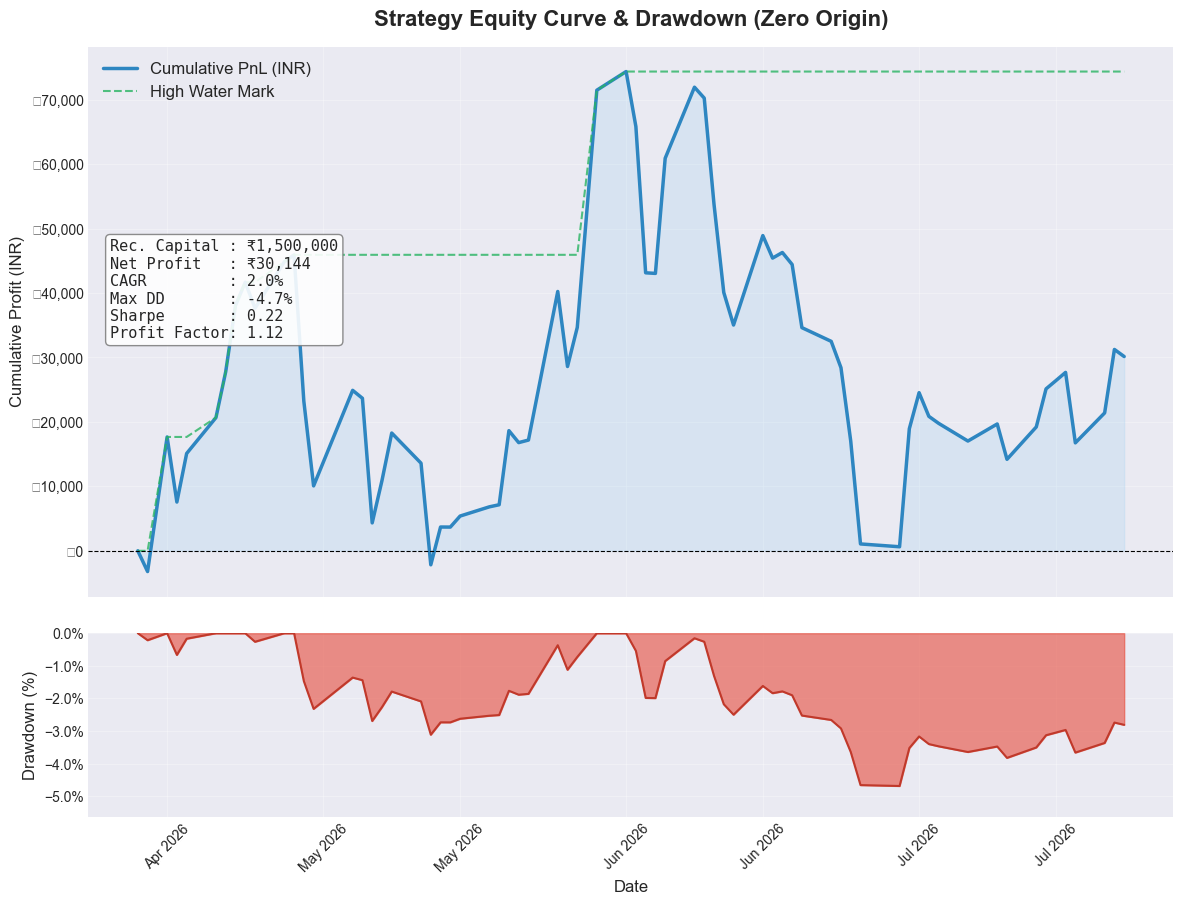

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import matplotlib.ticker as ticker
import os

# ==============================================================================
# CONFIGURATION
# ==============================================================================
DAILY_LOG_FILE = "v6_combined_daily_leveraged.csv"

LOT_SIZE = 65
RISK_FREE_RATE = 0.05
# Fixed assumed capital based on prior exact margin runs (12L peak margin + 25% buffer)
INITIAL_CAPITAL = 1500000  

# ==============================================================================
# 1. LOAD & PREPARE DATA
# ==============================================================================
if not os.path.exists(DAILY_LOG_FILE):
    raise FileNotFoundError(f"Ensure {DAILY_LOG_FILE} is in the current directory.")

df_daily = pd.read_csv(DAILY_LOG_FILE)
df_daily['Date'] = pd.to_datetime(df_daily['Date'])
df_daily = df_daily.sort_values('Date').reset_index(drop=True)

df_daily['Daily_PnL_INR'] = df_daily['Lev_PnL'] * LOT_SIZE

# Prep data for 0-origin equity curve
start_date = df_daily['Date'].iloc[0] - pd.Timedelta(days=1)
plot_df = pd.concat([
    pd.DataFrame({'Date': [start_date], 'Daily_PnL_INR': [0]}),
    df_daily[['Date', 'Daily_PnL_INR']]
]).reset_index(drop=True)

# ==============================================================================
# 2. CALCULATE PORTFOLIO METRICS
# ==============================================================================
# Equity Curve & Drawdown
plot_df['Cumulative_PnL_INR'] = plot_df['Daily_PnL_INR'].cumsum()
plot_df['High_Water_Mark'] = plot_df['Cumulative_PnL_INR'].cummax()
plot_df['Drawdown_INR'] = plot_df['Cumulative_PnL_INR'] - plot_df['High_Water_Mark']
plot_df['Drawdown_Pct'] = (plot_df['Drawdown_INR'] / (INITIAL_CAPITAL + plot_df['High_Water_Mark'])) * 100

# Basic PnL Stats (ignoring the artificial day-0)
actual_trading_days = plot_df.iloc[1:]
winning_days = actual_trading_days[actual_trading_days['Daily_PnL_INR'] > 0]['Daily_PnL_INR']
losing_days = actual_trading_days[actual_trading_days['Daily_PnL_INR'] < 0]['Daily_PnL_INR']

total_net_profit = plot_df['Cumulative_PnL_INR'].iloc[-1]
gross_profit = winning_days.sum()
gross_loss = losing_days.sum()
profit_factor = abs(gross_profit / gross_loss) if gross_loss != 0 else np.inf

win_rate = (len(winning_days) / len(actual_trading_days)) * 100
avg_win = winning_days.mean() if not winning_days.empty else 0
avg_loss = losing_days.mean() if not losing_days.empty else 0
payoff_ratio = abs(avg_win / avg_loss) if avg_loss != 0 else np.inf
expectancy = actual_trading_days['Daily_PnL_INR'].mean()

# Streaks
is_win = actual_trading_days['Daily_PnL_INR'] > 0
is_loss = actual_trading_days['Daily_PnL_INR'] < 0
max_win_streak = is_win.groupby((~is_win).cumsum()).sum().max()
max_loss_streak = is_loss.groupby((~is_loss).cumsum()).sum().max()

# Returns & Volatility Ratios
days_in_market = (plot_df['Date'].max() - plot_df['Date'].min()).days
years_in_market = max(days_in_market / 365.25, 1.0) # Avoid div-by-zero for < 1 year

total_return_pct = (total_net_profit / INITIAL_CAPITAL) * 100
cagr = ((1 + (total_net_profit / INITIAL_CAPITAL)) ** (1 / years_in_market) - 1) * 100

max_drawdown_inr = plot_df['Drawdown_INR'].min()
max_drawdown_pct = plot_df['Drawdown_Pct'].min()

# Sharpe, Sortino, Calmar (Annualized)
plot_df['Return_Pct'] = plot_df['Daily_PnL_INR'] / INITIAL_CAPITAL
daily_rf = RISK_FREE_RATE / 252
excess_returns = plot_df['Return_Pct'].iloc[1:] - daily_rf

sharpe_ratio = np.sqrt(252) * excess_returns.mean() / (excess_returns.std() + 1e-9)
downside_returns = excess_returns[excess_returns < 0]
downside_std = downside_returns.std() if not downside_returns.empty else 1e-9
sortino_ratio = np.sqrt(252) * excess_returns.mean() / downside_std
calmar_ratio = cagr / abs(max_drawdown_pct) if max_drawdown_pct != 0 else np.inf

# ==============================================================================
# 3. PRINT SUMMARY TEXT
# ==============================================================================
print("\n" + "="*65)
print("📊 ADVANCED STRATEGY METRICS (Based on ₹15L Capital)")
print("="*65)
print(f"Total Net Profit          : ₹ {total_net_profit:,.2f}")
print(f"Total Return              : {total_return_pct:.2f}%")
print(f"Annualized Return (CAGR)  : {cagr:.2f}%")
print("-" * 65)
print(f"Total Trading Days        : {len(actual_trading_days)}")
print(f"Win Rate                  : {win_rate:.1f}%")
print(f"Profit Factor             : {profit_factor:.2f}")
print(f"Payoff Ratio (AvgW/AvgL)  : {payoff_ratio:.2f}")
print(f"Expectancy per Day        : ₹ {expectancy:,.2f}")
print("-" * 65)
print(f"Average Win               : ₹ {avg_win:,.2f}")
print(f"Average Loss              : ₹ {avg_loss:,.2f}")
print(f"Max Consecutive Wins      : {max_win_streak:.0f}")
print(f"Max Consecutive Losses    : {max_loss_streak:.0f}")
print("-" * 65)
print(f"Max Drawdown (INR)        : ₹ {max_drawdown_inr:,.2f}")
print(f"Max Drawdown (%)          : {max_drawdown_pct:.2f}%")
print("-" * 65)
print(f"Sharpe Ratio              : {sharpe_ratio:.2f}")
print(f"Sortino Ratio             : {sortino_ratio:.2f}")
print(f"Calmar Ratio              : {calmar_ratio:.2f}")
print("="*65)

# ==============================================================================
# 4. PLOT EQUITY CURVE & DRAWDOWN
# ==============================================================================
plt.style.use('seaborn-v0_8-darkgrid')
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 10), gridspec_kw={'height_ratios': [3, 1]}, sharex=True)
fig.subplots_adjust(hspace=0.1)

formatter = ticker.FuncFormatter(lambda x, p: f'₹{x:,.0f}')

# --- TOP PANEL: EQUITY CURVE ---
ax1.plot(plot_df['Date'], plot_df['Cumulative_PnL_INR'], color='#2E86C1', linewidth=2.5, label='Cumulative PnL (INR)')
ax1.plot(plot_df['Date'], plot_df['High_Water_Mark'], color='#28B463', linewidth=1.5, linestyle='--', alpha=0.8, label='High Water Mark')
ax1.fill_between(plot_df['Date'], plot_df['Cumulative_PnL_INR'], 0, color='#AED6F1', alpha=0.3)
ax1.axhline(0, color='black', linewidth=0.8, linestyle='--')

ax1.set_title("Strategy Equity Curve & Drawdown (Zero Origin)", fontsize=16, fontweight='bold', pad=15)
ax1.set_ylabel("Cumulative Profit (INR)", fontsize=12)
ax1.yaxis.set_major_formatter(formatter)
ax1.legend(loc='upper left', fontsize=12)
ax1.grid(True, alpha=0.3)

# Inside Text Box (Top Left under Legend)
stats_text = (
    f"Rec. Capital : ₹{INITIAL_CAPITAL:,.0f}\n"
    f"Net Profit   : ₹{total_net_profit:,.0f}\n"
    f"CAGR         : {cagr:.1f}%\n"
    f"Max DD       : {max_drawdown_pct:.1f}%\n"
    f"Sharpe       : {sharpe_ratio:.2f}\n"
    f"Profit Factor: {profit_factor:.2f}"
)
props = dict(boxstyle='round', facecolor='white', alpha=0.9, edgecolor='gray')
ax1.text(0.02, 0.65, stats_text, transform=ax1.transAxes, fontsize=11, 
         verticalalignment='top', bbox=props, fontfamily='monospace')

# --- BOTTOM PANEL: DRAWDOWN ---
ax2.fill_between(plot_df['Date'], plot_df['Drawdown_Pct'], 0, color='#E74C3C', alpha=0.6)
ax2.plot(plot_df['Date'], plot_df['Drawdown_Pct'], color='#C0392B', linewidth=1.5)

ax2.set_ylabel("Drawdown (%)", fontsize=12)
ax2.set_xlabel("Date", fontsize=12)
ax2.yaxis.set_major_formatter(ticker.PercentFormatter())
ax2.grid(True, alpha=0.3)
ax2.set_ylim(min(max_drawdown_pct * 1.2, -1), 0)

# X-Axis Formatting
ax2.xaxis.set_major_locator(mdates.AutoDateLocator())
ax2.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
plt.xticks(rotation=45)

plt.show()

In [53]:
# ==============================================================================
# NEXT-DAY BASKET — v2: expiry, reference quotes, TRUE combined payoff,
# and 1-DAY-HOLD empirical POP/RRR (not hold-to-expiry)
# ==============================================================================
# Reuses every strategy function unchanged: build_core_legs, build_satellite_legs,
# audit_net_position, detect_ci_columns, round_to_nearest_strike, run_backtest_v6,
# summarize, CORE_CONFIG, SATELLITE_CONFIG, REGIME_*, TREND_*.
#
# WHAT'S DIFFERENT FROM v1:
#   A) COMBINED PAYOFF — evaluates the true net position (all legs together,
#      via net_pos from audit_net_position) instead of summing CORE and
#      SATELLITE payoffs as if independent. This is what your broker's tool
#      is actually showing you, and it's the only version that will surface
#      an uncapped side hiding behind two "individually defined-risk" legs.
#   B) 1-DAY-HOLD POP/RRR — instead of strike +/- credit expiry math, this
#      pulls the ACTUAL historical daily PnL distribution for this exact
#      Regime (CORE) / BW_Trend+kind (SATELLITE) / Regime+BW_Trend (COMBINED)
#      bucket out of the backtest (df_trades / df_combined) and reports
#      Win% (empirical POP), avg-win/avg-loss RRR, and PF — with sample size
#      shown explicitly, because n is genuinely thin in some buckets (see the
#      strategy file's own docstring: WIDENING n=15, THINNING n=30, etc.)
#   The hold-to-expiry numbers from v1 are kept too, clearly labeled, because
#   they're still the correct source for margin/worst-case sizing.
# ==============================================================================

def get_historical_trade_log():
    """Re-runs the existing, unmodified backtest to get df_trades/df_combined
    for empirical POP/RRR lookups. No strategy logic here — just calling the
    functions already defined above exactly as __main__ does."""
    pred_files = sorted(glob.glob(str(PREDICTIONS_DIR / "model_predictions_*.csv")))
    df_p = pd.concat([pd.read_csv(f) for f in pred_files], ignore_index=True)
    df_p = df_p.drop_duplicates(subset=["Prediction_Date"]).sort_values("Prediction_Date")
    df_p["Prediction_Date"] = pd.to_datetime(df_p["Prediction_Date"])
    df_p["Target_Date"]     = df_p["Prediction_Date"].shift(-1)
    df_p["Actual_Outcome"]  = df_p["Base_Price"].shift(-1)
    df_p = df_p.dropna(subset=["Actual_Outcome"])

    col_map = detect_ci_columns(df_p)
    df_p["_bw"]   = (df_p[col_map["upper_outer"]] - df_p[col_map["lower_outer"]]) / df_p["Base_Price"] * 100
    df_p["_q_lo"] = df_p["_bw"].rolling(REGIME_LOOKBACK, min_periods=REGIME_LOOKBACK).quantile(REGIME_LOW_Q)
    df_p["_q_hi"] = df_p["_bw"].rolling(REGIME_LOOKBACK, min_periods=REGIME_LOOKBACK).quantile(REGIME_HIGH_Q)
    prior_avg = df_p["_bw"].shift(1).rolling(TREND_LOOKBACK, min_periods=TREND_LOOKBACK).mean()
    df_p["_bw_trend"] = np.select(
        [df_p["_bw"] > prior_avg * (1 + TREND_THRESHOLD),
         df_p["_bw"] < prior_avg * (1 - TREND_THRESHOLD)],
        ["WIDENING", "THINNING"], default="STABLE",
    )
    df_p.loc[prior_avg.isna(), "_bw_trend"] = np.nan

    spread_files = glob.glob(str(SPREADS_DIR / "nifty_spreads_*.csv"))
    lfs = pl.scan_csv(spread_files)
    df_trades, df_combined = run_backtest_v6(df_p, lfs, col_map)
    return df_trades, df_combined


def empirical_stats(pnl_series):
    n = len(pnl_series)
    if n == 0:
        return {"n": 0, "pop_pct": None, "avg_win": None, "avg_loss": None, "rrr": None, "pf": None, "max_loss": None}
    wins = pnl_series[pnl_series > 0]
    losses = pnl_series[pnl_series <= 0]
    pop = round(len(wins) / n * 100, 1)
    avg_win = round(wins.mean(), 2) if len(wins) else 0.0
    avg_loss = round(abs(losses.mean()), 2) if len(losses) else 0.0
    rrr = round(avg_win / avg_loss, 2) if avg_loss > 0 else float("inf")
    gw, gl = wins.sum(), abs(losses.sum())
    pf = round(gw / gl, 2) if gl > 0 else float("inf")
    return {"n": n, "pop_pct": pop, "avg_win_pts": avg_win, "avg_loss_pts": avg_loss,
            "rrr": rrr, "pf": pf, "max_loss_pts": round(pnl_series.min(), 2)}


def combined_payoff_analysis(net_pos, total_credit, base_price):
    """True combined-position payoff at expiry — the honest version of what
    your broker's tool computes. Used ONLY to detect uncapped exposure and
    report hard bounds; NOT used for the 1-day RRR (see empirical section)."""
    strikes = sorted({strike for (_, strike) in net_pos.keys()})

    def payoff_at(S):
        val = total_credit
        for (o_type, strike), qty in net_pos.items():
            if o_type == "CE":
                val -= qty * max(S - strike, 0)
            else:
                val -= qty * max(strike - S, 0)
        return val

    kink_payoffs = {S: payoff_at(S) for S in strikes}
    payoff_at_zero = payoff_at(0)

    slope_upside = -sum(qty for (o_type, strike), qty in net_pos.items() if o_type == "CE")
    slope_downside_at_zero = sum(qty for (o_type, strike), qty in net_pos.items() if o_type == "PE")

    upside_uncapped = slope_upside < 0     # net short calls beyond outermost long call
    downside_uncapped = slope_downside_at_zero > 0  # net short puts beyond innermost long put (bounded at 0 anyway)

    bounded_max = max(kink_payoffs.values())
    bounded_min = min(list(kink_payoffs.values()) + [payoff_at_zero])

    return {
        "kink_payoffs": kink_payoffs,
        "payoff_at_zero": round(payoff_at_zero, 2),
        "upside_uncapped": upside_uncapped,
        "downside_uncapped_beyond_zero": downside_uncapped,
        "bounded_region_max_profit_pts": round(bounded_max, 2),
        "bounded_region_worst_finite_pts": round(bounded_min, 2),
    }


def build_next_day_basket():
    pred_files = sorted(glob.glob(str(PREDICTIONS_DIR / "model_predictions_*.csv")))
    if not pred_files:
        raise FileNotFoundError(f"No prediction files found in {PREDICTIONS_DIR}")

    df_p = pd.concat([pd.read_csv(f) for f in pred_files], ignore_index=True)
    df_p = df_p.drop_duplicates(subset=["Prediction_Date"]).sort_values("Prediction_Date").reset_index(drop=True)
    df_p["Prediction_Date"] = pd.to_datetime(df_p["Prediction_Date"])

    col_map = detect_ci_columns(df_p)
    df_p["_bw"]   = (df_p[col_map["upper_outer"]] - df_p[col_map["lower_outer"]]) / df_p["Base_Price"] * 100
    df_p["_q_lo"] = df_p["_bw"].rolling(REGIME_LOOKBACK, min_periods=REGIME_LOOKBACK).quantile(REGIME_LOW_Q)
    df_p["_q_hi"] = df_p["_bw"].rolling(REGIME_LOOKBACK, min_periods=REGIME_LOOKBACK).quantile(REGIME_HIGH_Q)
    prior_avg = df_p["_bw"].shift(1).rolling(TREND_LOOKBACK, min_periods=TREND_LOOKBACK).mean()
    df_p["_bw_trend"] = np.select(
        [df_p["_bw"] > prior_avg * (1 + TREND_THRESHOLD),
         df_p["_bw"] < prior_avg * (1 - TREND_THRESHOLD)],
        ["WIDENING", "THINNING"], default="STABLE",
    )
    df_p.loc[prior_avg.isna(), "_bw_trend"] = np.nan

    latest = df_p.iloc[-1]
    pred_date = latest["Prediction_Date"].date()
    bw, q_lo, q_hi = latest["_bw"], latest["_q_lo"], latest["_q_hi"]
    if pd.isna(q_lo) or pd.isna(q_hi):
        print(f"[{pred_date}] Still in warmup — no basket can be generated.")
        return None

    regime   = "LOW_VOL" if bw < q_lo else ("HIGH_VOL" if bw > q_hi else "NORMAL")
    bullish  = latest["Mean_Predicted_Price"] > latest["Base_Price"]
    bw_trend = latest["_bw_trend"] if pd.notna(latest["_bw_trend"]) else "STABLE"

    sp_outer = round_to_nearest_strike(latest[col_map["lower_outer"]])
    sc_outer = round_to_nearest_strike(latest[col_map["upper_outer"]])
    sp_inner = round_to_nearest_strike(latest[col_map["lower_inner"]])
    sc_inner = round_to_nearest_strike(latest[col_map["upper_inner"]])

    core_cfg, core_sl = build_core_legs(regime, sp_outer, sc_outer, sp_inner, sc_inner)
    sat_cfg, sat_sl    = build_satellite_legs(bw_trend, bullish, sp_outer, sc_outer, sp_inner, sc_inner)
    sat_kind = SATELLITE_CONFIG[bw_trend]["kind"] if sat_cfg is not None else None
    net_pos, has_overlap = audit_net_position(core_cfg, sat_cfg)

    spread_files = glob.glob(str(SPREADS_DIR / "nifty_spreads_*.csv"))
    lf_spreads = pl.scan_csv(spread_files)
    all_legs_cfg = list(core_cfg) + (list(sat_cfg) if sat_cfg else [])
    expiry, quotes_as_of_date, quotes = resolve_expiry_and_quotes(
        lf_spreads, all_legs_cfg, after_date_str=str(pred_date)
    )

    core_metrics = compute_group_metrics(core_cfg, core_sl, quotes)
    sat_metrics  = compute_group_metrics(sat_cfg, sat_sl, quotes) if sat_cfg is not None else None
    total_credit = core_metrics.get("entry_net_credit_pts", 0) + (sat_metrics.get("entry_net_credit_pts", 0) if sat_metrics else 0)
    combined = combined_payoff_analysis(net_pos, total_credit, latest["Base_Price"])

    # ---- empirical, 1-day-hold POP/RRR from the actual backtest history ----
    df_trades_hist, df_combined_hist = get_historical_trade_log()
    core_hist = df_trades_hist[(df_trades_hist["Leg"] == "CORE") & (df_trades_hist["Regime"] == regime)]["PnL"]
    core_emp = empirical_stats(core_hist)

    sat_emp = None
    if sat_cfg is not None:
        sat_hist = df_trades_hist[(df_trades_hist["Leg"] == f"SATELLITE_{sat_kind}") &
                                   (df_trades_hist["BW_Trend"] == bw_trend)]["PnL"]
        sat_emp = empirical_stats(sat_hist)

    combined_hist = df_combined_hist[(df_combined_hist["Regime"] == regime) &
                                      (df_combined_hist["BW_Trend"] == bw_trend)]["PnL"]
    combined_emp = empirical_stats(combined_hist)

    # ---------------------------------------------------------------- report
    W = 108
    print(f"\n{'='*W}\n{'📦  NEXT-DAY BASKET':^{W}}\n{'='*W}")
    print(f"Prediction row dated: {pred_date}  →  basket for the next trading session's open")
    print(f"Expiry selected: {expiry}   (reference quotes as of: {quotes_as_of_date})")
    print(f"Regime: {regime}   BW_Trend: {bw_trend}   Direction: {'BULLISH' if bullish else 'BEARISH'}\n")

    def print_group(name, metrics):
        print(f"--- {name} ---")
        rows = [[l["type"], l["strike"], expiry, l["side"].upper(), LOT_SIZE, l["ref_bid"], l["ref_ask"]]
                for l in metrics["legs"]]
        print(tabulate(rows, headers=["Type", "Strike", "Expiry", "Side", "Qty(lot)", "Ref_Bid", "Ref_Ask"], tablefmt="simple"))
        print(f"  [Hold-to-expiry, reference only] Max profit: {metrics['max_profit_pts']} pts | "
              f"Profit range: {metrics['profit_range']} | Max loss: {metrics['max_loss_pts']} pts "
              f"({metrics['loss_basis']}) | RRR: {metrics['max_rrr']}")
        if metrics["sl_mult"] is not None:
            print(f"  SL (combined leg cost): exit when cost-to-close > {metrics['sl_close_cost_trigger_pts']} pts")

    print_group("CORE", core_metrics)
    def print_emp(name, e):
        if e["n"] == 0:
            print(f"  [1-DAY EMPIRICAL] {name}: no historical trades in this bucket yet.")
            return
        flag = "  ⚠️ thin sample" if e["n"] < 15 else ""
        print(f"  [1-DAY EMPIRICAL, n={e['n']}{flag}] POP: {e['pop_pct']}% | Avg win: {e['avg_win_pts']} pts | "
              f"Avg loss: {e['avg_loss_pts']} pts | RRR: {e['rrr']} | PF: {e['pf']} | Worst day: {e['max_loss_pts']} pts")
    print_emp("CORE", core_emp)
    print()

    if sat_cfg is not None:
        print_group(f"SATELLITE_{sat_kind}", sat_metrics)
        print_emp(f"SATELLITE_{sat_kind}", sat_emp)
        print()
    else:
        print(f"(No satellite leg — BW_Trend={bw_trend} has no SATELLITE_CONFIG entry.)\n")

    print(f"{'-'*W}\n📐 TRUE COMBINED POSITION (all legs netted — what a strategy-builder tool actually sees)")
    net_rows = [[f"{t} {s}", q] for (t, s), q in sorted(net_pos.items())]
    print(tabulate(net_rows, headers=["Option", "Net Short Qty"], tablefmt="simple"))
    print(f"\n  Payoff at spot=0 (worst finite downside): {combined['payoff_at_zero']} pts")
    print(f"  Bounded-region max profit (at a kink):     {combined['bounded_region_max_profit_pts']} pts")
    print(f"  Upside beyond highest strike:   {'⚠️ UNCAPPED LOSS' if combined['upside_uncapped'] else 'capped'}")
    print(f"  Downside beyond lowest strike:  {'⚠️ large loss down to spot=0' if combined['downside_uncapped_beyond_zero'] else 'capped'}")
    if has_overlap:
        print("  ⚠️ Exact-strike overlap also present (see audit_net_position).")
    if combined["upside_uncapped"] or combined["downside_uncapped_beyond_zero"]:
        print("  ⚠️ This is very likely why your broker's tool shows an unbounded figure — CORE and "
              "SATELLITE look individually defined-risk, but netted together one side is not. "
              "Enter the full 6-leg basket (not CORE/SATELLITE separately) into the broker tool to confirm.")

    print(f"\n{'-'*W}\n📊 [1-DAY EMPIRICAL] COMBINED (CORE+SATELLITE together, actual daily-hold history for this "
          f"Regime+BW_Trend bucket)")
    print_emp("COMBINED", combined_emp)
    print(
        "\nℹ️  The '[Hold-to-expiry]' figures above are correct as worst-case/margin bounds only. "
        "Since this strategy exits same-day (SL check or 15:30 close), the '[1-DAY EMPIRICAL]' lines "
        "are the actual relevant POP/RRR — pulled from this exact Regime/BW_Trend bucket's real "
        "historical daily PnL, not from an expiry-settlement formula."
    )

    return {
        "prediction_date": str(pred_date), "expiry": str(expiry), "regime": regime, "bw_trend": bw_trend,
        "core": {"legs_cfg": core_cfg, "metrics": core_metrics, "empirical": core_emp},
        "satellite": ({"kind": sat_kind, "legs_cfg": sat_cfg, "metrics": sat_metrics, "empirical": sat_emp}
                      if sat_cfg is not None else None),
        "combined_true_payoff": combined, "combined_empirical": combined_emp,
        "net_position": {f"{t}_{s}": q for (t, s), q in net_pos.items()}, "overlap": bool(has_overlap),
    }


next_day_basket = build_next_day_basket()

[CI] Outer 85% -> Lower_85_CI_Price / Upper_85_CI_Price
[CI] Inner 20% -> Lower_20_CI_Price / Upper_20_CI_Price
[CI] Outer 85% -> Lower_85_CI_Price / Upper_85_CI_Price
[CI] Inner 20% -> Lower_20_CI_Price / Upper_20_CI_Price

                               🚀  STRATEGY: OPTIMAL_HYBRID_V6  (parallel CORE + SATELLITE)                                
[2026-04-13] 🟢 | Combined PnL:   225.85 | NORMAL    STABLE    | CORE: 225.85            
[2026-04-15] 🟢 | Combined PnL:   107.10 | LOW_VOL   THINNING  | CORE:  58.75 SAT:48.35   [OVERLAP]
[2026-04-16] 🔴 | Combined PnL:   -24.05 | LOW_VOL   THINNING  | CORE:  12.55 SAT:-36.60  [OVERLAP]
[2026-04-17] 🟢 | Combined PnL:    38.65 | LOW_VOL   THINNING  | CORE: -19.95 SAT:58.60   [OVERLAP]
[2026-04-20] 🟢 | Combined PnL:    28.55 | LOW_VOL   THINNING  | CORE:  15.40 SAT:13.15   [OVERLAP]
[2026-04-21] 🟢 | Combined PnL:    51.25 | LOW_VOL   THINNING  | CORE:   3.65 SAT:47.60   [OVERLAP]
[2026-04-22] 🟢 | Combined PnL:    52.65 | LOW_VOL   THINNING  | CORE

In [54]:
# ==============================================================================
# REGIME_STRATEGY_LAB_V2 — more strategies, more signals, multi-signal slicing
# ==============================================================================
# WHAT'S NEW VS THE FIRST LAB
# ------------------------------------------------------------------------------
# 1) MORE STRATEGIES (10 total, up from 5). New ones specifically probe
#    whether direction and bandwidth-trend signals are worth using, and
#    whether the V5 skew logic (tight strike on the "safe" side) is actually
#    the right way round:
#
#      NAKED_STRANGLE_INNER     - non-directional, both legs inner CI
#      NAKED_STRANGLE_OUTER     - non-directional, both legs outer CI
#      ASYMMETRIC_STRANGLE      - directional skew: favored side inner
#                                  (tight, more premium), other side outer
#                                  (wide, room to be wrong) — the original design
#      ASYMMETRIC_STRANGLE_REV  - directional skew REVERSED: favored side
#                                  outer, other side inner. Tests whether the
#                                  original skew direction is actually correct
#                                  or just an untested assumption
#      DIRECTIONAL_SINGLE_LEG   - sells only the non-favored-side leg (inner),
#                                  no leg at all on the favored side. Cuts one
#                                  leg's spread cost/risk entirely if the
#                                  favored-side leg wasn't earning its keep
#      CREDIT_SPREAD_ALIGNED    - defined-risk spread betting WITH the
#                                  predicted direction (this is V3/V4's
#                                  original CREDIT_SPREAD_1SIDE, renamed
#                                  for clarity now that OPPOSITE also exists)
#      CREDIT_SPREAD_OPPOSITE   - defined-risk spread betting AGAINST
#                                  overshoot in the predicted direction
#                                  (fades the magnitude, not the direction)
#      IRON_CONDOR               - non-directional, short legs on OUTER CI,
#                                  wide wings (same as first lab)
#      IRON_CONDOR_TIGHT         - non-directional, short legs on INNER CI,
#                                  wide wings — more premium collected up
#                                  front, defined risk still caps the tail
#      TREND_ADAPTIVE_STRANGLE   - non-directional; band choice driven by the
#                                  bandwidth-TREND signal, not the regime
#                                  LEVEL: WIDENING -> outer (give room, vol
#                                  is expanding), THINNING -> inner (collect
#                                  more, vol is contracting), STABLE ->
#                                  falls back to the V5 regime-level default
#
# 2) TWO NEW SIGNALS, IN ADDITION TO THE EXISTING VOL-REGIME LEVEL SIGNAL
#      direction  : BULLISH / BEARISH, from Mean_Preddicted_Price vs Base_Price
#                   (already used by V3-V5, now also tested as a standalone
#                   slicing axis, not just baked into one strategy)
#      bw_trend   : WIDENING / THINNING / STABLE — compares today's CI
#                   bandwidth to the prior 5-day rolling average bandwidth
#                   (shifted, no lookahead). This is a distinct signal from
#                   the regime LEVEL bucket: a day can be LOW_VOL in level
#                   terms while its bandwidth is actively WIDENING off a
#                   recent low, which the level-only regime bucket can't see.
#
# 3) MULTI-SIGNAL BREAKDOWNS
#    Every (strategy, SL) combo is evaluated once per trade with all three
#    signal tags attached (regime, direction, bw_trend), stored as a long
#    dataframe, then sliced multiple ways:
#      - by regime alone            (same as first lab, for continuity)
#      - by direction alone         (does bullish/bearish matter on its own?)
#      - by bw_trend alone          (does the trend signal matter on its own?)
#      - by regime x direction      (6 cells)
#      - by regime x bw_trend       (9 cells)
#    Full 3-way (regime x direction x bw_trend, 18 cells) is reported as trade
#    COUNTS ONLY, not strategy comparisons — on ~59 trades that's ~3 trades/
#    cell, too thin to rank strategies on without just picking noise.
#
# 4) tqdm progress bars over the strategy x SL sweep (this is the expensive
#    part — 10 strategies x 4 SL variants x ~59 days = ~2,360 evaluations).
# ==============================================================================

import pandas as pd
import polars as pl
import glob
import numpy as np
from pathlib import Path
import re
from tabulate import tabulate
from tqdm import tqdm

STRIKE_GAP  = 50
LOT_SIZE    = 65
REGIME_LOOKBACK   = 20
REGIME_LOW_Q      = 0.20
REGIME_HIGH_Q     = 0.80
TREND_LOOKBACK    = 5      # days of prior bandwidth averaged for the trend signal
TREND_THRESHOLD   = 0.05   # +/-5% vs prior average = WIDENING / THINNING
IRON_CONDOR_WING_MULT = 3
SL_VARIANTS = [None, 1.3, 1.5, 1.8]
MIN_TRUSTED_SAMPLE = 10

# Fallback band for TREND_ADAPTIVE_STRANGLE on STABLE days — reuses the
# level-regime logic validated in the first lab / V5.
REGIME_BAND_FALLBACK = {"LOW_VOL": "outer", "NORMAL": "inner", "HIGH_VOL": "outer"}

PREDICTIONS_DIR = Path("./results")
SPREADS_DIR     = Path("./data/NIFTY_spreads")

# ==========================================
# SHARED HELPERS
# ==========================================

def round_to_nearest_strike(price, base=50):
    return base * round(price / base)


def detect_ci_columns(df):
    pattern = re.compile(r'^(Lower|Upper)_(\d+)_CI_Price$')
    found = {}
    for col in df.columns:
        m = pattern.match(col)
        if m:
            side, pct = m.group(1), int(m.group(2))
            found.setdefault(pct, {})[side] = col
    complete = {pct: d for pct, d in found.items() if "Lower" in d and "Upper" in d}
    if len(complete) < 2:
        raise ValueError(f"Expected >=2 complete CI levels. Found: {list(complete.keys())}")
    sorted_pcts = sorted(complete.keys())
    inner_pct, outer_pct = sorted_pcts[0], sorted_pcts[-1]
    return {
        "lower_outer": complete[outer_pct]["Lower"], "upper_outer": complete[outer_pct]["Upper"],
        "lower_inner": complete[inner_pct]["Lower"], "upper_inner": complete[inner_pct]["Upper"],
    }


def extract_leg_data(df_day, target_date_str, option_type, strike):
    leg_df = df_day.filter(
        (pl.col("type").is_in([option_type, option_type[0]])) & (pl.col("strike") == strike)
    )
    if leg_df.height == 0:
        return None
    e_row = leg_df.filter(pl.col("datetime") == f"{target_date_str} 09:15:00")
    v_row = leg_df.filter(pl.col("datetime") == f"{target_date_str} 09:20:00")
    if e_row.height == 0 or v_row.height == 0:
        return None
    if v_row.select("cumulative_volume").item() <= e_row.select("cumulative_volume").item():
        return None
    all_day = leg_df.sort("datetime")
    x_row = leg_df.filter(pl.col("datetime") == f"{target_date_str} 15:30:00")
    if x_row.height == 0:
        x_row = all_day.tail(1)
    sl_day = leg_df.filter(pl.col("datetime") >= f"{target_date_str} 09:20:00").sort("datetime")
    return {
        "entry_bid": e_row.select("bid").item(), "entry_ask": e_row.select("ask").item(),
        "exit_bid": x_row.select("bid").item(), "exit_ask": x_row.select("ask").item(),
        "sl_day_asks": sl_day.select("ask").to_series().to_list(),
        "sl_day_bids": sl_day.select("bid").to_series().to_list(),
    }


def apply_sl_check(day_legs, sl_mult):
    if sl_mult is None:
        return False, None
    entry_net = (sum(l["entry_bid"] for l in day_legs if l["side"] == "sell")
                 - sum(l["entry_ask"] for l in day_legs if l["side"] == "buy"))
    if entry_net <= 0:
        return False, None
    min_len = min(len(l["sl_day_asks"]) for l in day_legs)
    for t in range(min_len):
        close_cost = 0.0
        for leg in day_legs:
            close_cost += leg["sl_day_asks"][t] if leg["side"] == "sell" else -leg["sl_day_bids"][t]
        if close_cost > entry_net * sl_mult:
            return True, entry_net - close_cost
    return False, None


def settle_pnl(day_legs):
    pnl = 0.0
    for leg in day_legs:
        pnl += (leg["entry_bid"] - leg["exit_ask"]) if leg["side"] == "sell" else (leg["exit_bid"] - leg["entry_ask"])
    return pnl


# ==========================================
# STRATEGY DEFINITIONS
# Every strategy function has the SAME signature so the runner can call any
# of them uniformly: (bullish, bw_trend, regime, sp_outer, sc_outer,
# sp_inner, sc_inner) -> list[(option_type, strike, side)]
# Strategies that don't use direction/trend simply ignore those args.
# ==========================================

def strat_naked_inner(bullish, bw_trend, regime, sp_outer, sc_outer, sp_inner, sc_inner):
    return [("PE", sp_inner, "sell"), ("CE", sc_inner, "sell")]

def strat_naked_outer(bullish, bw_trend, regime, sp_outer, sc_outer, sp_inner, sc_inner):
    return [("PE", sp_outer, "sell"), ("CE", sc_outer, "sell")]

def strat_asymmetric(bullish, bw_trend, regime, sp_outer, sc_outer, sp_inner, sc_inner):
    # favored side tight (inner), other side wide (outer)
    if bullish:
        return [("PE", sp_inner, "sell"), ("CE", sc_outer, "sell")]
    return [("PE", sp_outer, "sell"), ("CE", sc_inner, "sell")]

def strat_asymmetric_rev(bullish, bw_trend, regime, sp_outer, sc_outer, sp_inner, sc_inner):
    # favored side wide (outer), other side tight (inner) — reversed skew
    if bullish:
        return [("PE", sp_outer, "sell"), ("CE", sc_inner, "sell")]
    return [("PE", sp_inner, "sell"), ("CE", sc_outer, "sell")]

def strat_directional_single_leg(bullish, bw_trend, regime, sp_outer, sc_outer, sp_inner, sc_inner):
    # only the non-favored-side leg, inner strike, nothing on the favored side
    if bullish:
        return [("PE", sp_inner, "sell")]
    return [("CE", sc_inner, "sell")]

def strat_credit_spread_aligned(bullish, bw_trend, regime, sp_outer, sc_outer, sp_inner, sc_inner):
    # bet WITH the predicted direction
    if bullish:
        return [("PE", sp_inner, "sell"), ("PE", sp_inner - STRIKE_GAP, "buy")]
    return [("CE", sc_inner, "sell"), ("CE", sc_inner + STRIKE_GAP, "buy")]

def strat_credit_spread_opposite(bullish, bw_trend, regime, sp_outer, sc_outer, sp_inner, sc_inner):
    # bet AGAINST overshoot in the predicted direction
    if bullish:
        return [("CE", sc_inner, "sell"), ("CE", sc_inner + STRIKE_GAP, "buy")]
    return [("PE", sp_inner, "sell"), ("PE", sp_inner - STRIKE_GAP, "buy")]

def strat_iron_condor(bullish, bw_trend, regime, sp_outer, sc_outer, sp_inner, sc_inner):
    return [
        ("PE", sp_outer, "sell"), ("PE", sp_outer - IRON_CONDOR_WING_MULT * STRIKE_GAP, "buy"),
        ("CE", sc_outer, "sell"), ("CE", sc_outer + IRON_CONDOR_WING_MULT * STRIKE_GAP, "buy"),
    ]

def strat_iron_condor_tight(bullish, bw_trend, regime, sp_outer, sc_outer, sp_inner, sc_inner):
    return [
        ("PE", sp_inner, "sell"), ("PE", sp_inner - IRON_CONDOR_WING_MULT * STRIKE_GAP, "buy"),
        ("CE", sc_inner, "sell"), ("CE", sc_inner + IRON_CONDOR_WING_MULT * STRIKE_GAP, "buy"),
    ]

def strat_trend_adaptive(bullish, bw_trend, regime, sp_outer, sc_outer, sp_inner, sc_inner):
    if bw_trend == "WIDENING":
        band = "outer"
    elif bw_trend == "THINNING":
        band = "inner"
    else:
        band = REGIME_BAND_FALLBACK[regime]
    if band == "outer":
        return [("PE", sp_outer, "sell"), ("CE", sc_outer, "sell")]
    return [("PE", sp_inner, "sell"), ("CE", sc_inner, "sell")]

STRATEGIES = {
    "NAKED_STRANGLE_INNER":     strat_naked_inner,
    "NAKED_STRANGLE_OUTER":     strat_naked_outer,
    "ASYMMETRIC_STRANGLE":      strat_asymmetric,
    "ASYMMETRIC_STRANGLE_REV":  strat_asymmetric_rev,
    "DIRECTIONAL_SINGLE_LEG":   strat_directional_single_leg,
    "CREDIT_SPREAD_ALIGNED":    strat_credit_spread_aligned,
    "CREDIT_SPREAD_OPPOSITE":   strat_credit_spread_opposite,
    "IRON_CONDOR":              strat_iron_condor,
    "IRON_CONDOR_TIGHT":        strat_iron_condor_tight,
    "TREND_ADAPTIVE_STRANGLE":  strat_trend_adaptive,
}

# ==========================================
# LAB RUNNER
# ==========================================

def build_day_contexts(df_preds, lf_spreads, col_map):
    COL_LO, COL_HO = col_map["lower_outer"], col_map["upper_outer"]
    COL_LI, COL_HI = col_map["lower_inner"], col_map["upper_inner"]

    day_contexts = []
    skip_warmup = skip_no_day = skip_no_expiry = 0
    for _, row in tqdm(df_preds.iterrows(), total=len(df_preds), desc="Fetching day contexts"):
        t_date_str = str(row["Target_Date"].date())
        bw, q_lo, q_hi = row["_bw"], row["_q_lo"], row["_q_hi"]
        if pd.isna(q_lo) or pd.isna(q_hi):
            skip_warmup += 1
            continue
        regime = "LOW_VOL" if bw < q_lo else ("HIGH_VOL" if bw > q_hi else "NORMAL")
        bullish = row["Mean_Predicted_Price"] > row["Base_Price"]
        bw_trend = row["_bw_trend"] if pd.notna(row["_bw_trend"]) else "STABLE"

        df_day = lf_spreads.filter(pl.col("datetime").str.starts_with(t_date_str)).collect()
        if df_day.height == 0:
            skip_no_day += 1
            continue
        valid_exp = sorted([e for e in df_day.select("expiry").unique().to_series().to_list()
                             if str(e)[:10] >= t_date_str])
        if not valid_exp:
            skip_no_expiry += 1
            continue
        df_day = df_day.filter(pl.col("expiry") == valid_exp[0])

        day_contexts.append({
            "date": t_date_str, "regime": regime, "bullish": bullish, "bw_trend": bw_trend,
            "sp_outer": round_to_nearest_strike(row[COL_LO]), "sc_outer": round_to_nearest_strike(row[COL_HO]),
            "sp_inner": round_to_nearest_strike(row[COL_LI]), "sc_inner": round_to_nearest_strike(row[COL_HI]),
            "df_day": df_day,
        })

    print(f"[Lab] Usable day-contexts: {len(day_contexts)}  "
          f"(skip_warmup={skip_warmup}, skip_no_day={skip_no_day}, skip_no_expiry={skip_no_expiry})")
    return day_contexts


def run_lab(day_contexts):
    leg_cache = {}
    def get_leg(ctx, o_type, strike, side):
        key = (ctx["date"], o_type, strike)
        if key not in leg_cache:
            leg_cache[key] = extract_leg_data(ctx["df_day"], ctx["date"], o_type, strike)
        base = leg_cache[key]
        if base is None:
            return None
        d = dict(base)
        d["side"] = side
        return d

    trade_rows = []  # per-trade granular log for flexible slicing later
    combos = [(s, sl) for s in STRATEGIES for sl in SL_VARIANTS]

    for strat_name, sl_mult in tqdm(combos, desc="Strategy x SL sweep"):
        strat_fn = STRATEGIES[strat_name]
        for ctx in day_contexts:
            legs_cfg = strat_fn(ctx["bullish"], ctx["bw_trend"], ctx["regime"],
                                 ctx["sp_outer"], ctx["sc_outer"], ctx["sp_inner"], ctx["sc_inner"])
            day_legs = [get_leg(ctx, o, k, s) for o, k, s in legs_cfg]
            if any(l is None for l in day_legs):
                continue
            was_stopped, stop_pnl = apply_sl_check(day_legs, sl_mult)
            day_pnl = stop_pnl if was_stopped else settle_pnl(day_legs)
            trade_rows.append({
                "Strategy": strat_name,
                "SL": "none" if sl_mult is None else f"{sl_mult}x",
                "Regime": ctx["regime"],
                "Direction": "BULLISH" if ctx["bullish"] else "BEARISH",
                "BW_Trend": ctx["bw_trend"],
                "PnL": day_pnl,
            })

    return pd.DataFrame(trade_rows)


# ==========================================
# REPORTING
# ==========================================

def _agg_table(df, group_cols):
    g = df.groupby(["Strategy", "SL"] + group_cols)["PnL"]
    out = g.agg(
        Trades="count",
        WinPct=lambda s: round((s > 0).sum() / len(s) * 100, 1),
        PnL_pts=lambda s: round(s.sum(), 2),
    ).reset_index()

    def _pf(s):
        gw = s[s > 0].sum()
        gl = abs(s[s <= 0].sum())
        return gw / gl if gl > 0 else float("inf")

    pf = g.apply(_pf).reset_index(name="PF")
    out = out.merge(pf, on=["Strategy", "SL"] + group_cols)
    out["PnL_INR"] = (out["PnL_pts"] * LOT_SIZE).round(0)
    out["_pf_sort"] = out["PF"].replace(float("inf"), 1e9)
    return out


def print_single_axis_table(df, axis_col, title):
    W = 100
    for val in sorted(df[axis_col].dropna().unique()):
        sub = _agg_table(df[df[axis_col] == val], [])
        sub = sub.sort_values("_pf_sort", ascending=False).drop(columns="_pf_sort").head(8)
        print(f"\n{'='*W}\n{(f'📊 {title}: {val}'):^{W}}\n{'='*W}")
        if sub.empty:
            print("(no trades)")
            continue
        print(tabulate(sub, headers="keys", tablefmt="simple", showindex=False,
                        stralign="left", numalign="right"))


def print_cross_axis_best(df, axis_cols, title):
    W = 100
    print(f"\n{'='*W}\n{('🏆 ' + title):^{W}}\n{'='*W}")
    rows = []
    combos = df[axis_cols].drop_duplicates().values.tolist()
    for combo in combos:
        mask = np.logical_and.reduce([df[c] == v for c, v in zip(axis_cols, combo)])
        sub = _agg_table(df[mask], [])
        if sub.empty:
            continue
        top = sub.sort_values("_pf_sort", ascending=False).iloc[0]
        flag = "⚠ low-n" if top["Trades"] < MIN_TRUSTED_SAMPLE else ""
        rows.append(list(combo) + [top["Strategy"], top["SL"], top["Trades"], top["WinPct"],
                                     round(top["PF"], 2) if top["PF"] != float("inf") else "inf",
                                     top["PnL_INR"], flag])
    headers = axis_cols + ["Strategy", "SL", "Trades", "Win%", "PF", "PnL(INR)", "Note"]
    rows.sort(key=lambda r: str(r[:len(axis_cols)]))
    print(tabulate(rows, headers=headers, tablefmt="simple", stralign="left", numalign="right"))


def print_three_way_counts(df):
    W = 100
    print(f"\n{'='*W}\n{'📋 DATA AVAILABILITY: Regime x Direction x BW_Trend (trade counts only)':^{W}}\n{'='*W}")
    counts = df.drop_duplicates(subset=["Regime", "Direction", "BW_Trend", "Strategy", "SL"])
    # trade counts are identical across strategy/SL for a given day, so take
    # one strategy/SL slice to avoid inflating the count
    base = df[(df["Strategy"] == list(STRATEGIES.keys())[0]) & (df["SL"] == "none")]
    tab = base.groupby(["Regime", "Direction", "BW_Trend"]).size().reset_index(name="Trades")
    tab = tab.sort_values(["Regime", "Direction", "BW_Trend"])
    print(tabulate(tab, headers="keys", tablefmt="simple", showindex=False, stralign="left", numalign="right"))
    print(
        "\n[Note] Cells below ~5 trades are essentially anecdote. Use this table to see where\n"
        "you actually have enough data before trusting any strategy ranking sliced this finely.\n"
    )


def print_all_reports(df_results):
    print_single_axis_table(df_results, "Regime", "REGIME")
    print_single_axis_table(df_results, "Direction", "DIRECTION")
    print_single_axis_table(df_results, "BW_Trend", "BW_TREND")
    print_cross_axis_best(df_results, ["Regime", "Direction"], "BEST STRATEGY x SL PER (REGIME, DIRECTION)")
    print_cross_axis_best(df_results, ["Regime", "BW_Trend"], "BEST STRATEGY x SL PER (REGIME, BW_TREND)")
    print_three_way_counts(df_results)


# ==========================================
# EXECUTION
# ==========================================
if __name__ == "__main__":
    pred_files = sorted(glob.glob(str(PREDICTIONS_DIR / "model_predictions_*.csv")))
    if not pred_files:
        raise FileNotFoundError(f"No prediction files found in {PREDICTIONS_DIR}")
    df_p = pd.concat([pd.read_csv(f) for f in pred_files], ignore_index=True)
    df_p = df_p.drop_duplicates(subset=["Prediction_Date"]).sort_values("Prediction_Date")
    df_p["Prediction_Date"] = pd.to_datetime(df_p["Prediction_Date"])
    df_p["Target_Date"]     = df_p["Prediction_Date"].shift(-1)
    df_p["Actual_Outcome"]  = df_p["Base_Price"].shift(-1)
    df_p = df_p.dropna(subset=["Actual_Outcome"])

    col_map = detect_ci_columns(df_p)
    df_p["_bw"]   = (df_p[col_map["upper_outer"]] - df_p[col_map["lower_outer"]]) / df_p["Base_Price"] * 100
    df_p["_q_lo"] = df_p["_bw"].rolling(REGIME_LOOKBACK, min_periods=REGIME_LOOKBACK).quantile(REGIME_LOW_Q)
    df_p["_q_hi"] = df_p["_bw"].rolling(REGIME_LOOKBACK, min_periods=REGIME_LOOKBACK).quantile(REGIME_HIGH_Q)

    # bw_trend: today's bandwidth vs prior TREND_LOOKBACK-day average, no lookahead
    prior_avg = df_p["_bw"].shift(1).rolling(TREND_LOOKBACK, min_periods=TREND_LOOKBACK).mean()
    df_p["_bw_trend"] = np.select(
        [df_p["_bw"] > prior_avg * (1 + TREND_THRESHOLD),
         df_p["_bw"] < prior_avg * (1 - TREND_THRESHOLD)],
        ["WIDENING", "THINNING"],
        default="STABLE",
    )
    df_p.loc[prior_avg.isna(), "_bw_trend"] = np.nan  # honest: not enough history yet

    spread_files = glob.glob(str(SPREADS_DIR / "nifty_spreads_*.csv"))
    if not spread_files:
        raise FileNotFoundError(f"No spread files found in {SPREADS_DIR}")
    lfs = pl.scan_csv(spread_files)

    day_contexts = build_day_contexts(df_p, lfs, col_map)
    df_results = run_lab(day_contexts)
    df_results.to_csv("regime_strategy_lab_v2_results.csv", index=False)

    print_all_reports(df_results)
    print("[Saved] Full per-trade result log -> regime_strategy_lab_v2_results.csv")

Fetching day contexts:   0%|          | 0/90 [00:00<?, ?it/s]

Fetching day contexts: 100%|██████████| 90/90 [00:19<00:00,  4.61it/s]


[Lab] Usable day-contexts: 67  (skip_warmup=19, skip_no_day=4, skip_no_expiry=0)


Strategy x SL sweep: 100%|██████████| 40/40 [00:00<00:00, 41.59it/s]



                                         📊 REGIME: HIGH_VOL                                         
Strategy                 SL      Trades    WinPct    PnL_pts       PF    PnL_INR
-----------------------  ----  --------  --------  ---------  -------  ---------
TREND_ADAPTIVE_STRANGLE  1.5x         7      71.4       99.8  9.18033       6487
NAKED_STRANGLE_OUTER     1.5x         7      71.4       99.8  9.18033       6487
TREND_ADAPTIVE_STRANGLE  1.8x         7      71.4      93.15  5.94164       6055
NAKED_STRANGLE_OUTER     1.8x         7      71.4      93.15  5.94164       6055
NAKED_STRANGLE_INNER     1.3x         7      57.1      223.4  4.65331      14521
ASYMMETRIC_STRANGLE_REV  1.5x         7      71.4     346.05  4.42285      22493
ASYMMETRIC_STRANGLE_REV  1.8x         7      71.4     334.45  3.96761      21739
NAKED_STRANGLE_INNER     1.5x         7      57.1     206.45  3.64341      13419

                                         📊 REGIME: LOW_VOL                             